In [1]:
import pandas as pd
import numpy as np

print("=== 🚀 [초기 세팅] 데이터 로드 및 퍼널 1~5단계 구축 ===")

# 1. 데이터 불러오기 (경로는 기존 환경에 맞게 수정해주세요)
data_path = '../../../../data/processed/'
users_df = pd.read_csv(data_path + 'accounts_user_preprocessed_2.csv')
friends_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed_2.csv')
votes_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed_2.csv')
points_df = pd.read_csv(data_path + 'accounts_pointhistory_preprocessed_2.csv')
payments_df = pd.read_csv(data_path + 'accounts_paymenthistory_preprocessed_2.csv')

# 2. 퍼널 유저 세팅 (교집합 로직)
step1_users = set(users_df['id'].dropna())

friend_users = set(friends_df['receive_user_id'].dropna()).union(set(friends_df['send_user_id'].dropna()))
step2_users = friend_users.intersection(step1_users)

# 기획 기준: 투표 '수신' 유저
step3_users = set(votes_df['chosen_user_id'].dropna()).intersection(step2_users)

# 기획 기준: 투표 수신 -> 힌트 열람(재화 소모)
step4_users = set(points_df['user_id'].dropna()).intersection(step3_users)

# 기획 기준: 힌트 열람 -> 결제
step5_users = set(payments_df['user_id'].dropna()).intersection(step4_users)

print("✅ 퍼널 세팅 완료!\n")


print("=== 🔍 [이탈 원인 분석] 결제 유저 vs 이탈 유저 투표 수신량 비교 ===")

# 1. 두 그룹 분리
# paid_users: Step 5까지 간 결제 유저 (358명)
paid_users = step5_users
# churned_users: Step 4까진 왔으나 결제 안 하고 이탈한 유저 (3,009명)
churned_users = step4_users - step5_users

# 2. 그룹별 투표 수신 횟수 계산
vote_counts = votes_df['chosen_user_id'].value_counts()

paid_votes = [vote_counts.get(uid, 0) for uid in paid_users]
churned_votes = [vote_counts.get(uid, 0) for uid in churned_users]

# 3. 평균 및 중앙값 비교
paid_avg = np.mean(paid_votes)
paid_med = np.median(paid_votes)

churned_avg = np.mean(churned_votes)
churned_med = np.median(churned_votes)

print(f"💰 결제 유저 그룹 ({len(paid_users):,}명) - 평균 투표 수신: {paid_avg:.1f}회 (중앙값: {paid_med:.0f}회)")
print(f"🏃 이탈 유저 그룹 ({len(churned_users):,}명) - 평균 투표 수신: {churned_avg:.1f}회 (중앙값: {churned_med:.0f}회)")

=== 🚀 [초기 세팅] 데이터 로드 및 퍼널 1~5단계 구축 ===
✅ 퍼널 세팅 완료!

=== 🔍 [이탈 원인 분석] 결제 유저 vs 이탈 유저 투표 수신량 비교 ===
💰 결제 유저 그룹 (358명) - 평균 투표 수신: 222.6회 (중앙값: 188회)
🏃 이탈 유저 그룹 (3,009명) - 평균 투표 수신: 186.3회 (중앙값: 152회)


In [2]:
import pandas as pd
import numpy as np

# =========================
# 0. 날짜형 변환
# =========================
votes_df["created_at"] = pd.to_datetime(
    votes_df["created_at"],
    errors="coerce"
)

points_df["created_at"] = pd.to_datetime(
    points_df["created_at"],
    errors="coerce"
)

payments_df["created_at"] = pd.to_datetime(
    payments_df["created_at"],
    errors="coerce"
)

# =========================
# 1. 기존 확정 퍼널 복구
# =========================
step1_users = set(
    users_df["id"].dropna()
)

friend_users = (
    set(friends_df["receive_user_id"].dropna())
    .union(
        set(friends_df["send_user_id"].dropna())
    )
)

step2_users = (
    friend_users
    .intersection(step1_users)
)

step3_users = (
    set(votes_df["chosen_user_id"].dropna())
    .intersection(step2_users)
)

step4_users = (
    set(points_df["user_id"].dropna())
    .intersection(step3_users)
)

step5_users = (
    set(payments_df["user_id"].dropna())
    .intersection(step4_users)
)

paid_users = step5_users
churned_users = step4_users - step5_users

# =========================
# 2. Step4 사용자 분석 테이블
# =========================
analysis_df = pd.DataFrame({
    "user_id": list(step4_users)
})

analysis_df["is_paid"] = (
    analysis_df["user_id"]
    .isin(step5_users)
    .astype(int)
)

# =========================
# 3. 첫 힌트 사용 시점
# =========================
first_hint = (
    points_df[
        points_df["user_id"].isin(step4_users)
    ]
    .groupby("user_id")["created_at"]
    .min()
    .rename("first_hint_time")
)

analysis_df = analysis_df.merge(
    first_hint,
    left_on="user_id",
    right_index=True,
    how="left"
)

# =========================
# 4. 첫 결제 시점
# =========================
first_payment = (
    payments_df[
        payments_df["user_id"].isin(step5_users)
    ]
    .groupby("user_id")["created_at"]
    .min()
    .rename("first_payment_time")
)

analysis_df = analysis_df.merge(
    first_payment,
    left_on="user_id",
    right_index=True,
    how="left"
)

# =========================
# 5. 시간 순서가 맞지 않는 사용자 제외
# 결제가 첫 힌트보다 먼저인 사용자 제외
# =========================
valid_payment_order = (
    analysis_df["first_payment_time"].isna()
    |
    (
        analysis_df["first_payment_time"]
        >= analysis_df["first_hint_time"]
    )
)

eda_df = (
    analysis_df[
        valid_payment_order
    ]
    .copy()
)

# =========================
# 6. 첫 힌트 전 투표 로그
# =========================
vote_before_hint = (
    votes_df[
        ["user_id", "created_at"]
    ]
    .rename(
        columns={"created_at": "vote_time"}
    )
    .merge(
        eda_df[
            ["user_id", "first_hint_time"]
        ],
        on="user_id",
        how="inner"
    )
)

vote_before_hint = (
    vote_before_hint[
        vote_before_hint["vote_time"]
        < vote_before_hint["first_hint_time"]
    ]
    .copy()
)

# =========================
# 7. 첫 힌트 전 투표 횟수
# =========================
pre_vote_count = (
    vote_before_hint
    .groupby("user_id")
    .size()
)

eda_df["pre_hint_vote_count"] = (
    eda_df["user_id"]
    .map(pre_vote_count)
    .fillna(0)
    .astype(int)
)

# =========================
# 8. 완료 세트 수
# 10회 투표 = 1세트
# =========================
eda_df["pre_hint_completed_sets"] = (
    eda_df["pre_hint_vote_count"] // 10
)

# =========================
# 9. 확인
# =========================
print("Step4 사용자:", len(step4_users))
print("Step5 결제 사용자:", len(step5_users))

print()
print("EDA 대상:", len(eda_df))
print(
    "미결제:",
    (eda_df["is_paid"] == 0).sum()
)
print(
    "결제:",
    (eda_df["is_paid"] == 1).sum()
)

display(
    eda_df[
        [
            "user_id",
            "is_paid",
            "first_hint_time",
            "first_payment_time",
            "pre_hint_vote_count",
            "pre_hint_completed_sets"
        ]
    ].head()
)

Step4 사용자: 3367
Step5 결제 사용자: 358

EDA 대상: 3348
미결제: 3009
결제: 339


,user_id,is_paid,first_hint_time,first_payment_time,pre_hint_vote_count,pre_hint_completed_sets
0,1228800,0,2023-05-14 01:23:47,NaT,15,1
1,1105921,0,2023-05-17 14:28:20,NaT,1,0
2,1294338,0,2023-05-16 14:15:09,NaT,53,5
3,1392642,1,2023-05-23 07:24:02,2023-05-30 06:07:28,2,0
4,1425415,0,2023-05-21 12:35:06,NaT,10,1


In [5]:
import numpy as np

print("=== 🔍 [가설 1 우회 검증] 결제 유저 vs 이탈 유저 '재화 소모량(힌트 열람)' 비교 ===")

# 1. 두 그룹 분리 확인
paid_users = step5_users
churned_users = step4_users - step5_users

# 2. 포인트 소모 내역 필터링 (delta_point < 0)
# 보기 편하도록 절대값(abs)을 씌워 양수로 변환합니다.
spent_points_df = points_df[points_df['delta_point'] < 0].copy()
spent_points_df['spent_amount'] = spent_points_df['delta_point'].abs()

# 유저별 누적 포인트 소모량 합계 및 소모 횟수(힌트 열람 횟수)
user_spent_total = spent_points_df.groupby('user_id')['spent_amount'].sum()
user_spent_count = spent_points_df.groupby('user_id')['spent_amount'].count()

# 3. 그룹별 데이터 매핑
paid_spent_tot = [user_spent_total.get(uid, 0) for uid in paid_users]
churned_spent_tot = [user_spent_total.get(uid, 0) for uid in churned_users]

paid_spent_cnt = [user_spent_count.get(uid, 0) for uid in paid_users]
churned_spent_cnt = [user_spent_count.get(uid, 0) for uid in churned_users]

# 4. 통계량 출력
print(f"💰 결제 유저 그룹 ({len(paid_users):,}명)")
print(f"   - 평균 소모량: {np.mean(paid_spent_tot):,.0f}P (중앙값: {np.median(paid_spent_tot):,.0f}P)")
print(f"   - 평균 열람 횟수: {np.mean(paid_spent_cnt):.1f}회\n")

print(f"🏃 이탈 유저 그룹 ({len(churned_users):,}명) - 결제 없이 힌트만 본 유저들")
print(f"   - 평균 소모량: {np.mean(churned_spent_tot):,.0f}P (중앙값: {np.median(churned_spent_tot):,.0f}P)")
print(f"   - 평균 열람 횟수: {np.mean(churned_spent_cnt):.1f}회\n")

# 5. 심화: 이탈 유저 중 무료 포인트로 힌트를 3번 이상 열어본 찐 체리피커 비율
churned_heavy_ratio = sum(1 for c in churned_spent_cnt if c >= 3) / len(churned_users) * 100
print(f"💡 이탈 유저 중 힌트를 3번 이상 열어본 비율: {churned_heavy_ratio:.1f}%")

=== 🔍 [가설 1 우회 검증] 결제 유저 vs 이탈 유저 '재화 소모량(힌트 열람)' 비교 ===
💰 결제 유저 그룹 (358명)
   - 평균 소모량: 7,289P (중앙값: 6,375P)
   - 평균 열람 횟수: 39.8회

🏃 이탈 유저 그룹 (3,009명) - 결제 없이 힌트만 본 유저들
   - 평균 소모량: 3,902P (중앙값: 3,070P)
   - 평균 열람 횟수: 23.7회

💡 이탈 유저 중 힌트를 3번 이상 열어본 비율: 89.9%


In [6]:
import numpy as np

print("=== 🔍 [가설 1 직접 검증] 이탈 유저들의 '투표 발송을 통한 포인트 파밍' 로그 추적 ===")

# 1. 투표 '발송자(user_id)' 기준으로 투표 횟수 집계
# votes_df에서 user_id는 투표를 한 사람을 의미합니다.
send_vote_counts = votes_df['user_id'].value_counts()

# 2. 그룹별 투표 발송 횟수 매핑
paid_sent_votes = [send_vote_counts.get(uid, 0) for uid in paid_users]
churned_sent_votes = [send_vote_counts.get(uid, 0) for uid in churned_users]

# 3. 평균 발송 횟수 및 투표로 얻은 '확실한' 포인트(200P) 계산
paid_avg_sent = np.mean(paid_sent_votes)
paid_earned_by_vote = paid_avg_sent * 200

churned_avg_sent = np.mean(churned_sent_votes)
churned_earned_by_vote = churned_avg_sent * 200

# 4. 결과 출력
print(f"💰 결제 유저 그룹 (358명)")
print(f"   - 평균 투표 참여(발송) 횟수: {paid_avg_sent:.1f}회")
print(f"   - 💡 투표 노동으로 확정 획득한 포인트: 평균 {paid_earned_by_vote:,.0f}P\n")

print(f"🏃 이탈 유저 그룹 (3,009명)")
print(f"   - 평균 투표 참여(발송) 횟수: {churned_avg_sent:.1f}회")
print(f"   - 💡 투표 노동으로 확정 획득한 포인트: 평균 {churned_earned_by_vote:,.0f}P\n")

# 5. 심화: 이탈 유저 중 투표를 10번(2,000P 획득) 이상 한 '하드코어 파머' 비율
churned_hardcore_farmer = sum(1 for v in churned_sent_votes if v >= 10) / len(churned_users) * 100
print(f"🎯 이탈 유저 중 투표를 10번 이상 참여해 포인트를 수급한 유저 비율: {churned_hardcore_farmer:.1f}%")

=== 🔍 [가설 1 직접 검증] 이탈 유저들의 '투표 발송을 통한 포인트 파밍' 로그 추적 ===
💰 결제 유저 그룹 (358명)
   - 평균 투표 참여(발송) 횟수: 323.7회
   - 💡 투표 노동으로 확정 획득한 포인트: 평균 64,732P

🏃 이탈 유저 그룹 (3,009명)
   - 평균 투표 참여(발송) 횟수: 212.8회
   - 💡 투표 노동으로 확정 획득한 포인트: 평균 42,558P

🎯 이탈 유저 중 투표를 10번 이상 참여해 포인트를 수급한 유저 비율: 95.1%


In [2]:
import pandas as pd

print("=== [데이터 로드 및 퍼널 세팅] ===")
data_path = '../../../../data/processed/'

# 1. 데이터 불러오기
users_df = pd.read_csv(data_path + 'accounts_user_preprocessed_2.csv')
friends_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed_2.csv')
votes_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed_2.csv')
points_df = pd.read_csv(data_path + 'accounts_pointhistory_preprocessed_2.csv')
payments_df = pd.read_csv(data_path + 'accounts_paymenthistory_preprocessed_2.csv')

# 2. 퍼널 변수 복구
step1_users = set(users_df['id'].dropna())
friend_users = set(friends_df['receive_user_id'].dropna()).union(set(friends_df['send_user_id'].dropna()))
step2_users = friend_users.intersection(step1_users)
step3_users = set(votes_df['chosen_user_id'].dropna()).intersection(step2_users)
step4_users = set(points_df['user_id'].dropna()).intersection(step3_users)
step5_users = set(payments_df['user_id'].dropna()).intersection(step4_users)

paid_users = step5_users
churned_users = step4_users - step5_users

print("=== [행동 패턴 분석] 투표 수신 후 힌트 열람(재화 소모)까지 걸린 시간 ===")

# 3. 날짜 타입 변환 (문자열 -> datetime)
votes_df['created_at'] = pd.to_datetime(votes_df['created_at'])
points_df['created_at'] = pd.to_datetime(points_df['created_at'])

target_users = step4_users

# 유저별 최초 투표 수신 시간
first_votes = votes_df[votes_df['chosen_user_id'].isin(target_users)].groupby('chosen_user_id')['created_at'].min().reset_index()
first_votes.rename(columns={'chosen_user_id': 'user_id', 'created_at': 'first_vote_time'}, inplace=True)

# 유저별 최초 힌트 열람(재화 소모) 시간
spent_points = points_df[(points_df['user_id'].isin(target_users)) & (points_df['delta_point'] < 0)]
first_spent = spent_points.groupby('user_id')['created_at'].min().reset_index()
first_spent.rename(columns={'created_at': 'first_spent_time'}, inplace=True)

# 시간 데이터 병합 및 차이 계산
time_df = first_votes.merge(first_spent, on='user_id')
time_df['time_diff_sec'] = (time_df['first_spent_time'] - time_df['first_vote_time']).dt.total_seconds()

# 타임라인 역전 제외 및 시간 변환
valid_time_df = time_df[time_df['time_diff_sec'] >= 0].copy()
valid_time_df['time_diff_hours'] = valid_time_df['time_diff_sec'] / 3600

# 결제 그룹 vs 이탈 그룹 분리
paid_time_df = valid_time_df[valid_time_df['user_id'].isin(paid_users)]
churned_time_df = valid_time_df[valid_time_df['user_id'].isin(churned_users)]

# 통계량 계산 및 출력
paid_avg_hrs = paid_time_df['time_diff_hours'].mean()
paid_med_hrs = paid_time_df['time_diff_hours'].median()
churned_avg_hrs = churned_time_df['time_diff_hours'].mean()
churned_med_hrs = churned_time_df['time_diff_hours'].median()

print(f"[결제 유저 그룹] ({len(paid_time_df):,}명)")
print(f"   - 투표 수신 후 힌트 열람까지 평균: {paid_avg_hrs/24:.1f}일 ({paid_avg_hrs:.1f}시간)")
print(f"   - 중앙값(대다수의 행동 패턴): {paid_med_hrs:.1f}시간\n")

print(f"[이탈 유저 그룹] ({len(churned_time_df):,}명) - 결제 없이 힌트만 본 유저들")
print(f"   - 투표 수신 후 힌트 열람까지 평균: {churned_avg_hrs/24:.1f}일 ({churned_avg_hrs:.1f}시간)")
print(f"   - 중앙값(대다수의 행동 패턴): {churned_med_hrs:.1f}시간\n")

# 즉각적 반응 비율 비교
paid_fast_ratio = (paid_time_df['time_diff_hours'] <= 24).mean() * 100
churned_fast_ratio = (churned_time_df['time_diff_hours'] <= 24).mean() * 100
print(f"[알림 수신 후 24시간 이내에 힌트를 열어본 비율]")
print(f"   - 결제 유저: {paid_fast_ratio:.1f}% vs 이탈 유저: {churned_fast_ratio:.1f}%")

=== [데이터 로드 및 퍼널 세팅] ===
=== [행동 패턴 분석] 투표 수신 후 힌트 열람(재화 소모)까지 걸린 시간 ===
[결제 유저 그룹] (356명)
   - 투표 수신 후 힌트 열람까지 평균: 0.9일 (21.6시간)
   - 중앙값(대다수의 행동 패턴): 3.6시간

[이탈 유저 그룹] (2,959명) - 결제 없이 힌트만 본 유저들
   - 투표 수신 후 힌트 열람까지 평균: 2.5일 (60.2시간)
   - 중앙값(대다수의 행동 패턴): 9.3시간

[알림 수신 후 24시간 이내에 힌트를 열어본 비율]
   - 결제 유저: 86.0% vs 이탈 유저: 66.9%


In [2]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.4 MB 13.3 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.4 MB 13.3 MB/s eta 0:00:01
   ---------------------------- ----------- 6.0/8.4 MB 9.4 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 9.7 MB/s  0:00:00
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   -- ------------------------------------- 2.6/37.4 MB 12.9 MB/s eta 0:00:03
   ----- ---------------------------------- 5.2/37.4 MB 12.8 MB/s eta 0:00:03
   -------- ------------------------------- 7.9/37.4 MB 12.8 MB/s eta 0:00:03
   ----------- ---------------------------- 10.5/37.4 MB 12.8 MB/s eta 0:00:03
   -------------- ------------------------- 13.4/37.4 MB 12.8 MB/s eta 0:00:02
   ----------------- ---------------------- 16.0/37.4 MB 12.9 MB/s eta 0:00:02
   ------------------- -------------------- 18.6/37.4 MB 13.0 MB/s eta 0:00:02
   -----

In [4]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text

print("=== [데이터 복구 및 세팅] ===")
data_path = '../../../../data/processed/'

# 1. 데이터 불러오기
users_df = pd.read_csv(data_path + 'accounts_user_preprocessed_2.csv')
friends_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed_2.csv')
votes_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed_2.csv')
points_df = pd.read_csv(data_path + 'accounts_pointhistory_preprocessed_2.csv')
payments_df = pd.read_csv(data_path + 'accounts_paymenthistory_preprocessed_2.csv')

# 2. 퍼널 변수 복구
step1_users = set(users_df['id'].dropna())
friend_users = set(friends_df['receive_user_id'].dropna()).union(set(friends_df['send_user_id'].dropna()))
step2_users = friend_users.intersection(step1_users)
step3_users = set(votes_df['chosen_user_id'].dropna()).intersection(step2_users)
step4_users = set(points_df['user_id'].dropna()).intersection(step3_users)
step5_users = set(payments_df['user_id'].dropna()).intersection(step4_users)

paid_users = step5_users
churned_users = step4_users - step5_users

print("=== 🎯 [페이월 최적화] 적정 무료 재화 상한선(Threshold) 추출 모델링 ===")

# 시간 데이터 변환
points_df['created_at'] = pd.to_datetime(points_df['created_at'])
payments_df['created_at'] = pd.to_datetime(payments_df['created_at'])

# --- [모델 1] 행동 데이터 기반 생존 분석: 결제 유저는 언제 처음 지갑을 열었을까? ---
print("\n[1. 결제 역추적: 첫 결제 전까지 타먹은 무료 힌트 수]")
first_payments = payments_df.groupby('user_id')['created_at'].min().reset_index()
first_payments.rename(columns={'created_at': 'first_pay_time'}, inplace=True)

spent_points = points_df[points_df['delta_point'] < 0].copy()
merged_for_paywall = spent_points.merge(first_payments, on='user_id', how='inner')
before_pay_hints = merged_for_paywall[merged_for_paywall['created_at'] < merged_for_paywall['first_pay_time']]
hints_before_pay = before_pay_hints.groupby('user_id').size()

med_hints_before = hints_before_pay.median() if not hints_before_pay.empty else 0
avg_hints_before = hints_before_pay.mean() if not hints_before_pay.empty else 0

print(f" -> 결제 유저들은 첫 결제 전까지 평균 {avg_hints_before:.1f}회 (중앙값 {med_hints_before:.0f}회)의 무료 힌트를 열람했습니다.")
print(f" 💡 제안: 무료 포인트로 볼 수 있는 최대 힌트 수를 이 중앙값 수준으로 제한해야 합니다.")

# --- [모델 2] ML 의사결정나무: 이탈/결제 분기점 추출 ---
print("\n[2. ML 의사결정나무: 힌트 열람 횟수에 따른 이탈 분기점]")
all_users = list(step4_users)
ml_df = pd.DataFrame({'user_id': all_users})
ml_df['is_paid'] = ml_df['user_id'].isin(paid_users).astype(int)

vote_counts = votes_df['user_id'].value_counts()
# 투표 1회당 20P 획득으로 계산
ml_df['farmed_points'] = ml_df['user_id'].map(vote_counts).fillna(0) * 20

dt = DecisionTreeClassifier(max_depth=2, random_state=42)
X = ml_df[['farmed_points']]
y = ml_df['is_paid']
dt.fit(X, y)

tree_rules = export_text(dt, feature_names=['파밍한_무료포인트'])
print(tree_rules)
print(" 💡 해석: 위 트리는 유저가 무료 포인트를 얼마까지 파밍했을 때 결제/이탈 그룹으로 명확히 갈라지는지 수학적 기준선(Cut-off)을 보여줍니다.")

# --- [모델 3] 로지스틱 확률 구간: 무료 파밍이 전환을 깎아먹는 임계점 ---
print("\n[3. 로지스틱 전환율 분석: 무료 포인트 획득량별 결제 전환율 꺾임 현상]")
bins = [-1, 500, 1000, 3000, 5000, 10000, float('inf')]
labels = ['0~500P', '500~1,000P', '1,000~3,000P', '3,000~5,000P', '5,000~10,000P', '10,000P+']
ml_df['point_bracket'] = pd.cut(ml_df['farmed_points'], bins=bins, labels=labels)

conv_rates = ml_df.groupby('point_bracket', observed=False)['is_paid'].mean() * 100
for bracket, rate in conv_rates.items():
    print(f" - {bracket} 파밍 유저의 결제 전환율: {rate:.1f}%")

=== [데이터 복구 및 세팅] ===
=== 🎯 [페이월 최적화] 적정 무료 재화 상한선(Threshold) 추출 모델링 ===

[1. 결제 역추적: 첫 결제 전까지 타먹은 무료 힌트 수]
 -> 결제 유저들은 첫 결제 전까지 평균 9.7회 (중앙값 5회)의 무료 힌트를 열람했습니다.
 💡 제안: 무료 포인트로 볼 수 있는 최대 힌트 수를 이 중앙값 수준으로 제한해야 합니다.

[2. ML 의사결정나무: 힌트 열람 횟수에 따른 이탈 분기점]
|--- 파밍한_무료포인트 <= 5770.00
|   |--- 파밍한_무료포인트 <= 1230.00
|   |   |--- class: 0
|   |--- 파밍한_무료포인트 >  1230.00
|   |   |--- class: 0
|--- 파밍한_무료포인트 >  5770.00
|   |--- 파밍한_무료포인트 <= 10370.00
|   |   |--- class: 0
|   |--- 파밍한_무료포인트 >  10370.00
|   |   |--- class: 0

 💡 해석: 위 트리는 유저가 무료 포인트를 얼마까지 파밍했을 때 결제/이탈 그룹으로 명확히 갈라지는지 수학적 기준선(Cut-off)을 보여줍니다.

[3. 로지스틱 전환율 분석: 무료 포인트 획득량별 결제 전환율 꺾임 현상]
 - 0~500P 파밍 유저의 결제 전환율: 5.0%
 - 500~1,000P 파밍 유저의 결제 전환율: 4.6%
 - 1,000~3,000P 파밍 유저의 결제 전환율: 8.7%
 - 3,000~5,000P 파밍 유저의 결제 전환율: 10.2%
 - 5,000~10,000P 파밍 유저의 결제 전환율: 13.1%
 - 10,000P+ 파밍 유저의 결제 전환율: 22.4%


In [8]:
import pandas as pd
hackle_path = '../../../../data/interim/hackle_events_preprocessed.csv'
hackle_df = pd.read_csv(hackle_path)
print(hackle_df.columns)

Index(['event_id', 'event_datetime', 'event_key', 'session_id', 'item_name',
       'page_name', 'friend_count', 'votes_count', 'heart_balance',
       'question_id'],
      dtype='str')


In [9]:
import pandas as pd

print("=== 🛠️ [가설 3 수정] 해클 속성 데이터 병합 및 상점 이탈률 분석 ===")

# 1. 이벤트 데이터와 속성 데이터 로드
hackle_events = pd.read_csv('../../../../data/interim/hackle_events_preprocessed.csv')
hackle_props = pd.read_csv('../../../../data/interim/hackle_properties_preprocessed.csv')

# 2. session_id 기준으로 병합하여 잃어버린 user_id 연결하기
# (속성 데이터에 user_id가 들어있다고 가정합니다)
hackle_merged = pd.merge(hackle_events, hackle_props, on='session_id', how='left')

# 💡 상점 진입 이벤트 키를 확인하신 이름으로 변경해주세요.
SHOP_EVENT_KEY = 'view_shop' 

# 3. 이탈 유저들의 이벤트만 필터링
churned_events = hackle_merged[hackle_merged['user_id'].isin(churned_users)]
shop_entered_users = set(churned_events[churned_events['event_key'] == SHOP_EVENT_KEY]['user_id'].dropna())

total_churned = len(churned_users)
entered_shop_cnt = len(shop_entered_users)
never_entered_cnt = total_churned - entered_shop_cnt

entered_ratio = (entered_shop_cnt / total_churned) * 100 if total_churned else 0
never_entered_ratio = (never_entered_cnt / total_churned) * 100 if total_churned else 0

print(f"🏃 이탈 유저 전체: {total_churned:,}명")
print(f" - 🛒 상점(결제창) 진입 후 장벽에 막혀 이탈: {entered_shop_cnt:,}명 ({entered_ratio:.1f}%)")
print(f" - 🙈 상점 진입조차 시도하지 않은 유저: {never_entered_cnt:,}명 ({never_entered_ratio:.1f}%)")

=== 🛠️ [가설 3 수정] 해클 속성 데이터 병합 및 상점 이탈률 분석 ===
🏃 이탈 유저 전체: 3,009명
 - 🛒 상점(결제창) 진입 후 장벽에 막혀 이탈: 68명 (2.3%)
 - 🙈 상점 진입조차 시도하지 않은 유저: 2,941명 (97.7%)


In [10]:
import pandas as pd

print("=== 👥 [신뢰도 100% 메인 DB 활용] 소셜 네트워크(친구 수) 밀도 분석 ===")

# friends_df는 전체 기간 데이터이므로 일반화가 가능합니다.
all_friend_activities = pd.concat([friends_df['send_user_id'], friends_df['receive_user_id']]).dropna()
friend_counts = all_friend_activities.value_counts()

# 유저별 친구 수 매핑
paid_friends_list = [friend_counts.get(uid, 0) for uid in paid_users]
churned_friends_list = [friend_counts.get(uid, 0) for uid in churned_users]

# 평균 계산
paid_avg = sum(paid_friends_list) / len(paid_friends_list) if paid_users else 0
churned_avg = sum(churned_friends_list) / len(churned_friends_list) if churned_users else 0

print(f"💰 [결제 유저] 평균 친구 수: {paid_avg:.1f}명")
print(f"🏃 [이탈 유저] 평균 친구 수: {churned_avg:.1f}명")

if paid_avg > churned_avg:
    print("\n💡 인사이트: 결제 유저의 인맥 밀도가 더 높습니다. 무료 포인트 제한과 함께 '친구 초대/연결'을 유도하는 기획이 결제율을 높이는 핵심 트리거가 될 수 있습니다.")

=== 👥 [신뢰도 100% 메인 DB 활용] 소셜 네트워크(친구 수) 밀도 분석 ===
💰 [결제 유저] 평균 친구 수: 39.5명
🏃 [이탈 유저] 평균 친구 수: 28.4명

💡 인사이트: 결제 유저의 인맥 밀도가 더 높습니다. 무료 포인트 제한과 함께 '친구 초대/연결'을 유도하는 기획이 결제율을 높이는 핵심 트리거가 될 수 있습니다.


In [ ]:
import pandas as pd

print("=== 🗳️ [투표 정책 추적] 일일 최대 투표 참여 횟수 분석 ===")

# 1. 시간 데이터 변환 및 날짜(Date) 단위 추출
votes_df['created_at'] = pd.to_datetime(votes_df['created_at'])
votes_df['date'] = votes_df['created_at'].dt.date

# 2. 유저별, 날짜별 투표 횟수 카운트
daily_votes_per_user = votes_df.groupby(['user_id', 'date']).size().reset_index(name='daily_vote_count')

# 3. 전체 데이터 기준 통계치 확인
max_daily_votes = daily_votes_per_user['daily_vote_count'].max()
avg_daily_votes = daily_votes_per_user['daily_vote_count'].mean()
median_daily_votes = daily_votes_per_user['daily_vote_count'].median()

print(f"하루 최대 투표 횟수 (시스템 상한선 추정): {max_daily_votes}회")
print(f"유저들의 하루 평균 투표 횟수: {avg_daily_votes:.1f}회 (중앙값: {median_daily_votes:.0f}회)\n")

# 4. 하루에 정확히 몇 번 투표하고 멈추는지 분포 확인 (상위 10개)
print("💡 [일일 투표 횟수별 빈도 Top 10]")
vote_distribution = daily_votes_per_user['daily_vote_count'].value_counts().head(10)
for count, users in vote_distribution.items():
    print(f" - 하루에 {count}번 투표한 케이스: {users:,}건")

=== 🗳️ [투표 정책 추적] 일일 최대 투표 참여 횟수 분석 ===
하루 최대 투표 횟수 (시스템 상한선 추정): 212회
유저들의 하루 평균 투표 횟수: 21.7회 (중앙값: 10회)

💡 [일일 투표 횟수별 빈도 Top 10]
 - 하루에 10번 투표한 케이스: 5,334건
 - 하루에 9번 투표한 케이스: 3,039건
 - 하루에 8번 투표한 케이스: 2,170건
 - 하루에 7번 투표한 케이스: 1,695건
 - 하루에 20번 투표한 케이스: 1,389건
 - 하루에 6번 투표한 케이스: 1,368건
 - 하루에 1번 투표한 케이스: 1,280건
 - 하루에 5번 투표한 케이스: 1,195건
 - 하루에 3번 투표한 케이스: 1,066건
 - 하루에 2번 투표한 케이스: 1,026건


In [13]:
import pandas as pd

print("=== 🔍 [해클 데이터] 일일 투표(질문 완료) 참여 한계치(Cap) 분석 ===")

# 1. 해클 데이터 로드 및 날짜 변환
hackle_events = pd.read_csv('../../../../data/interim/hackle_events_preprocessed.csv')
hackle_events['event_datetime'] = pd.to_datetime(hackle_events['event_datetime'])
hackle_events['date'] = hackle_events['event_datetime'].dt.date

# 2. 'complete_question' 이벤트만 필터링 (정확한 투표 완료 키 지정)
VOTE_EVENT_KEY = 'complete_question'
vote_events = hackle_events[hackle_events['event_key'] == VOTE_EVENT_KEY]

if not vote_events.empty:
    # 3. session_id 기준으로 하루에 질문 완료를 몇 번이나 했는지 카운트
    daily_votes = vote_events.groupby(['session_id', 'date']).size().reset_index(name='daily_vote_count')
    
    max_daily_votes = daily_votes['daily_vote_count'].max()
    print(f"🛑 [발견] 한 세션(유저)이 하루에 참여한 최대 투표 횟수: {max_daily_votes}회")
    
    print("\n💡 [일일 투표 횟수 분포 Top 10]")
    distribution = daily_votes['daily_vote_count'].value_counts().head(10)
    for count, users in distribution.items():
        print(f" - 하루 {count}회 투표 달성: {users:,}건")
else:
    print(f"⚠️ '{VOTE_EVENT_KEY}' 이벤트 로그를 찾을 수 없습니다.")

=== 🔍 [해클 데이터] 일일 투표(질문 완료) 참여 한계치(Cap) 분석 ===
🛑 [발견] 한 세션(유저)이 하루에 참여한 최대 투표 횟수: 23회

💡 [일일 투표 횟수 분포 Top 10]
 - 하루 1회 투표 달성: 82,792건
 - 하루 2회 투표 달성: 11,392건
 - 하루 3회 투표 달성: 3,980건
 - 하루 4회 투표 달성: 2,002건
 - 하루 5회 투표 달성: 1,169건
 - 하루 6회 투표 달성: 750건
 - 하루 7회 투표 달성: 502건
 - 하루 8회 투표 달성: 362건
 - 하루 9회 투표 달성: 246건
 - 하루 10회 투표 달성: 198건


In [14]:
import pandas as pd

print("=== 💖 [해클 데이터] heart_balance 증가 기반 일일 무료 재화 획득 한계치 추적 ===")

# 1. 해클 데이터 로드 및 시간 변환
hackle_events = pd.read_csv('../../../../data/interim/hackle_events_preprocessed.csv')
hackle_events['event_datetime'] = pd.to_datetime(hackle_events['event_datetime'])
hackle_events['date'] = hackle_events['event_datetime'].dt.date

# 2. heart_balance 숫자형 변환 (결측치는 NaN 처리)
hackle_events['heart_balance'] = pd.to_numeric(hackle_events['heart_balance'], errors='coerce')

# 3. 세션별, 시간순으로 정렬 (잔액 변화를 순서대로 보기 위함)
hackle_events = hackle_events.sort_values(by=['session_id', 'event_datetime'])

# 4. 이전 이벤트 대비 heart_balance 변화량 계산
hackle_events['balance_diff'] = hackle_events.groupby('session_id')['heart_balance'].diff()

# 5. 재화가 '증가'한 이벤트만 필터링 (무료 재화 획득 시점)
earned_events = hackle_events[hackle_events['balance_diff'] > 0]

if not earned_events.empty:
    # 6. 하루에 재화가 증가한 '횟수' 카운트
    daily_earns = earned_events.groupby(['session_id', 'date']).size().reset_index(name='daily_earn_count')
    
    max_daily_earns = daily_earns['daily_earn_count'].max()
    print(f"🛑 [발견] 하루 동안 무료 재화를 획득한 최대 횟수(Cap 추정치): {max_daily_earns}회")
    
    print("\n💡 [일일 재화 획득 횟수 분포 Top 10]")
    distribution = daily_earns['daily_earn_count'].value_counts().head(10)
    for count, users in distribution.items():
        print(f" - 하루 {count}회 획득 달성: {users:,}건")
        
    print("\n💡 [참고] 1회 획득 시 주로 지급된 재화(하트) 단위")
    print(earned_events['balance_diff'].value_counts().head(5))
else:
    print("⚠️ heart_balance가 증가한 내역을 찾을 수 없습니다. (모두 감소하거나 유지됨)")

=== 💖 [해클 데이터] heart_balance 증가 기반 일일 무료 재화 획득 한계치 추적 ===
🛑 [발견] 하루 동안 무료 재화를 획득한 최대 횟수(Cap 추정치): 13회

💡 [일일 재화 획득 횟수 분포 Top 10]
 - 하루 1회 획득 달성: 36,724건
 - 하루 2회 획득 달성: 2,472건
 - 하루 3회 획득 달성: 439건
 - 하루 4회 획득 달성: 127건
 - 하루 5회 획득 달성: 43건
 - 하루 6회 획득 달성: 13건
 - 하루 7회 획득 달성: 8건
 - 하루 8회 획득 달성: 3건
 - 하루 11회 획득 달성: 2건
 - 하루 9회 획득 달성: 2건

💡 [참고] 1회 획득 시 주로 지급된 재화(하트) 단위
balance_diff
200.0    3000
700.0     771
500.0     653
15.0      575
13.0      555
Name: count, dtype: int64


In [15]:
import pandas as pd

print("=== 🔗 [교차 검증] 투표 완료(complete_question)와 하트 증가의 연관성 분석 ===")

# 1. 해클 데이터 로드 및 정렬
hackle_events = pd.read_csv('../../../../data/interim/hackle_events_preprocessed.csv')
hackle_events['event_datetime'] = pd.to_datetime(hackle_events['event_datetime'])
hackle_events['heart_balance'] = pd.to_numeric(hackle_events['heart_balance'], errors='coerce')
hackle_events = hackle_events.sort_values(by=['session_id', 'event_datetime'])

# 2. 잔액 증가 시점 추출
hackle_events['balance_diff'] = hackle_events.groupby('session_id')['heart_balance'].diff()
balance_increased = hackle_events[hackle_events['balance_diff'] > 0]

# 3. 하트가 증가한 바로 직전(또는 동일 시간대)에 어떤 이벤트가 있었는지 확인
# 잔액이 늘어난 순간 직전 3개 이벤트 키 확인
print("💡 [하트가 증가한 순간 발생한 직전/동일 이벤트 유형 Top 5]")
print(balance_increased['event_key'].value_counts().head(5))

=== 🔗 [교차 검증] 투표 완료(complete_question)와 하트 증가의 연관성 분석 ===
💡 [하트가 증가한 순간 발생한 직전/동일 이벤트 유형 Top 5]
event_key
click_question_open          11384
click_question_start          3665
click_appbar_alarm_center     3660
view_timeline_tap             3291
click_attendance              3207
Name: count, dtype: int64


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# 0. 프로젝트 루트 찾기
# ============================================================

cwd = Path.cwd()

project_root = None

# 현재 위치부터 상위 디렉터리를 따라가면서
# data/processed 폴더가 있는 곳을 프로젝트 루트로 판단
for path in [cwd, *cwd.parents]:
    if (path / "data" / "processed").exists():
        project_root = path
        break

if project_root is None:
    raise FileNotFoundError(
        "프로젝트 루트를 찾지 못했습니다. "
        "data/processed 폴더 위치를 확인해주세요."
    )

data_path = project_root / "data" / "processed"

print("현재 작업 경로:", cwd)
print("프로젝트 루트:", project_root)
print("데이터 경로:", data_path)


# ============================================================
# 1. 데이터 로드
# ============================================================

users_df = pd.read_csv(
    data_path / "accounts_user_preprocessed_2.csv"
)

friends_df = pd.read_csv(
    data_path / "accounts_friendrequest_preprocessed_2.csv"
)

votes_df = pd.read_csv(
    data_path / "accounts_userquestionrecord_preprocessed_2.csv"
)

points_df = pd.read_csv(
    data_path / "accounts_pointhistory_preprocessed_2.csv"
)

payments_df = pd.read_csv(
    data_path / "accounts_paymenthistory_preprocessed_2.csv"
)

print("\n데이터 로드 완료")

print("users:", users_df.shape)
print("friends:", friends_df.shape)
print("votes:", votes_df.shape)
print("points:", points_df.shape)
print("payments:", payments_df.shape)


# ============================================================
# 2. 팀에서 확정한 기존 퍼널 정의
# ============================================================

step1_users = set(
    users_df["id"].dropna()
)

friend_users = (
    set(friends_df["receive_user_id"].dropna())
    .union(
        set(friends_df["send_user_id"].dropna())
    )
)

step2_users = (
    friend_users
    .intersection(step1_users)
)

step3_users = (
    set(votes_df["chosen_user_id"].dropna())
    .intersection(step2_users)
)

step4_users = (
    set(points_df["user_id"].dropna())
    .intersection(step3_users)
)

step5_users = (
    set(payments_df["user_id"].dropna())
    .intersection(step4_users)
)

paid_users = step5_users

churned_users = (
    step4_users - step5_users
)

print("\n퍼널 변수 생성 완료")
print(f"Step 4 유저: {len(step4_users):,}명")
print(f"Step 5 결제 유저: {len(step5_users):,}명")
print(f"Step 4 → 5 이탈 유저: {len(churned_users):,}명")

현재 작업 경로: c:\Users\andan\OneDrive\바탕 화면\final_project\team4-final-project\notebooks\eda\selected_segments\step4_5_spend_to_payment
프로젝트 루트: c:\Users\andan\OneDrive\바탕 화면\final_project\team4-final-project
데이터 경로: c:\Users\andan\OneDrive\바탕 화면\final_project\team4-final-project\data\processed

데이터 로드 완료
users: (677075, 11)
friends: (7793140, 6)
votes: (800793, 12)
points: (88762, 5)
payments: (95137, 5)

퍼널 변수 생성 완료
Step 4 유저: 3,367명
Step 5 결제 유저: 358명
Step 4 → 5 이탈 유저: 3,009명


In [4]:
print("=== [가설 검증 1] 첫 힌트 사용 전 무료 재화 파밍량 vs 결제 전환 ===")

# datetime 통일
users_df["created_at"] = pd.to_datetime(users_df["created_at"])
votes_df["created_at"] = pd.to_datetime(votes_df["created_at"])
points_df["created_at"] = pd.to_datetime(points_df["created_at"])
payments_df["created_at"] = pd.to_datetime(payments_df["created_at"])

# Step 4 유저별 최초 힌트 사용 시점
first_hint = (
    points_df[
        points_df["user_id"].isin(step4_users)
    ]
    .groupby("user_id", as_index=False)["created_at"]
    .min()
    .rename(
        columns={"created_at": "first_hint_time"}
    )
)

analysis_df = first_hint.copy()

analysis_df["is_paid"] = (
    analysis_df["user_id"]
    .isin(step5_users)
    .astype(int)
)

print(analysis_df.head())
print()
print(analysis_df["is_paid"].value_counts())

=== [가설 검증 1] 첫 힌트 사용 전 무료 재화 파밍량 vs 결제 전환 ===
   user_id     first_hint_time  is_paid
0   840473 2023-05-14 16:28:05        0
1   840685 2023-05-18 13:36:37        0
2   840902 2023-05-15 22:56:54        0
3   841576 2023-05-19 12:34:02        0
4   844453 2023-05-22 09:14:53        0

is_paid
0    3009
1     358
Name: count, dtype: int64


In [5]:
print("=== [가설 검증 1] 첫 힌트 사용 전 투표 참여량 vs 결제 전환 ===")

# --------------------------------------------------
# 1. Step 4 유저별 최초 힌트 사용 시점
# --------------------------------------------------
first_hint = (
    points_df[
        points_df["user_id"].isin(step4_users)
    ]
    .groupby("user_id", as_index=False)["created_at"]
    .min()
    .rename(columns={"created_at": "first_hint_time"})
)

# --------------------------------------------------
# 2. 분석용 유저 테이블
# --------------------------------------------------
analysis_df = first_hint.copy()

analysis_df["is_paid"] = (
    analysis_df["user_id"]
    .isin(step5_users)
    .astype(int)
)

# --------------------------------------------------
# 3. 결제 유저의 첫 결제 시점
# --------------------------------------------------
first_payment = (
    payments_df[
        payments_df["user_id"].isin(step5_users)
    ]
    .groupby("user_id", as_index=False)["created_at"]
    .min()
    .rename(columns={"created_at": "first_payment_time"})
)

analysis_df = analysis_df.merge(
    first_payment,
    on="user_id",
    how="left"
)

# 시간 순서 확인용
analysis_df["valid_payment_order"] = (
    analysis_df["first_payment_time"].isna()
    |
    (
        analysis_df["first_payment_time"]
        >= analysis_df["first_hint_time"]
    )
)

print("[분석 대상]")
print(f"전체 Step 4 유저: {len(analysis_df):,}명")
print(f"비결제 유저: {(analysis_df['is_paid'] == 0).sum():,}명")
print(f"결제 유저: {(analysis_df['is_paid'] == 1).sum():,}명")

invalid_paid = analysis_df[
    (analysis_df["is_paid"] == 1)
    &
    (~analysis_df["valid_payment_order"])
]

print(
    f"힌트 사용보다 결제가 먼저 기록된 결제 유저: "
    f"{len(invalid_paid):,}명"
)

=== [가설 검증 1] 첫 힌트 사용 전 투표 참여량 vs 결제 전환 ===
[분석 대상]
전체 Step 4 유저: 3,367명
비결제 유저: 3,009명
결제 유저: 358명
힌트 사용보다 결제가 먼저 기록된 결제 유저: 19명


In [6]:
eda_df = analysis_df[
    analysis_df["valid_payment_order"]
].copy()

print("\n[EDA 최종 표본]")
print(f"전체: {len(eda_df):,}명")
print(
    eda_df["is_paid"]
    .value_counts()
    .rename(index={0: "이탈", 1: "결제"})
)


[EDA 최종 표본]
전체: 3,348명
is_paid
이탈    3009
결제     339
Name: count, dtype: int64


In [7]:
# 첫 힌트 사용 이전 투표 참여 횟수 계산
vote_before_hint = (
    votes_df[['user_id', 'created_at']]
    .rename(columns={'created_at': 'vote_time'})
    .merge(
        eda_df[['user_id', 'first_hint_time']],
        on='user_id',
        how='inner'
    )
)

vote_before_hint = vote_before_hint[
    vote_before_hint['vote_time'] < vote_before_hint['first_hint_time']
]

pre_vote_count = (
    vote_before_hint
    .groupby('user_id')
    .size()
)

eda_df['pre_hint_vote_count'] = (
    eda_df['user_id']
    .map(pre_vote_count)
    .fillna(0)
    .astype(int)
)

# 결제 / 이탈 그룹 비교
print(
    eda_df
    .groupby('is_paid')['pre_hint_vote_count']
    .agg(['count', 'mean', 'median'])
)

         count       mean  median
is_paid                          
0         3009  21.907943    10.0
1          339  12.457227     9.0


In [9]:
eda_df['farming_group'] = pd.qcut(
    eda_df['pre_hint_vote_count'],
    q=5,
    duplicates='drop'
)

result = (
    eda_df
    .groupby('farming_group', observed=True)
    .agg(
        users=('user_id', 'count'),
        avg_pre_votes=('pre_hint_vote_count', 'mean'),
        payment_rate=('is_paid', 'mean')
    )
)

result['payment_rate'] *= 100

display(result)

,users,avg_pre_votes,payment_rate
farming_group,,,
"(-0.001, 3.0]",729,0.532236,12.071331
"(3.0, 9.0]",736,7.059783,12.771739
"(9.0, 16.0]",576,12.015625,12.326389
"(16.0, 29.0]",655,22.068702,9.160305
"(29.0, 469.0]",652,66.233129,3.987730


In [10]:
churn_hint_count = (
    points_df[
        points_df['user_id'].isin(churned_users)
    ]
    .groupby('user_id')
    .size()
)

print(
    churn_hint_count.quantile(
        [0.25, 0.5, 0.75, 0.9, 0.95]
    )
)

0.25     6.0
0.50    14.0
0.75    28.0
0.90    53.0
0.95    79.0
dtype: float64


In [3]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# ============================================================
# 1. 가입일 붙이기
# ============================================================

users_df["created_at"] = pd.to_datetime(users_df["created_at"])
eda_df["first_hint_time"] = pd.to_datetime(eda_df["first_hint_time"])

# user_id -> 가입일 매핑
user_created_map = (
    users_df
    .drop_duplicates("id")
    .set_index("id")["created_at"]
)

eda_df["user_created_at"] = (
    eda_df["user_id"]
    .map(user_created_map)
)

# ============================================================
# 2. 가입 → 최초 힌트 사용까지 일수
# ============================================================

eda_df["days_to_first_hint"] = (
    eda_df["first_hint_time"]
    - eda_df["user_created_at"]
).dt.total_seconds() / 86400


# ============================================================
# 3. 이상값 확인
# ============================================================

print("=== days_to_first_hint 확인 ===")
print(eda_df["days_to_first_hint"].describe())

print(
    "\n가입일보다 힌트 사용일이 빠른 케이스:",
    (eda_df["days_to_first_hint"] < 0).sum()
)

print(
    "가입일 결측:",
    eda_df["user_created_at"].isna().sum()
)


# ============================================================
# 4. 로지스틱 회귀 분석용 데이터
# ============================================================

model_df = eda_df[
    [
        "is_paid",
        "pre_hint_vote_count",
        "days_to_first_hint"
    ]
].dropna().copy()

# 타임라인 역전 데이터가 있다면 제외
model_df = model_df[
    model_df["days_to_first_hint"] >= 0
].copy()

# 극단값 완화
model_df["log_pre_votes"] = np.log1p(
    model_df["pre_hint_vote_count"]
)

model_df["log_days_to_hint"] = np.log1p(
    model_df["days_to_first_hint"]
)


# ============================================================
# 5. Logistic Regression
# ============================================================

X = model_df[
    [
        "log_pre_votes",
        "log_days_to_hint"
    ]
]

y = model_df["is_paid"]

model = LogisticRegression(
    max_iter=1000
)

model.fit(X, y)


# ============================================================
# 6. 결과
# ============================================================

result = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0],
    "odds_ratio": np.exp(model.coef_[0])
})

display(result)

NameError: name 'users_df' is not defined

In [13]:
(eda_df["days_to_first_hint"] < 0).sum()

np.int64(0)

In [15]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------- ----------------------------- 2.9/11.3 MB 14.0 MB/s eta 0:00:01
   -------------------- ------------------- 5.8/11.3 MB 14.2 MB/s eta 0:00:01
   ------------------------------ --------- 8.7/11.3 MB 14.3 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 14.3 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 13.3 MB/s  0:00:00

   ---------------------------------------- 0/5 [wrapt]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   ---------------- ----------------------- 2/5 [interface-meta]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   --------

In [16]:
import statsmodels.api as sm
import numpy as np

X = model_df[
    [
        "log_pre_votes",
        "log_days_to_hint"
    ]
].copy()

X = sm.add_constant(X)

y = model_df["is_paid"]

logit_model = sm.Logit(y, X).fit()

print(logit_model.summary())

# Odds Ratio + 95% Confidence Interval
coef = logit_model.params
conf = logit_model.conf_int()

result = pd.DataFrame({
    "odds_ratio": np.exp(coef),
    "CI_lower": np.exp(conf[0]),
    "CI_upper": np.exp(conf[1]),
    "p_value": logit_model.pvalues
})

display(result)

Optimization terminated successfully.
         Current function value: 0.314576
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                is_paid   No. Observations:                 3348
Model:                          Logit   Df Residuals:                     3345
Method:                           MLE   Df Model:                            2
Date:                Mon, 28 Sep 2026   Pseudo R-squ.:                 0.04043
Time:                        02:58:13   Log-Likelihood:                -1053.2
converged:                       True   LL-Null:                       -1097.6
Covariance Type:            nonrobust   LLR p-value:                 5.346e-20
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.1930      0.127     -9.376      0.000      -1.442      -0.944
log_pre_vot

,odds_ratio,CI_lower,CI_upper,p_value
const,0.303307,0.236363,0.389211,6.824508e-21
log_pre_votes,0.812494,0.743455,0.887944,4.581315e-06
log_days_to_hint,0.583871,0.509084,0.669645,1.425024e-14


In [17]:
# 첫 힌트 사용 전 완료한 투표 세트 수
eda_df["pre_hint_completed_sets"] = (
    eda_df["pre_hint_vote_count"] // 10
)

# 해당 세트 완료로 획득했다고 추정되는 무료 포인트
eda_df["estimated_free_points"] = (
    eda_df["pre_hint_completed_sets"] * 200
)

In [18]:
set_conversion = (
    eda_df
    .groupby("pre_hint_completed_sets")
    .agg(
        users=("user_id", "count"),
        paid_users=("is_paid", "sum"),
        avg_votes=("pre_hint_vote_count", "mean")
    )
)

set_conversion["payment_rate"] = (
    set_conversion["paid_users"]
    / set_conversion["users"]
    * 100
)

display(set_conversion.head(10))

,users,paid_users,avg_votes,payment_rate
pre_hint_completed_sets,,,,
0,1465,182,3.811604,12.423208
1,813,91,13.777368,11.193112
2,418,40,24.342105,9.569378
3,213,14,34.497653,6.572770
4,116,5,44.060345,4.310345
5,73,2,53.753425,2.739726
6,56,0,64.517857,0.000000
7,42,1,74.904762,2.380952
8,29,2,84.689655,6.896552


In [19]:
def set_group(x):
    if x == 0:
        return "0세트 (0P)"
    elif x == 1:
        return "1세트 (200P)"
    elif x == 2:
        return "2세트 (400P)"
    elif x == 3:
        return "3세트 (600P)"
    elif x <= 5:
        return "4~5세트 (800~1,000P)"
    else:
        return "6세트+ (1,200P+)"

eda_df["set_group"] = (
    eda_df["pre_hint_completed_sets"]
    .apply(set_group)
)

set_group_result = (
    eda_df
    .groupby("set_group")
    .agg(
        users=("user_id", "count"),
        avg_votes=("pre_hint_vote_count", "mean"),
        avg_sets=("pre_hint_completed_sets", "mean"),
        payment_rate=("is_paid", "mean")
    )
)

set_group_result["payment_rate"] *= 100

display(set_group_result)

,users,avg_votes,avg_sets,payment_rate
set_group,,,,
0세트 (0P),1465,3.811604,0.000000,12.423208
1세트 (200P),813,13.777368,1.000000,11.193112
2세트 (400P),418,24.342105,2.000000,9.569378
3세트 (600P),213,34.497653,3.000000,6.572770
"4~5세트 (800~1,000P)",189,47.804233,4.386243,3.703704
"6세트+ (1,200P+)",250,107.204000,10.264000,2.000000


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

segment_df = pd.DataFrame({
    "segment": [
        "S1 저소비·단기",
        "S2 저소비·장기",
        "S3 중저소비",
        "S4 중고소비",
        "S5 고소비",
        "S6 매우 고소비"
    ],
    "users": [947, 150, 1207, 647, 262, 154],
    "paid_users": [24, 8, 105, 88, 69, 64]
})

segment_df["unpaid_users"] = (
    segment_df["users"] - segment_df["paid_users"]
)

segment_df["paid_rate"] = (
    segment_df["paid_users"] / segment_df["users"] * 100
)

segment_df["unpaid_rate"] = (
    segment_df["unpaid_users"] / segment_df["users"] * 100
)

display(segment_df)

,segment,users,paid_users,unpaid_users,paid_rate,unpaid_rate
0,S1 저소비·단기,947,24,923,2.534319,97.465681
1,S2 저소비·장기,150,8,142,5.333333,94.666667
2,S3 중저소비,1207,105,1102,8.699254,91.300746
3,S4 중고소비,647,88,559,13.601236,86.398764
4,S5 고소비,262,69,193,26.335878,73.664122
5,S6 매우 고소비,154,64,90,41.558442,58.441558


In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Windows 한글 폰트
mpl.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
mpl.rcParams["axes.unicode_minus"] = False

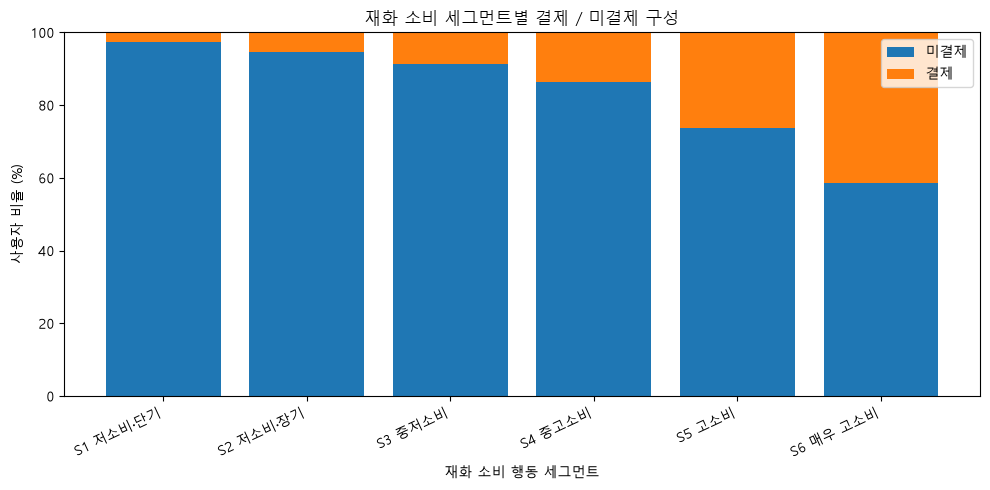

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    segment_df["segment"],
    segment_df["unpaid_rate"],
    label="미결제"
)

ax.bar(
    segment_df["segment"],
    segment_df["paid_rate"],
    bottom=segment_df["unpaid_rate"],
    label="결제"
)

ax.set_ylabel("사용자 비율 (%)")
ax.set_xlabel("재화 소비 행동 세그먼트")
ax.set_title("재화 소비 세그먼트별 결제 / 미결제 구성")
ax.set_ylim(0, 100)

plt.xticks(rotation=25, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np

# ==========================================
# 1. 프로젝트 data/processed 경로 자동 탐색
# ==========================================
current = Path.cwd()

processed_dir = None

for p in [current, *current.parents]:
    candidate = p / "data" / "processed"
    if candidate.exists():
        processed_dir = candidate
        break

if processed_dir is None:
    raise FileNotFoundError(
        "data/processed 폴더를 찾지 못했습니다. "
        "현재 작업 경로를 확인해주세요."
    )

print("processed_dir:", processed_dir)


# ==========================================
# 2. 데이터 로드
# ==========================================
users_df = pd.read_csv(
    processed_dir / "accounts_user_preprocessed_2.csv"
)

friends_df = pd.read_csv(
    processed_dir / "accounts_friendrequest_preprocessed_2.csv"
)

votes_df = pd.read_csv(
    processed_dir / "accounts_userquestionrecord_preprocessed_2.csv"
)

points_df = pd.read_csv(
    processed_dir / "accounts_pointhistory_preprocessed_2.csv"
)

payments_df = pd.read_csv(
    processed_dir / "accounts_paymenthistory_preprocessed_2.csv"
)


# ==========================================
# 3. 날짜형 변환
# ==========================================
for df in [users_df, votes_df, points_df, payments_df]:
    if "created_at" in df.columns:
        df["created_at"] = pd.to_datetime(
            df["created_at"],
            errors="coerce"
        )


# ==========================================
# 4. 팀에서 확정한 Funnel 재현
# ==========================================
step1_users = set(
    users_df["id"].dropna()
)

friend_users = (
    set(friends_df["receive_user_id"].dropna())
    .union(
        set(friends_df["send_user_id"].dropna())
    )
)

step2_users = friend_users.intersection(step1_users)

step3_users = (
    set(votes_df["chosen_user_id"].dropna())
    .intersection(step2_users)
)

step4_users = (
    set(points_df["user_id"].dropna())
    .intersection(step3_users)
)

step5_users = (
    set(payments_df["user_id"].dropna())
    .intersection(step4_users)
)

paid_users = step5_users
unpaid_users = step4_users - step5_users


# ==========================================
# 5. 확인
# ==========================================
print("Step 4:", len(step4_users))
print("Step 5:", len(step5_users))
print("미결제:", len(unpaid_users))

processed_dir: c:\Users\andan\OneDrive\바탕 화면\final_project\team4-final-project\data\processed
Step 4: 3367
Step 5: 358
미결제: 3009


In [7]:
# 날짜 타입 정리
votes_df["created_at"] = pd.to_datetime(
    votes_df["created_at"],
    errors="coerce"
)

points_df["created_at"] = pd.to_datetime(
    points_df["created_at"],
    errors="coerce"
)

# Step4까지 왔지만 결제하지 않은 사용자
unpaid_users = step4_users - step5_users

print("미결제 Step4 사용자:", len(unpaid_users))

미결제 Step4 사용자: 3009


In [9]:
import pandas as pd
import numpy as np

# 날짜형 정리
votes_df["created_at"] = pd.to_datetime(
    votes_df["created_at"], errors="coerce"
)

points_df["created_at"] = pd.to_datetime(
    points_df["created_at"], errors="coerce"
)

payments_df["created_at"] = pd.to_datetime(
    payments_df["created_at"], errors="coerce"
)


# 1. Step4 사용자
analysis_df = pd.DataFrame({
    "user_id": list(step4_users)
})

analysis_df["is_paid"] = (
    analysis_df["user_id"]
    .isin(step5_users)
    .astype(int)
)


# 2. 사용자별 최초 힌트/재화 소모 시점
first_hint = (
    points_df[
        points_df["user_id"].isin(step4_users)
    ]
    .groupby("user_id")["created_at"]
    .min()
    .rename("first_hint_time")
)

analysis_df = analysis_df.merge(
    first_hint,
    left_on="user_id",
    right_index=True,
    how="left"
)


# 3. 사용자별 최초 결제 시점
first_payment = (
    payments_df[
        payments_df["user_id"].isin(step5_users)
    ]
    .groupby("user_id")["created_at"]
    .min()
    .rename("first_payment_time")
)

analysis_df = analysis_df.merge(
    first_payment,
    left_on="user_id",
    right_index=True,
    how="left"
)


# 4. 결제가 최초 힌트보다 먼저 찍힌 사용자 제외
valid_payment_order = (
    analysis_df["first_payment_time"].isna()
    |
    (
        analysis_df["first_payment_time"]
        >= analysis_df["first_hint_time"]
    )
)

eda_df = analysis_df[
    valid_payment_order
].copy()


# 5. 최초 힌트 사용 전 투표 횟수 계산
vote_before_hint = (
    votes_df[["user_id", "created_at"]]
    .rename(columns={"created_at": "vote_time"})
    .merge(
        eda_df[["user_id", "first_hint_time"]],
        on="user_id",
        how="inner"
    )
)

vote_before_hint = vote_before_hint[
    vote_before_hint["vote_time"]
    < vote_before_hint["first_hint_time"]
]

pre_vote_count = (
    vote_before_hint
    .groupby("user_id")
    .size()
)

eda_df["pre_hint_vote_count"] = (
    eda_df["user_id"]
    .map(pre_vote_count)
    .fillna(0)
    .astype(int)
)


# 확인
print("EDA 대상:", len(eda_df))
print("미결제:", (eda_df["is_paid"] == 0).sum())
print("결제:", (eda_df["is_paid"] == 1).sum())

display(
    eda_df[
        ["user_id", "is_paid", "first_hint_time",
         "first_payment_time", "pre_hint_vote_count"]
    ].head()
)

EDA 대상: 3348
미결제: 3009
결제: 339


,user_id,is_paid,first_hint_time,first_payment_time,pre_hint_vote_count
0,1228800,0,2023-05-14 01:23:47,NaT,15
1,1105921,0,2023-05-17 14:28:20,NaT,1
2,1294338,0,2023-05-16 14:15:09,NaT,53
3,1392642,1,2023-05-23 07:24:02,2023-05-30 06:07:28,2
4,1425415,0,2023-05-21 12:35:06,NaT,10


In [11]:
import pandas as pd
import numpy as np

# 10회 단위 구간 만들기
max_vote = int(eda_df["pre_hint_vote_count"].max())
upper = ((max_vote // 10) + 1) * 10

bins = list(range(0, upper + 10, 10))

labels = []
for i in range(len(bins) - 1):
    start = bins[i]
    end = bins[i + 1] - 1
    labels.append(f"{start}~{end}회")

eda_df["vote_bin_10"] = pd.cut(
    eda_df["pre_hint_vote_count"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

bin10_summary = (
    eda_df
    .groupby("vote_bin_10", observed=True)
    .agg(
        users=("user_id", "count"),
        paid_users=("is_paid", "sum"),
        avg_votes=("pre_hint_vote_count", "mean")
    )
    .reset_index()
)

bin10_summary["payment_rate"] = (
    bin10_summary["paid_users"] / bin10_summary["users"] * 100
)

display(bin10_summary)

,vote_bin_10,users,paid_users,avg_votes,payment_rate
0,0~9회,1465,182,3.811604,12.423208
1,10~19회,813,91,13.777368,11.193112
2,20~29회,418,40,24.342105,9.569378
3,30~39회,213,14,34.497653,6.572770
4,40~49회,116,5,44.060345,4.310345
5,50~59회,73,2,53.753425,2.739726
6,60~69회,56,0,64.517857,0.000000
7,70~79회,42,1,74.904762,2.380952
8,80~89회,29,2,84.689655,6.896552
9,90~99회,13,0,94.000000,0.000000


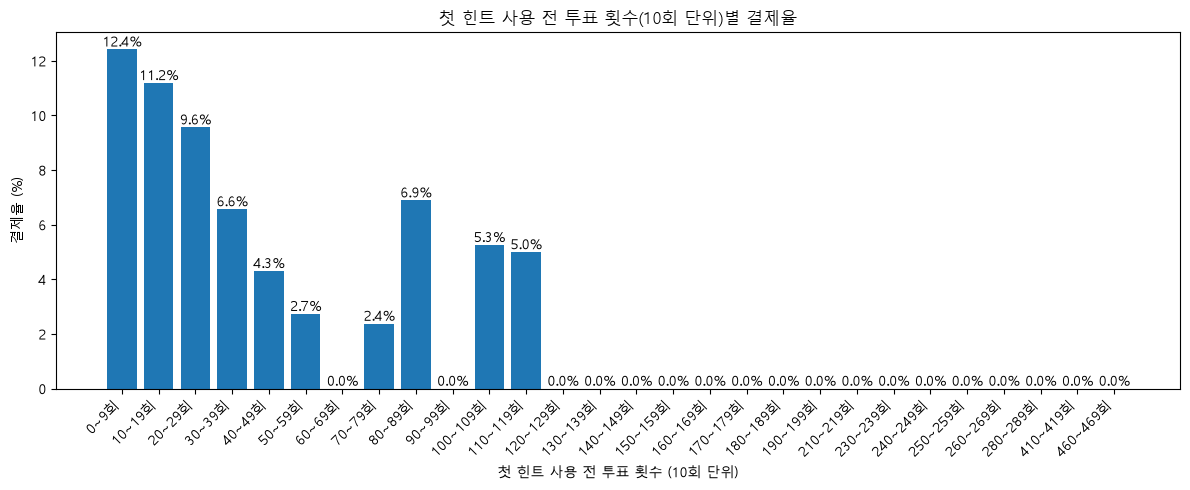

In [12]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

plot_df = bin10_summary.copy()

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    plot_df["vote_bin_10"].astype(str),
    plot_df["payment_rate"]
)

ax.set_xlabel("첫 힌트 사용 전 투표 횟수 (10회 단위)")
ax.set_ylabel("결제율 (%)")
ax.set_title("첫 힌트 사용 전 투표 횟수(10회 단위)별 결제율")

plt.xticks(rotation=45, ha="right")

for bar, value in zip(bars, plot_df["payment_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
vote1_summary = (
    eda_df
    .groupby("pre_hint_vote_count")
    .agg(
        users=("user_id", "count"),
        paid_users=("is_paid", "sum")
    )
    .reset_index()
)

vote1_summary["payment_rate"] = (
    vote1_summary["paid_users"] / vote1_summary["users"] * 100
)

display(vote1_summary)

,pre_hint_vote_count,users,paid_users,payment_rate
0,0,535,61,11.401869
1,1,72,12,16.666667
2,2,50,2,4.000000
3,3,72,13,18.055556
4,4,75,4,5.333333
5,5,82,11,13.414634
6,6,102,13,12.745098
7,7,127,17,13.385827
8,8,165,25,15.151515
9,9,185,24,12.972973


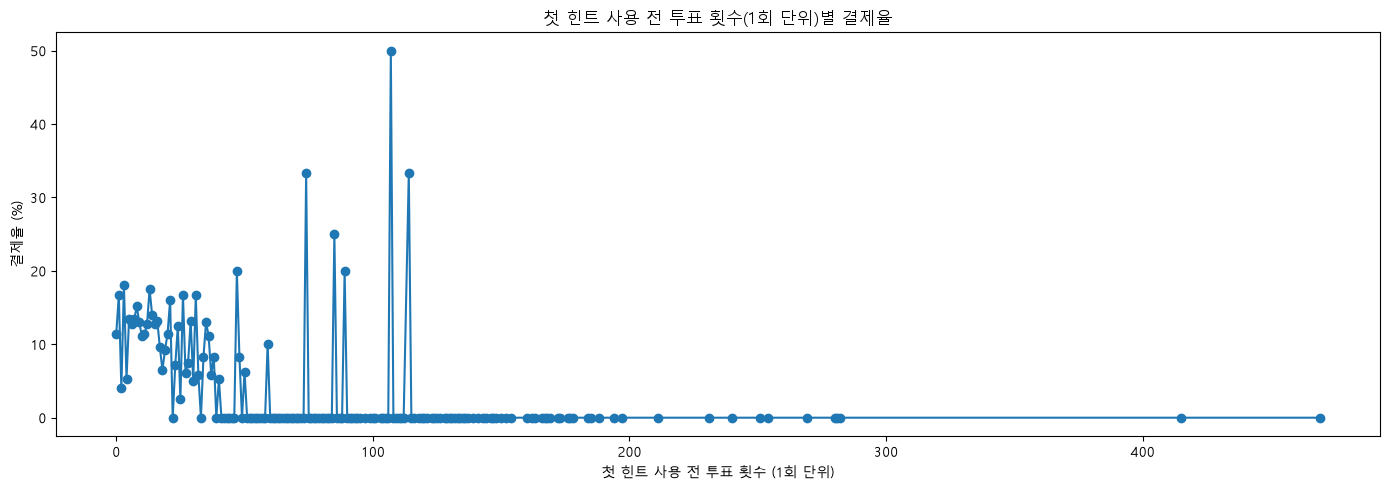

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    vote1_summary["pre_hint_vote_count"],
    vote1_summary["payment_rate"],
    marker="o"
)

ax.set_xlabel("첫 힌트 사용 전 투표 횟수 (1회 단위)")
ax.set_ylabel("결제율 (%)")
ax.set_title("첫 힌트 사용 전 투표 횟수(1회 단위)별 결제율")

plt.tight_layout()
plt.show()

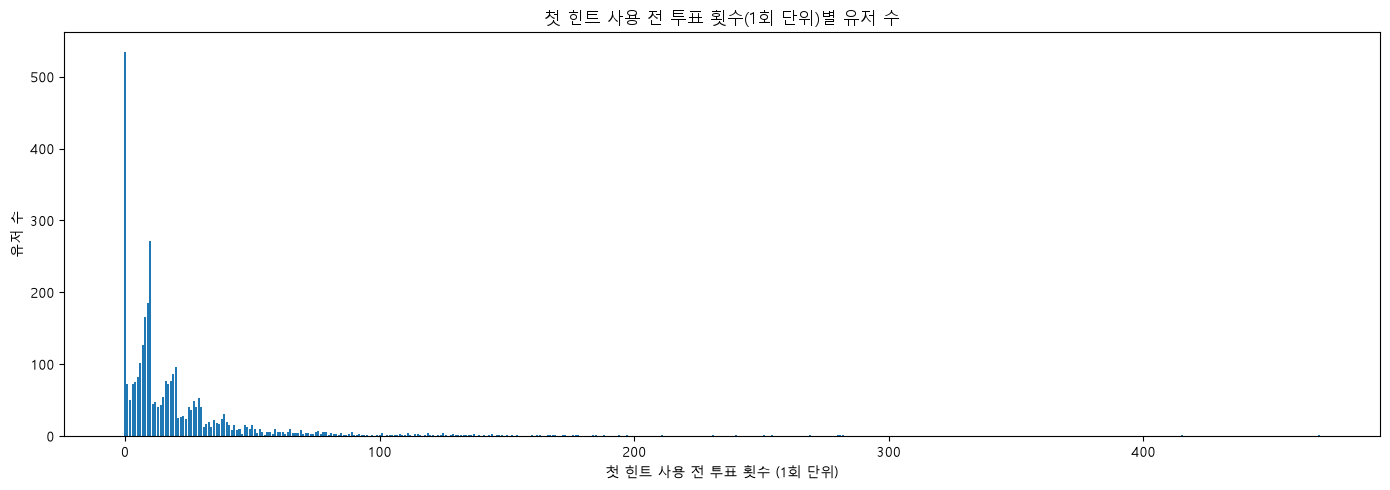

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    vote1_summary["pre_hint_vote_count"],
    vote1_summary["users"]
)

ax.set_xlabel("첫 힌트 사용 전 투표 횟수 (1회 단위)")
ax.set_ylabel("유저 수")
ax.set_title("첫 힌트 사용 전 투표 횟수(1회 단위)별 유저 수")

plt.tight_layout()
plt.show()

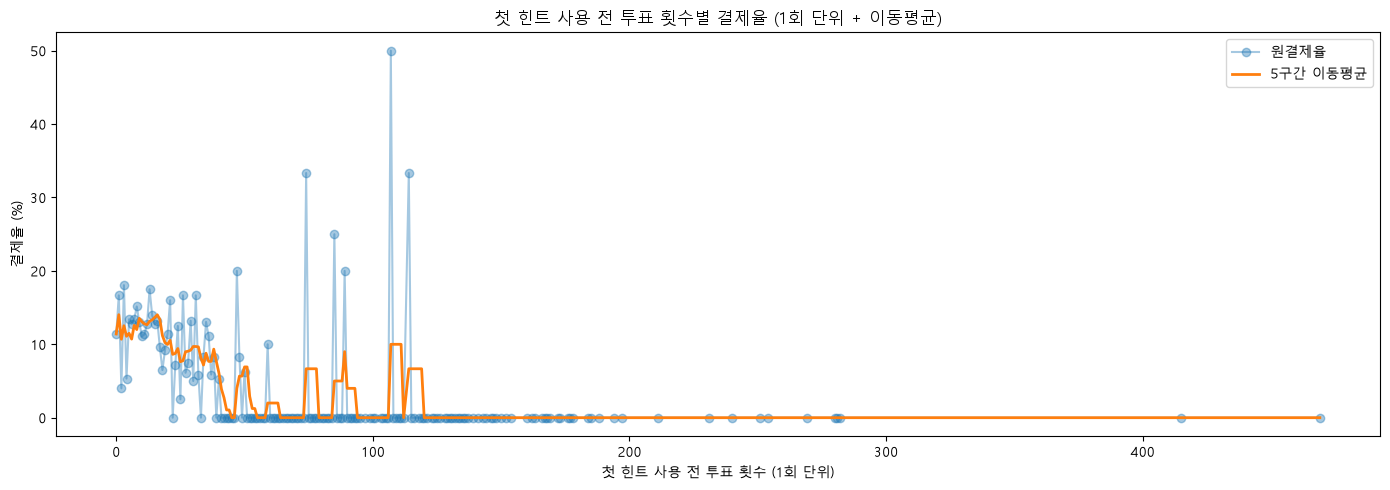

In [16]:
vote1_summary["payment_rate_ma5"] = (
    vote1_summary["payment_rate"]
    .rolling(window=5, min_periods=1)
    .mean()
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    vote1_summary["pre_hint_vote_count"],
    vote1_summary["payment_rate"],
    marker="o",
    alpha=0.4,
    label="원결제율"
)

ax.plot(
    vote1_summary["pre_hint_vote_count"],
    vote1_summary["payment_rate_ma5"],
    linewidth=2,
    label="5구간 이동평균"
)

ax.set_xlabel("첫 힌트 사용 전 투표 횟수 (1회 단위)")
ax.set_ylabel("결제율 (%)")
ax.set_title("첫 힌트 사용 전 투표 횟수별 결제율 (1회 단위 + 이동평균)")
ax.legend()

plt.tight_layout()
plt.show()

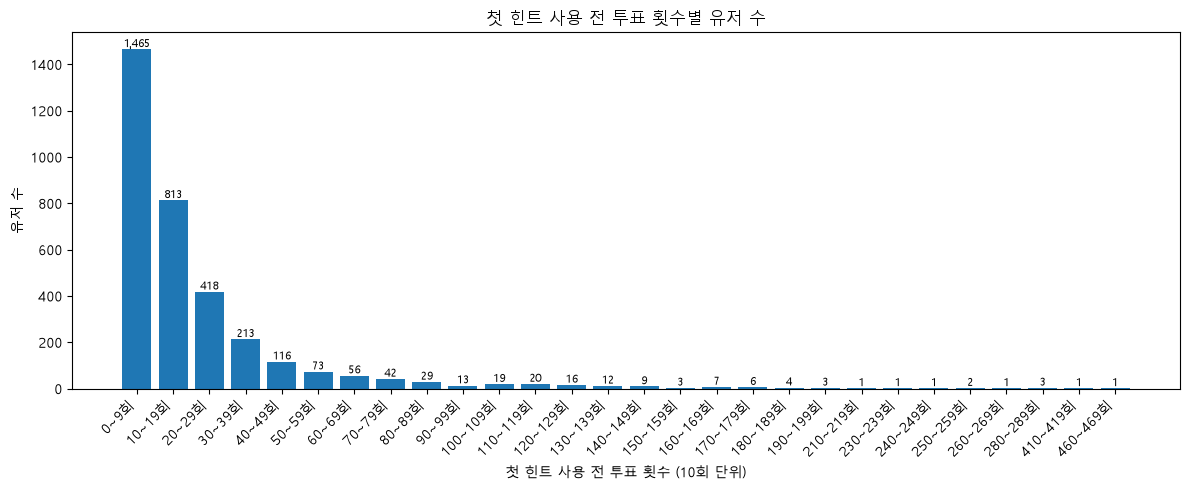

In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    bin10_summary["vote_bin_10"].astype(str),
    bin10_summary["users"]
)

ax.set_xlabel("첫 힌트 사용 전 투표 횟수 (10회 단위)")
ax.set_ylabel("유저 수")
ax.set_title("첫 힌트 사용 전 투표 횟수별 유저 수")

plt.xticks(rotation=45, ha="right")

for bar, value in zip(
    bars,
    bin10_summary["users"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [18]:
def make_vote_group(x):
    if x < 10:
        return "0~9회"
    elif x < 20:
        return "10~19회"
    elif x < 30:
        return "20~29회"
    elif x < 40:
        return "30~39회"
    elif x < 50:
        return "40~49회"
    elif x < 60:
        return "50~59회"
    else:
        return "60회 이상"

eda_df["vote_group"] = (
    eda_df["pre_hint_vote_count"]
    .apply(make_vote_group)
)

order = [
    "0~9회",
    "10~19회",
    "20~29회",
    "30~39회",
    "40~49회",
    "50~59회",
    "60회 이상"
]

user_count_summary = (
    eda_df
    .groupby("vote_group")
    .agg(
        users=("user_id", "count")
    )
    .reindex(order)
    .reset_index()
)

display(user_count_summary)

,vote_group,users
0,0~9회,1465
1,10~19회,813
2,20~29회,418
3,30~39회,213
4,40~49회,116
5,50~59회,73
6,60회 이상,250


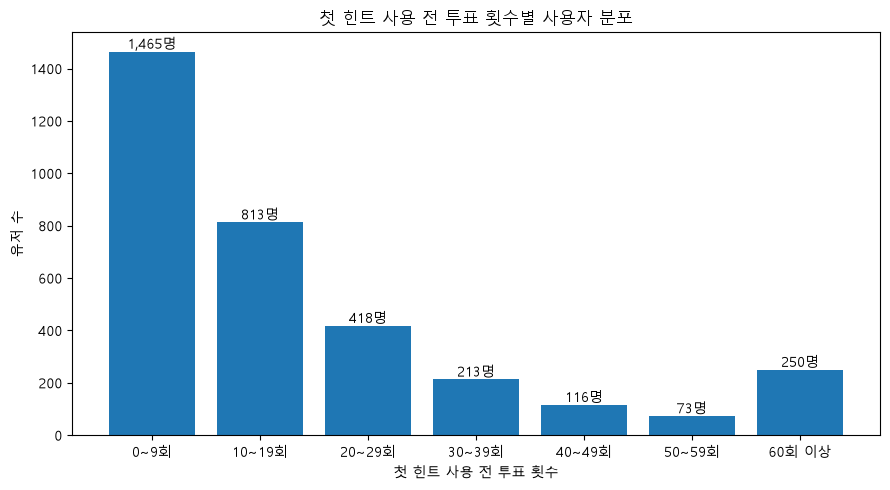

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    user_count_summary["vote_group"],
    user_count_summary["users"]
)

ax.set_xlabel("첫 힌트 사용 전 투표 횟수")
ax.set_ylabel("유저 수")
ax.set_title("첫 힌트 사용 전 투표 횟수별 사용자 분포")

for bar, value in zip(
    bars,
    user_count_summary["users"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}명",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [20]:
bin10_user_summary = (
    eda_df
    .groupby("vote_group")
    .agg(
        users=("user_id", "count"),
        paid_users=("is_paid", "sum")
    )
    .reindex(order)
    .reset_index()
)

bin10_user_summary["unpaid_users"] = (
    bin10_user_summary["users"]
    - bin10_user_summary["paid_users"]
)

display(bin10_user_summary)

,vote_group,users,paid_users,unpaid_users
0,0~9회,1465,182,1283
1,10~19회,813,91,722
2,20~29회,418,40,378
3,30~39회,213,14,199
4,40~49회,116,5,111
5,50~59회,73,2,71
6,60회 이상,250,5,245


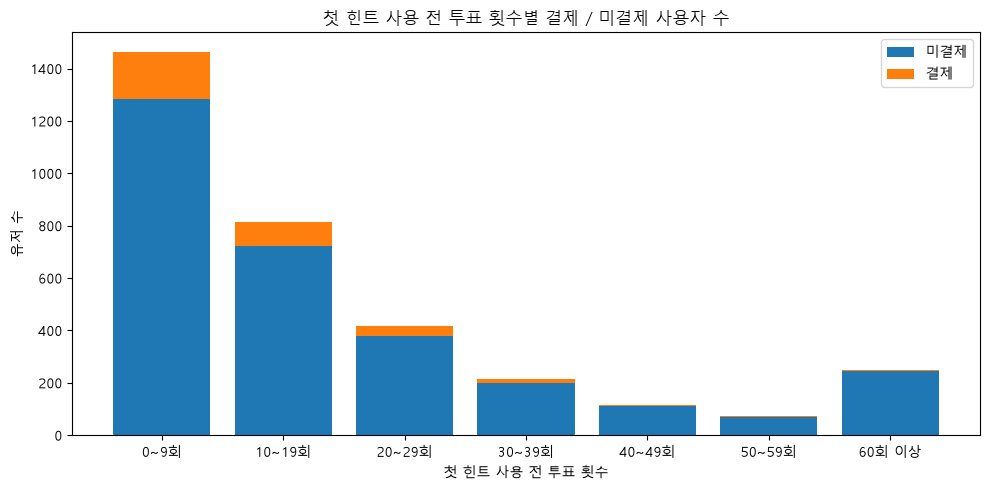

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    bin10_user_summary["vote_group"],
    bin10_user_summary["unpaid_users"],
    label="미결제"
)

ax.bar(
    bin10_user_summary["vote_group"],
    bin10_user_summary["paid_users"],
    bottom=bin10_user_summary["unpaid_users"],
    label="결제"
)

ax.set_xlabel("첫 힌트 사용 전 투표 횟수")
ax.set_ylabel("유저 수")
ax.set_title("첫 힌트 사용 전 투표 횟수별 결제 / 미결제 사용자 수")

ax.legend()

plt.tight_layout()
plt.show()

In [22]:
# 결제자만 추출
paid_df = eda_df[
    eda_df["is_paid"] == 1
].copy()

print("결제자 수:", len(paid_df))

결제자 수: 339


In [23]:
paid_vote_summary = (
    paid_df
    .groupby("vote_group")
    .agg(
        users=("user_id", "count")
    )
    .reindex(order)
    .reset_index()
)

display(paid_vote_summary)

,vote_group,users
0,0~9회,182
1,10~19회,91
2,20~29회,40
3,30~39회,14
4,40~49회,5
5,50~59회,2
6,60회 이상,5


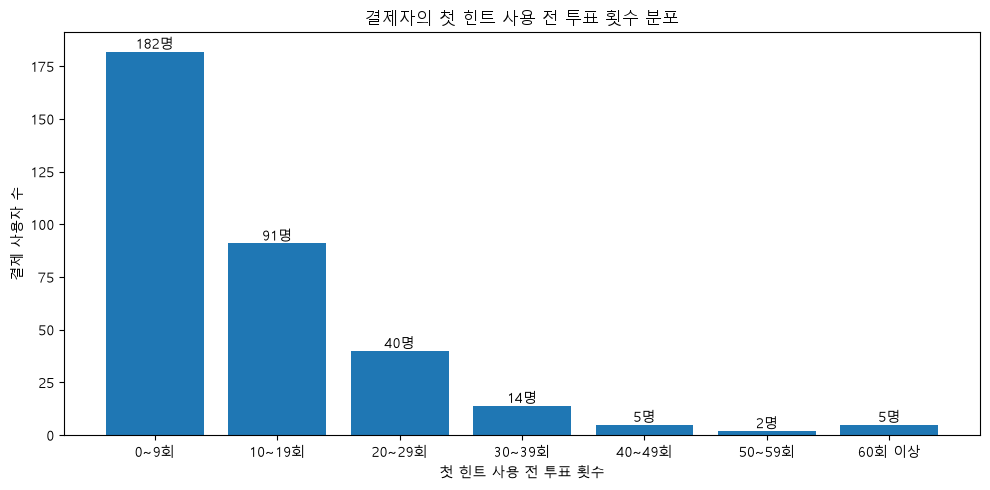

In [24]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    paid_vote_summary["vote_group"],
    paid_vote_summary["users"]
)

ax.set_xlabel("첫 힌트 사용 전 투표 횟수")
ax.set_ylabel("결제 사용자 수")
ax.set_title("결제자의 첫 힌트 사용 전 투표 횟수 분포")

for bar, value in zip(
    bars,
    paid_vote_summary["users"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}명",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [29]:
ax.set_xlim(0, 100)

(0.0, 100.0)

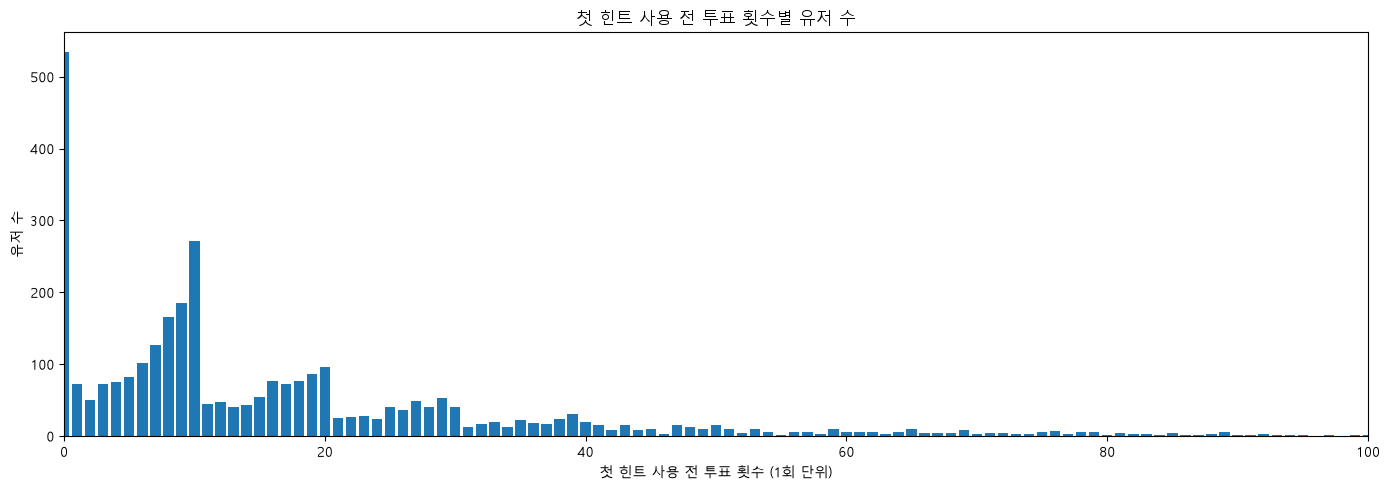

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    vote1_summary["pre_hint_vote_count"],
    vote1_summary["users"]
)

ax.set_xlabel("첫 힌트 사용 전 투표 횟수 (1회 단위)")
ax.set_ylabel("유저 수")
ax.set_title("첫 힌트 사용 전 투표 횟수별 유저 수")

# 0~100회만 보기
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
votes_df["created_at"] = pd.to_datetime(
    votes_df["created_at"],
    errors="coerce"
)

votes_df["date"] = votes_df["created_at"].dt.date

daily_votes = (
    votes_df
    .groupby(["user_id", "date"])
    .size()
    .reset_index(name="daily_vote_count")
)

display(daily_votes.head())

,user_id,date,daily_vote_count
0,838466,2023-06-02,2
1,838466,2023-09-18,2
2,839357,2023-05-26,7
3,840293,2023-05-15,8
4,840473,2023-05-14,7


In [8]:
print(daily_votes.columns.tolist())

['user_id', 'date', 'daily_vote_count']


In [9]:
# 10회 투표 = 1세트 완료
daily_votes["completed_sets"] = (
    daily_votes["daily_vote_count"] // 10
)

# 세트 완료 후 남은 투표 횟수
daily_votes["remaining_votes"] = (
    daily_votes["daily_vote_count"] % 10
)

display(daily_votes.head())

,user_id,date,daily_vote_count,completed_sets,remaining_votes
0,838466,2023-06-02,2,0,2
1,838466,2023-09-18,2,0,2
2,839357,2023-05-26,7,0,7
3,840293,2023-05-15,8,0,8
4,840473,2023-05-14,7,0,7


In [10]:
print(daily_votes.columns.tolist())

print(
    "하루 최대 투표 횟수:",
    daily_votes["daily_vote_count"].max()
)

print(
    "하루 최대 완료 세트:",
    daily_votes["completed_sets"].max()
)

['user_id', 'date', 'daily_vote_count', 'completed_sets', 'remaining_votes']
하루 최대 투표 횟수: 212
하루 최대 완료 세트: 21


In [11]:
display(
    daily_votes["completed_sets"].describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

count    36848.000000
mean         1.726634
std          2.463892
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
90%          5.000000
95%          7.000000
99%         12.000000
max         21.000000
Name: completed_sets, dtype: float64

In [12]:
for n in [1, 2, 3, 4, 5]:
    ratio = (
        (daily_votes["completed_sets"] >= n)
        .mean()
        * 100
    )

    print(
        f"하루 {n}세트 이상 완료한 유저-일 비율: "
        f"{ratio:.2f}%"
    )

하루 1세트 이상 완료한 유저-일 비율: 62.43%
하루 2세트 이상 완료한 유저-일 비율: 34.05%
하루 3세트 이상 완료한 유저-일 비율: 22.31%
하루 4세트 이상 완료한 유저-일 비율: 15.53%
하루 5세트 이상 완료한 유저-일 비율: 11.07%


In [13]:
user_max_daily_sets = (
    daily_votes
    .groupby("user_id")["completed_sets"]
    .max()
)

for n in [1, 2, 3, 4, 5]:
    ratio = (
        (user_max_daily_sets >= n)
        .mean()
        * 100
    )

    print(
        f"하루 {n}세트 이상 완료 경험이 있는 유저 비율: "
        f"{ratio:.2f}%"
    )

하루 1세트 이상 완료 경험이 있는 유저 비율: 84.51%
하루 2세트 이상 완료 경험이 있는 유저 비율: 65.28%
하루 3세트 이상 완료 경험이 있는 유저 비율: 52.75%
하루 4세트 이상 완료 경험이 있는 유저 비율: 42.62%
하루 5세트 이상 완료 경험이 있는 유저 비율: 34.63%


In [14]:
# 현재 정책: 모든 완료 세트 200P
daily_votes["current_reward"] = (
    daily_votes["completed_sets"] * 200
)

# 개선안:
# 하루 첫 세트 200P
# 2세트째부터 세트당 100P
daily_votes["treatment_reward"] = np.where(
    daily_votes["completed_sets"] == 0,
    0,
    200 + (daily_votes["completed_sets"] - 1) * 100
)

current_total = daily_votes["current_reward"].sum()
treatment_total = daily_votes["treatment_reward"].sum()

reduction_rate = (
    1 - treatment_total / current_total
) * 100

print(f"현재 총 지급 포인트: {current_total:,.0f}P")
print(f"개선안 총 지급 포인트: {treatment_total:,.0f}P")
print(f"무료 포인트 감소율: {reduction_rate:.2f}%")

현재 총 지급 포인트: 12,724,600P
개선안 총 지급 포인트: 8,662,700P
무료 포인트 감소율: 31.92%


In [15]:
import numpy as np
import pandas as pd

# 현재 정책
daily_votes["reward_current"] = (
    daily_votes["completed_sets"] * 200
)

# A안: 하루 첫 세트 200P, 이후 100P
daily_votes["reward_A"] = np.where(
    daily_votes["completed_sets"] == 0,
    0,
    200 + (daily_votes["completed_sets"] - 1) * 100
)

# B안: 하루 첫 세트 200P, 이후 150P
daily_votes["reward_B"] = np.where(
    daily_votes["completed_sets"] == 0,
    0,
    200 + (daily_votes["completed_sets"] - 1) * 150
)

# C안: 하루 첫 2세트 200P, 3세트부터 100P
daily_votes["reward_C"] = np.where(
    daily_votes["completed_sets"] == 0,
    0,
    np.where(
        daily_votes["completed_sets"] == 1,
        200,
        400 + (daily_votes["completed_sets"] - 2) * 100
    )
)

policies = [
    "reward_current",
    "reward_A",
    "reward_B",
    "reward_C"
]

result = []

base = daily_votes["reward_current"].sum()

for policy in policies:
    total = daily_votes[policy].sum()

    result.append({
        "policy": policy,
        "total_reward": total,
        "reduction_rate": (1 - total / base) * 100
    })

policy_compare = pd.DataFrame(result)

display(policy_compare)

,policy,total_reward,reduction_rate
0,reward_current,12724600,0.000000
1,reward_A,8662700,31.921632
2,reward_B,10693650,15.960816
3,reward_C,9917400,22.061204


In [19]:
import pandas as pd
import numpy as np

# =========================
# 0. 필요한 데이터 확인
# =========================
required_dfs = [
    "users_df",
    "friends_df",
    "votes_df",
    "points_df",
    "payments_df"
]

missing = [
    name for name in required_dfs
    if name not in globals()
]

if missing:
    raise NameError(
        f"먼저 로드해야 하는 데이터프레임: {missing}"
    )

# =========================
# 1. 날짜형 변환
# =========================
votes_df["created_at"] = pd.to_datetime(
    votes_df["created_at"],
    errors="coerce"
)

points_df["created_at"] = pd.to_datetime(
    points_df["created_at"],
    errors="coerce"
)

payments_df["created_at"] = pd.to_datetime(
    payments_df["created_at"],
    errors="coerce"
)

# =========================
# 2. 기존 확정 퍼널 복구
# =========================
step1_users = set(
    users_df["id"].dropna()
)

friend_users = (
    set(friends_df["receive_user_id"].dropna())
    .union(
        set(friends_df["send_user_id"].dropna())
    )
)

step2_users = (
    friend_users
    .intersection(step1_users)
)

step3_users = (
    set(votes_df["chosen_user_id"].dropna())
    .intersection(step2_users)
)

step4_users = (
    set(points_df["user_id"].dropna())
    .intersection(step3_users)
)

step5_users = (
    set(payments_df["user_id"].dropna())
    .intersection(step4_users)
)

# =========================
# 3. Step4 사용자 분석 테이블
# =========================
analysis_df = pd.DataFrame({
    "user_id": list(step4_users)
})

analysis_df["is_paid"] = (
    analysis_df["user_id"]
    .isin(step5_users)
    .astype(int)
)

# 첫 힌트/포인트 사용 시점
first_hint = (
    points_df[
        points_df["user_id"].isin(step4_users)
    ]
    .groupby("user_id")["created_at"]
    .min()
    .rename("first_hint_time")
)

analysis_df = analysis_df.merge(
    first_hint,
    left_on="user_id",
    right_index=True,
    how="left"
)

# 첫 결제 시점
first_payment = (
    payments_df[
        payments_df["user_id"].isin(step5_users)
    ]
    .groupby("user_id")["created_at"]
    .min()
    .rename("first_payment_time")
)

analysis_df = analysis_df.merge(
    first_payment,
    left_on="user_id",
    right_index=True,
    how="left"
)

# =========================
# 4. 결제 → 힌트 순서가 뒤집힌 19명 제외
# =========================
valid_payment_order = (
    analysis_df["first_payment_time"].isna()
    |
    (
        analysis_df["first_payment_time"]
        >= analysis_df["first_hint_time"]
    )
)

eda_df = (
    analysis_df[
        valid_payment_order
    ]
    .copy()
)

# =========================
# 5. 첫 힌트 전 투표 횟수
# =========================
vote_before_hint = (
    votes_df[
        ["user_id", "created_at"]
    ]
    .rename(
        columns={"created_at": "vote_time"}
    )
    .merge(
        eda_df[
            ["user_id", "first_hint_time"]
        ],
        on="user_id",
        how="inner"
    )
)

vote_before_hint = vote_before_hint[
    vote_before_hint["vote_time"]
    < vote_before_hint["first_hint_time"]
]

pre_vote_count = (
    vote_before_hint
    .groupby("user_id")
    .size()
)

eda_df["pre_hint_vote_count"] = (
    eda_df["user_id"]
    .map(pre_vote_count)
    .fillna(0)
    .astype(int)
)

# 10회 = 1세트
eda_df["pre_hint_completed_sets"] = (
    eda_df["pre_hint_vote_count"] // 10
)

# =========================
# 6. 확인
# =========================
print("EDA 대상:", len(eda_df))
print(
    "미결제:",
    (eda_df["is_paid"] == 0).sum()
)
print(
    "결제:",
    (eda_df["is_paid"] == 1).sum()
)

display(
    eda_df[
        [
            "user_id",
            "is_paid",
            "first_hint_time",
            "first_payment_time",
            "pre_hint_vote_count",
            "pre_hint_completed_sets"
        ]
    ].head()
)

EDA 대상: 3348
미결제: 3009
결제: 339


,user_id,is_paid,first_hint_time,first_payment_time,pre_hint_vote_count,pre_hint_completed_sets
0,1228800,0,2023-05-14 01:23:47,NaT,15,1
1,1105921,0,2023-05-17 14:28:20,NaT,1,0
2,1294338,0,2023-05-16 14:15:09,NaT,53,5
3,1392642,1,2023-05-23 07:24:02,2023-05-30 06:07:28,2,0
4,1425415,0,2023-05-21 12:35:06,NaT,10,1


In [20]:
thresholds = [10, 20, 30, 40, 50, 60]
window = 2

threshold_result = []

for t in thresholds:

    # 보상 획득 직전
    below = eda_df[
        eda_df["pre_hint_vote_count"].between(
            t - window,
            t - 1
        )
    ]

    # 보상 획득 직후
    above = eda_df[
        eda_df["pre_hint_vote_count"].between(
            t,
            t + window - 1
        )
    ]

    below_rate = below["is_paid"].mean() * 100
    above_rate = above["is_paid"].mean() * 100

    threshold_result.append({
        "threshold": t,
        "below_range": f"{t-window}~{t-1}",
        "above_range": f"{t}~{t+window-1}",
        "below_users": len(below),
        "above_users": len(above),
        "below_payment_rate": below_rate,
        "above_payment_rate": above_rate,
        "difference_pp": above_rate - below_rate
    })

threshold_df = pd.DataFrame(threshold_result)

display(threshold_df)

,threshold,below_range,above_range,below_users,above_users,below_payment_rate,above_payment_rate,difference_pp
0,10,8~9,10~11,350,315,14.000000,11.111111,-2.888889
1,20,18~19,20~21,164,121,7.926829,12.396694,4.469865
2,30,28~29,30~31,93,52,10.752688,7.692308,-3.060380
3,40,38~39,40~41,54,34,3.703704,2.941176,-0.762527
4,50,48~49,50~51,22,26,4.545455,3.846154,-0.699301
5,60,58~59,60~61,13,12,7.692308,0.000000,-7.692308


In [21]:
observation_end = max(
    votes_df["created_at"].max(),
    points_df["created_at"].max(),
    payments_df["created_at"].max()
)

print(observation_end)

2024-05-07 11:29:07


In [22]:
def make_fixed_window_summary(days):

    temp = eda_df[
        eda_df["first_hint_time"]
        <= observation_end - pd.Timedelta(days=days)
    ].copy()

    temp[f"paid_{days}d"] = (
        temp["first_payment_time"].notna()
        &
        (
            temp["first_payment_time"]
            <= temp["first_hint_time"]
            + pd.Timedelta(days=days)
        )
    ).astype(int)

    def set_group(x):
        if x == 0:
            return "0세트"
        elif x == 1:
            return "1세트"
        elif x == 2:
            return "2세트"
        elif x == 3:
            return "3세트"
        elif x == 4:
            return "4세트"
        elif x == 5:
            return "5세트"
        else:
            return "6세트 이상"

    temp["set_group"] = (
        temp["pre_hint_completed_sets"]
        .apply(set_group)
    )

    order = [
        "0세트",
        "1세트",
        "2세트",
        "3세트",
        "4세트",
        "5세트",
        "6세트 이상"
    ]

    result = (
        temp
        .groupby("set_group")
        .agg(
            users=("user_id", "count"),
            paid=(f"paid_{days}d", "sum")
        )
        .reindex(order)
        .reset_index()
    )

    result["payment_rate"] = (
        result["paid"]
        / result["users"]
        * 100
    )

    return result

In [23]:
display(make_fixed_window_summary(7))
display(make_fixed_window_summary(14))
display(make_fixed_window_summary(30))

,set_group,users,paid,payment_rate
0,0세트,1465,159,10.853242
1,1세트,813,78,9.594096
2,2세트,418,39,9.330144
3,3세트,213,14,6.572770
4,4세트,116,5,4.310345
5,5세트,73,2,2.739726
6,6세트 이상,250,4,1.600000


,set_group,users,paid,payment_rate
0,0세트,1465,165,11.262799
1,1세트,813,86,10.578106
2,2세트,418,39,9.330144
3,3세트,213,14,6.572770
4,4세트,116,5,4.310345
5,5세트,73,2,2.739726
6,6세트 이상,250,4,1.600000


,set_group,users,paid,payment_rate
0,0세트,1465,176,12.013652
1,1세트,813,90,11.070111
2,2세트,418,40,9.569378
3,3세트,213,14,6.572770
4,4세트,116,5,4.310345
5,5세트,73,2,2.739726
6,6세트 이상,250,4,1.600000


In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================
# 1. 현재 Jupyter 실행 위치 확인
# =========================
cwd = Path.cwd()

print("현재 작업 경로:")
print(cwd)

# =========================
# 2. team4-final-project 루트 자동 탐색
# =========================
project_root = None

for path in [cwd, *cwd.parents]:
    if (path / "data" / "processed").exists():
        project_root = path
        break

if project_root is None:
    raise FileNotFoundError(
        "프로젝트 루트에서 data/processed 폴더를 찾지 못했습니다."
    )

DATA_PATH = project_root / "data" / "processed"

print("\n프로젝트 루트:")
print(project_root)

print("\n데이터 경로:")
print(DATA_PATH)

print("\nprocessed 폴더 파일:")
for f in DATA_PATH.iterdir():
    print("-", f.name)

현재 작업 경로:
c:\Users\andan\OneDrive\바탕 화면\final_project\team4-final-project\notebooks\eda\selected_segments\step4_5_spend_to_payment

프로젝트 루트:
c:\Users\andan\OneDrive\바탕 화면\final_project\team4-final-project

데이터 경로:
c:\Users\andan\OneDrive\바탕 화면\final_project\team4-final-project\data\processed

processed 폴더 파일:
- .gitkeep
- accounts_friendrequest_preprocessed_2.csv
- accounts_paymenthistory_preprocessed_2.csv
- accounts_pointhistory_preprocessed_2.csv
- accounts_userquestionrecord_preprocessed_2.csv
- accounts_user_preprocessed_2.csv
- polls_questionpiece_preprocessed_2.csv


In [11]:
# =========================
# 3. 데이터 로드
# =========================
users_df = pd.read_csv(
    DATA_PATH / "accounts_user_preprocessed_2.csv"
)

friends_df = pd.read_csv(
    DATA_PATH / "accounts_friendrequest_preprocessed_2.csv"
)

votes_df = pd.read_csv(
    DATA_PATH / "accounts_userquestionrecord_preprocessed_2.csv"
)

points_df = pd.read_csv(
    DATA_PATH / "accounts_pointhistory_preprocessed_2.csv"
)

payments_df = pd.read_csv(
    DATA_PATH / "accounts_paymenthistory_preprocessed_2.csv"
)

print("데이터 로드 완료")

print("users_df   :", users_df.shape)
print("friends_df :", friends_df.shape)
print("votes_df   :", votes_df.shape)
print("points_df  :", points_df.shape)
print("payments_df:", payments_df.shape)

데이터 로드 완료
users_df   : (677075, 11)
friends_df : (7793140, 6)
votes_df   : (800793, 12)
points_df  : (88762, 5)
payments_df: (95137, 5)


In [13]:
# ============================================================
# 0. 라이브러리 및 데이터 경로
# ============================================================
import pandas as pd
import numpy as np
from pathlib import Path

# 현재 위치에서 프로젝트 루트 자동 탐색
cwd = Path.cwd()

project_root = None

for path in [cwd, *cwd.parents]:
    if (path / "data" / "processed").exists():
        project_root = path
        break

if project_root is None:
    raise FileNotFoundError(
        "data/processed 폴더를 찾지 못했습니다."
    )

DATA_PATH = project_root / "data" / "processed"

print("프로젝트 루트:", project_root)
print("데이터 경로:", DATA_PATH)


# ============================================================
# 1. 데이터 로드
# ============================================================
users_df = pd.read_csv(
    DATA_PATH / "accounts_user_preprocessed_2.csv"
)

friends_df = pd.read_csv(
    DATA_PATH / "accounts_friendrequest_preprocessed_2.csv"
)

votes_df = pd.read_csv(
    DATA_PATH / "accounts_userquestionrecord_preprocessed_2.csv"
)

points_df = pd.read_csv(
    DATA_PATH / "accounts_pointhistory_preprocessed_2.csv"
)

payments_df = pd.read_csv(
    DATA_PATH / "accounts_paymenthistory_preprocessed_2.csv"
)

print("\n[데이터 로드 완료]")
print("users_df   :", users_df.shape)
print("friends_df :", friends_df.shape)
print("votes_df   :", votes_df.shape)
print("points_df  :", points_df.shape)
print("payments_df:", payments_df.shape)


# ============================================================
# 2. 날짜형 변환
# ============================================================
votes_df["created_at"] = pd.to_datetime(
    votes_df["created_at"],
    errors="coerce"
)

points_df["created_at"] = pd.to_datetime(
    points_df["created_at"],
    errors="coerce"
)

payments_df["created_at"] = pd.to_datetime(
    payments_df["created_at"],
    errors="coerce"
)


# ============================================================
# 3. 기존 확정 퍼널 복구
# ============================================================

# Step 1
step1_users = set(
    users_df["id"].dropna()
)

# Step 2
friend_users = (
    set(friends_df["receive_user_id"].dropna())
    .union(
        set(friends_df["send_user_id"].dropna())
    )
)

step2_users = (
    friend_users
    .intersection(step1_users)
)

# Step 3
step3_users = (
    set(votes_df["chosen_user_id"].dropna())
    .intersection(step2_users)
)

# Step 4
step4_users = (
    set(points_df["user_id"].dropna())
    .intersection(step3_users)
)

# Step 5
step5_users = (
    set(payments_df["user_id"].dropna())
    .intersection(step4_users)
)

paid_users = step5_users
churned_users = step4_users - step5_users

print("\n[퍼널 확인]")
print("Step 1:", len(step1_users))
print("Step 2:", len(step2_users))
print("Step 3:", len(step3_users))
print("Step 4:", len(step4_users))
print("Step 5:", len(step5_users))


# ============================================================
# 4. Step4 사용자 기준 분석 테이블 생성
# ============================================================
analysis_df = pd.DataFrame({
    "user_id": list(step4_users)
})

analysis_df["is_paid"] = (
    analysis_df["user_id"]
    .isin(step5_users)
    .astype(int)
)


# ============================================================
# 5. 첫 힌트 사용 시점
# ============================================================
first_hint = (
    points_df[
        points_df["user_id"].isin(step4_users)
    ]
    .groupby("user_id")["created_at"]
    .min()
    .rename("first_hint_time")
)

analysis_df = analysis_df.merge(
    first_hint,
    left_on="user_id",
    right_index=True,
    how="left"
)


# ============================================================
# 6. 첫 결제 시점
# ============================================================
first_payment = (
    payments_df[
        payments_df["user_id"].isin(step5_users)
    ]
    .groupby("user_id")["created_at"]
    .min()
    .rename("first_payment_time")
)

analysis_df = analysis_df.merge(
    first_payment,
    left_on="user_id",
    right_index=True,
    how="left"
)


# ============================================================
# 7. 시간 순서 검증
#    첫 결제가 첫 힌트보다 먼저 발생한 사용자는
#    시간 기반 EDA에서만 제외
# ============================================================
valid_payment_order = (
    analysis_df["first_payment_time"].isna()
    |
    (
        analysis_df["first_payment_time"]
        >= analysis_df["first_hint_time"]
    )
)

eda_df = (
    analysis_df[
        valid_payment_order
    ]
    .copy()
)

print("\n[EDA 대상]")
print("전체:", len(eda_df))
print(
    "미결제:",
    (eda_df["is_paid"] == 0).sum()
)
print(
    "결제:",
    (eda_df["is_paid"] == 1).sum()
)


# ============================================================
# 8. 첫 힌트 사용 이전 투표 로그 생성
# ============================================================
vote_before_hint = (
    votes_df[
        ["user_id", "created_at"]
    ]
    .rename(
        columns={"created_at": "vote_time"}
    )
    .merge(
        eda_df[
            ["user_id", "first_hint_time"]
        ],
        on="user_id",
        how="inner"
    )
)

vote_before_hint = (
    vote_before_hint[
        vote_before_hint["vote_time"]
        < vote_before_hint["first_hint_time"]
    ]
    .copy()
)

print(
    "\n첫 힌트 전 투표 로그:",
    len(vote_before_hint)
)


# ============================================================
# 9. 첫 힌트 전 투표 횟수
# ============================================================
pre_vote_count = (
    vote_before_hint
    .groupby("user_id")
    .size()
)

eda_df["pre_hint_vote_count"] = (
    eda_df["user_id"]
    .map(pre_vote_count)
    .fillna(0)
    .astype(int)
)

# 10회 = 1세트
eda_df["pre_hint_completed_sets"] = (
    eda_df["pre_hint_vote_count"] // 10
)

print("\n[eda_df 확인]")

display(
    eda_df[
        [
            "user_id",
            "is_paid",
            "first_hint_time",
            "first_payment_time",
            "pre_hint_vote_count",
            "pre_hint_completed_sets"
        ]
    ].head()
)


# ============================================================
# 여기서부터 새 EDA
# 집중 파밍 vs 분산 참여
# ============================================================


# ============================================================
# 10. 첫 힌트 전 '활동한 날짜' 계산
# ============================================================
vote_before_hint["vote_date"] = (
    vote_before_hint["vote_time"]
    .dt.normalize()
)

farming_pattern = (
    vote_before_hint
    .groupby("user_id")
    .agg(
        pre_hint_votes=(
            "vote_time",
            "size"
        ),
        pre_hint_active_days=(
            "vote_date",
            "nunique"
        ),
        first_vote_date=(
            "vote_date",
            "min"
        ),
        last_vote_date=(
            "vote_date",
            "max"
        )
    )
    .reset_index()
)


# ============================================================
# 11. 파밍 패턴 변수 생성
# ============================================================

# 첫 투표일부터 마지막 투표일까지 기간
farming_pattern["pre_hint_span_days"] = (
    farming_pattern["last_vote_date"]
    - farming_pattern["first_vote_date"]
).dt.days + 1

# 실제 투표한 날 기준 하루 평균 투표 수
farming_pattern["votes_per_active_day"] = (
    farming_pattern["pre_hint_votes"]
    / farming_pattern["pre_hint_active_days"]
)

# 전체 기간 대비 투표 집중도
farming_pattern["farming_intensity"] = (
    farming_pattern["pre_hint_votes"]
    / farming_pattern["pre_hint_span_days"]
)

display(farming_pattern.head())


# ============================================================
# 12. eda_df와 파밍 패턴 결합
# ============================================================
eda_pattern_df = (
    eda_df
    .merge(
        farming_pattern,
        on="user_id",
        how="left"
    )
)

# 첫 힌트 전에 투표를 한 사용자만 분석
pattern_df = (
    eda_pattern_df[
        eda_pattern_df["pre_hint_vote_count"] > 0
    ]
    .copy()
)

print(
    "\n집중형/분산형 분석 대상:",
    len(pattern_df)
)


# ============================================================
# 13. 무료 재화 획득 수준(세트) 그룹
# ============================================================
def make_set_group(x):

    if x < 10:
        return "0세트"

    elif x < 20:
        return "1세트"

    elif x < 30:
        return "2세트"

    elif x < 40:
        return "3세트"

    elif x < 50:
        return "4세트"

    elif x < 60:
        return "5세트"

    else:
        return "6세트 이상"


pattern_df["set_group"] = (
    pattern_df["pre_hint_vote_count"]
    .apply(make_set_group)
)


# ============================================================
# 14. EDA 1
# 같은 세트 그룹 안에서
# 하루 평균 투표수가 높은 사람 = 집중형
#
# 각 세트 그룹 중앙값 기준
# ============================================================
pattern_df["activity_pattern"] = (
    pattern_df
    .groupby("set_group")[
        "votes_per_active_day"
    ]
    .transform(
        lambda x: np.where(
            x >= x.median(),
            "집중형",
            "분산형"
        )
    )
)

pattern_summary = (
    pattern_df
    .groupby(
        [
            "set_group",
            "activity_pattern"
        ],
        observed=True
    )
    .agg(
        users=(
            "user_id",
            "count"
        ),
        paid=(
            "is_paid",
            "sum"
        ),
        avg_votes=(
            "pre_hint_vote_count",
            "mean"
        ),
        avg_active_days=(
            "pre_hint_active_days",
            "mean"
        ),
        avg_votes_per_day=(
            "votes_per_active_day",
            "mean"
        )
    )
    .reset_index()
)

pattern_summary["payment_rate"] = (
    pattern_summary["paid"]
    / pattern_summary["users"]
    * 100
)

print(
    "\n========== "
    "같은 무료 재화 수준 내 집중형 vs 분산형"
    " =========="
)

display(pattern_summary)


# ============================================================
# 15. EDA 2
# 더 직관적인 비교:
# 첫 힌트 전 투표를 하루에 몰아서 한 사람 vs
# 2일 이상에 걸쳐 한 사람
# ============================================================
pattern_df["simple_pattern"] = np.where(
    pattern_df["pre_hint_active_days"] == 1,
    "1일 집중형",
    "2일 이상 분산형"
)

simple_summary = (
    pattern_df
    .groupby(
        [
            "set_group",
            "simple_pattern"
        ],
        observed=True
    )
    .agg(
        users=(
            "user_id",
            "count"
        ),
        paid=(
            "is_paid",
            "sum"
        ),
        avg_votes=(
            "pre_hint_vote_count",
            "mean"
        ),
        avg_active_days=(
            "pre_hint_active_days",
            "mean"
        )
    )
    .reset_index()
)

simple_summary["payment_rate"] = (
    simple_summary["paid"]
    / simple_summary["users"]
    * 100
)

print(
    "\n========== "
    "1일 집중형 vs 2일 이상 분산형"
    " =========="
)

display(simple_summary)

프로젝트 루트: c:\Users\andan\OneDrive\바탕 화면\final_project\team4-final-project
데이터 경로: c:\Users\andan\OneDrive\바탕 화면\final_project\team4-final-project\data\processed

[데이터 로드 완료]
users_df   : (677075, 11)
friends_df : (7793140, 6)
votes_df   : (800793, 12)
points_df  : (88762, 5)
payments_df: (95137, 5)

[퍼널 확인]
Step 1: 677075
Step 2: 574163
Step 3: 10647
Step 4: 3367
Step 5: 358

[EDA 대상]
전체: 3348
미결제: 3009
결제: 339

첫 힌트 전 투표 로그: 70144

[eda_df 확인]


,user_id,is_paid,first_hint_time,first_payment_time,pre_hint_vote_count,pre_hint_completed_sets
0,1228800,0,2023-05-14 01:23:47,NaT,15,1
1,1105921,0,2023-05-17 14:28:20,NaT,1,0
2,1294338,0,2023-05-16 14:15:09,NaT,53,5
3,1392642,1,2023-05-23 07:24:02,2023-05-30 06:07:28,2,0
4,1425415,0,2023-05-21 12:35:06,NaT,10,1


,user_id,pre_hint_votes,pre_hint_active_days,first_vote_date,last_vote_date,pre_hint_span_days,votes_per_active_day,farming_intensity
0,840473,4,1,2023-05-14,2023-05-14,1,4.000000,4.000000
1,840685,27,4,2023-05-13,2023-05-17,5,6.750000,5.400000
2,840902,27,2,2023-05-14,2023-05-15,2,13.500000,13.500000
3,841576,118,6,2023-05-13,2023-05-19,7,19.666667,16.857143
4,844453,3,2,2023-05-14,2023-05-20,7,1.500000,0.428571



집중형/분산형 분석 대상: 2813

========== 같은 무료 재화 수준 내 집중형 vs 분산형 ==========


,set_group,activity_pattern,users,paid,avg_votes,avg_active_days,avg_votes_per_day,payment_rate
0,0세트,분산형,388,44,3.579897,1.175258,3.071950,11.340206
1,0세트,집중형,542,77,7.739852,1.000000,7.739852,14.206642
2,1세트,분산형,160,15,15.137500,2.218750,7.144286,9.375000
3,1세트,집중형,653,76,13.444104,1.000000,13.444104,11.638591
4,2세트,분산형,157,13,24.643312,2.452229,10.693843,8.280255
5,2세트,집중형,261,27,24.160920,1.000000,24.160920,10.344828
6,3세트,분산형,99,3,34.242424,2.828283,13.294949,3.030303
7,3세트,집중형,114,11,34.719298,1.087719,33.008772,9.649123
8,4세트,분산형,58,1,43.051724,2.965517,16.392200,1.724138
9,4세트,집중형,58,4,45.068966,1.189655,40.525862,6.896552



========== 1일 집중형 vs 2일 이상 분산형 ==========


,set_group,simple_pattern,users,paid,avg_votes,avg_active_days,payment_rate
0,0세트,1일 집중형,868,118,5.991935,1.000000,13.594470
1,0세트,2일 이상 분산형,62,3,6.177419,2.096774,4.838710
2,1세트,1일 집중형,653,76,13.444104,1.000000,11.638591
3,1세트,2일 이상 분산형,160,15,15.137500,2.218750,9.375000
4,2세트,1일 집중형,261,27,24.160920,1.000000,10.344828
5,2세트,2일 이상 분산형,157,13,24.643312,2.452229,8.280255
6,3세트,1일 집중형,104,11,34.307692,1.000000,10.576923
7,3세트,2일 이상 분산형,109,3,34.678899,2.752294,2.752294
8,4세트,1일 집중형,47,2,44.404255,1.000000,4.255319
9,4세트,2일 이상 분산형,69,3,43.826087,2.811594,4.347826


In [14]:
display(pattern_summary)
display(simple_summary)

,set_group,activity_pattern,users,paid,avg_votes,avg_active_days,avg_votes_per_day,payment_rate
0,0세트,분산형,388,44,3.579897,1.175258,3.071950,11.340206
1,0세트,집중형,542,77,7.739852,1.000000,7.739852,14.206642
2,1세트,분산형,160,15,15.137500,2.218750,7.144286,9.375000
3,1세트,집중형,653,76,13.444104,1.000000,13.444104,11.638591
4,2세트,분산형,157,13,24.643312,2.452229,10.693843,8.280255
5,2세트,집중형,261,27,24.160920,1.000000,24.160920,10.344828
6,3세트,분산형,99,3,34.242424,2.828283,13.294949,3.030303
7,3세트,집중형,114,11,34.719298,1.087719,33.008772,9.649123
8,4세트,분산형,58,1,43.051724,2.965517,16.392200,1.724138
9,4세트,집중형,58,4,45.068966,1.189655,40.525862,6.896552


,set_group,simple_pattern,users,paid,avg_votes,avg_active_days,payment_rate
0,0세트,1일 집중형,868,118,5.991935,1.000000,13.594470
1,0세트,2일 이상 분산형,62,3,6.177419,2.096774,4.838710
2,1세트,1일 집중형,653,76,13.444104,1.000000,11.638591
3,1세트,2일 이상 분산형,160,15,15.137500,2.218750,9.375000
4,2세트,1일 집중형,261,27,24.160920,1.000000,10.344828
5,2세트,2일 이상 분산형,157,13,24.643312,2.452229,8.280255
6,3세트,1일 집중형,104,11,34.307692,1.000000,10.576923
7,3세트,2일 이상 분산형,109,3,34.678899,2.752294,2.752294
8,4세트,1일 집중형,47,2,44.404255,1.000000,4.255319
9,4세트,2일 이상 분산형,69,3,43.826087,2.811594,4.347826


In [15]:
def make_active_day_group(x):
    if x == 1:
        return "1일"
    elif x == 2:
        return "2일"
    elif x == 3:
        return "3일"
    elif x <= 5:
        return "4~5일"
    else:
        return "6일 이상"

pattern_df["active_day_group"] = (
    pattern_df["pre_hint_active_days"]
    .apply(make_active_day_group)
)

active_day_payment = (
    pattern_df
    .groupby("active_day_group", observed=True)
    .agg(
        users=("user_id", "count"),
        paid=("is_paid", "sum"),
        avg_votes=("pre_hint_vote_count", "mean"),
        avg_sets=("pre_hint_completed_sets", "mean")
    )
    .reset_index()
)

active_day_payment["payment_rate"] = (
    active_day_payment["paid"]
    / active_day_payment["users"]
    * 100
)

order = ["1일", "2일", "3일", "4~5일", "6일 이상"]

active_day_payment["active_day_group"] = pd.Categorical(
    active_day_payment["active_day_group"],
    categories=order,
    ordered=True
)

active_day_payment = (
    active_day_payment
    .sort_values("active_day_group")
)

display(active_day_payment)

,active_day_group,users,paid,avg_votes,avg_sets,payment_rate
0,1일,1979,236,14.749368,1.000000,11.925215
1,2일,494,35,33.609312,2.896761,7.085020
2,3일,149,4,45.946309,4.134228,2.684564
3,4~5일,124,3,72.403226,6.750000,2.419355
4,6일 이상,67,0,127.283582,12.238806,0.000000


In [16]:
import numpy as np
import statsmodels.api as sm

reg_df = pattern_df[
    [
        "is_paid",
        "pre_hint_completed_sets",
        "pre_hint_active_days"
    ]
].dropna().copy()

# 분포가 긴 변수라 log 변환
reg_df["log_sets"] = np.log1p(
    reg_df["pre_hint_completed_sets"]
)

reg_df["log_active_days"] = np.log1p(
    reg_df["pre_hint_active_days"]
)

X = reg_df[
    [
        "log_sets",
        "log_active_days"
    ]
]

X = sm.add_constant(X)

y = reg_df["is_paid"]

model = sm.Logit(y, X).fit()

print(model.summary())

# Odds Ratio
odds_ratio = np.exp(model.params)

print("\nOdds Ratio")
print(odds_ratio)

Optimization terminated successfully.
         Current function value: 0.312268
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                is_paid   No. Observations:                 2813
Model:                          Logit   Df Residuals:                     2810
Method:                           MLE   Df Model:                            2
Date:                Wed, 30 Sep 2026   Pseudo R-squ.:                 0.03172
Time:                        11:06:12   Log-Likelihood:                -878.41
converged:                       True   LL-Null:                       -907.19
Covariance Type:            nonrobust   LLR p-value:                 3.178e-13
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.8760      0.261     -3.361      0.001      -1.387      -0.365
log_sets      

In [17]:
import pandas as pd
import numpy as np

# ============================================================
# 0. 기본 정리
# ============================================================

points_df["created_at"] = pd.to_datetime(
    points_df["created_at"],
    errors="coerce"
)

payments_df["created_at"] = pd.to_datetime(
    payments_df["created_at"],
    errors="coerce"
)

points_df["delta_point"] = pd.to_numeric(
    points_df["delta_point"],
    errors="coerce"
)

# step4_users가 커널에 없으면 기존 확정 퍼널 그대로 복구
if "step4_users" not in globals():

    step1_users = set(users_df["id"].dropna())

    friend_users = (
        set(friends_df["receive_user_id"].dropna())
        .union(
            set(friends_df["send_user_id"].dropna())
        )
    )

    step2_users = friend_users.intersection(step1_users)

    step3_users = (
        set(votes_df["chosen_user_id"].dropna())
        .intersection(step2_users)
    )

    step4_users = (
        set(points_df["user_id"].dropna())
        .intersection(step3_users)
    )

    step5_users = (
        set(payments_df["user_id"].dropna())
        .intersection(step4_users)
    )

print("Step4:", len(step4_users))
print("Step5:", len(step5_users))

Step4: 3367
Step5: 358


In [18]:
# ============================================================
# 1. 재화 소비 이벤트
# delta_point < 0만 사용
# ============================================================

spend_df = (
    points_df[
        (points_df["user_id"].isin(step4_users))
        &
        (points_df["delta_point"] < 0)
    ][
        ["user_id", "created_at", "delta_point"]
    ]
    .dropna()
    .copy()
)

spend_df["spend_point"] = (
    -spend_df["delta_point"]
)

spend_df = spend_df.sort_values(
    ["user_id", "created_at"]
)

print("재화 소비 이벤트:", len(spend_df))
print("소비 사용자:", spend_df["user_id"].nunique())

display(spend_df.head())

재화 소비 이벤트: 85428
소비 사용자: 3367


,user_id,created_at,delta_point,spend_point
8260,840473,2023-05-14 16:28:05,-300,300
8262,840473,2023-05-14 16:28:22,-300,300
8285,840473,2023-05-14 16:31:25,-300,300
8288,840473,2023-05-14 16:31:31,-300,300
39137,840473,2023-05-20 16:22:12,-200,200


In [19]:
# ============================================================
# 2. 사용자별 첫 결제 시점
# ============================================================

first_payment = (
    payments_df[
        payments_df["user_id"].isin(step4_users)
    ]
    .groupby("user_id")["created_at"]
    .min()
    .rename("first_payment_time")
)

spend_df = spend_df.merge(
    first_payment,
    on="user_id",
    how="left"
)

# 결제 이후 소비는 분석에서 제외
pre_payment_spend = spend_df[
    spend_df["first_payment_time"].isna()
    |
    (
        spend_df["created_at"]
        < spend_df["first_payment_time"]
    )
].copy()

print(
    "결제 이전 소비 이벤트:",
    len(pre_payment_spend)
)

결제 이전 소비 이벤트: 74709


In [20]:
# ============================================================
# 3. 결제 전 누적 소비 횟수
# ============================================================

pre_payment_spend = pre_payment_spend.sort_values(
    ["user_id", "created_at"]
)

pre_payment_spend["spend_seq"] = (
    pre_payment_spend
    .groupby("user_id")
    .cumcount()
    + 1
)

display(
    pre_payment_spend[
        [
            "user_id",
            "created_at",
            "spend_point",
            "spend_seq",
            "first_payment_time"
        ]
    ].head(20)
)

,user_id,created_at,spend_point,spend_seq,first_payment_time
0,840473,2023-05-14 16:28:05,300,1,NaT
1,840473,2023-05-14 16:28:22,300,2,NaT
2,840473,2023-05-14 16:31:25,300,3,NaT
3,840473,2023-05-14 16:31:31,300,4,NaT
4,840473,2023-05-20 16:22:12,200,5,NaT
5,840473,2023-05-20 16:22:35,200,6,NaT
6,840473,2023-05-20 16:22:42,500,7,NaT
7,840473,2023-05-21 11:09:22,200,8,NaT
8,840473,2023-06-06 10:38:01,200,9,NaT
9,840473,2023-06-06 10:38:07,500,10,NaT


In [21]:
# ============================================================
# 4. N번째 소비 이후 7일 내 결제율
# ============================================================

observation_end = max(
    points_df["created_at"].max(),
    payments_df["created_at"].max()
)

thresholds = [
    1, 2, 3, 5, 8,
    10, 15, 20, 30, 50
]

results = []

for n in thresholds:

    # n번째 소비에 도달한 시점
    reached = (
        pre_payment_spend[
            pre_payment_spend["spend_seq"] == n
        ][
            [
                "user_id",
                "created_at",
                "first_payment_time"
            ]
        ]
        .rename(
            columns={
                "created_at": "threshold_time"
            }
        )
        .copy()
    )

    # 이후 7일을 온전히 관찰할 수 있는 사용자만
    reached = reached[
        reached["threshold_time"]
        <= observation_end - pd.Timedelta(days=7)
    ].copy()

    # threshold 이후 7일 내 첫 결제
    reached["paid_within_7d"] = (
        reached["first_payment_time"].notna()
        &
        (
            reached["first_payment_time"]
            > reached["threshold_time"]
        )
        &
        (
            reached["first_payment_time"]
            <= reached["threshold_time"]
            + pd.Timedelta(days=7)
        )
    )

    users = len(reached)
    paid = reached["paid_within_7d"].sum()

    results.append({
        "spend_count_threshold": n,
        "users_reached": users,
        "paid_within_7d": paid,
        "conversion_7d": (
            paid / users * 100
            if users > 0 else np.nan
        )
    })

spend_count_conversion = pd.DataFrame(results)

display(spend_count_conversion)

,spend_count_threshold,users_reached,paid_within_7d,conversion_7d
0,1,3348,301,8.990442
1,2,3157,269,8.520748
2,3,2976,240,8.064516
3,5,2619,179,6.834670
4,8,2220,129,5.810811
5,10,2008,96,4.780876
6,15,1564,58,3.708440
7,20,1200,41,3.416667
8,30,726,18,2.479339
9,50,343,7,2.040816


In [22]:
# ============================================================
# 5. 결제 전 누적 소비 포인트
# ============================================================

pre_payment_spend["cum_spend_point"] = (
    pre_payment_spend
    .groupby("user_id")["spend_point"]
    .cumsum()
)

display(
    pre_payment_spend[
        [
            "user_id",
            "created_at",
            "spend_point",
            "cum_spend_point",
            "first_payment_time"
        ]
    ].head(20)
)

,user_id,created_at,spend_point,cum_spend_point,first_payment_time
0,840473,2023-05-14 16:28:05,300,300,NaT
1,840473,2023-05-14 16:28:22,300,600,NaT
2,840473,2023-05-14 16:31:25,300,900,NaT
3,840473,2023-05-14 16:31:31,300,1200,NaT
4,840473,2023-05-20 16:22:12,200,1400,NaT
5,840473,2023-05-20 16:22:35,200,1600,NaT
6,840473,2023-05-20 16:22:42,500,2100,NaT
7,840473,2023-05-21 11:09:22,200,2300,NaT
8,840473,2023-06-06 10:38:01,200,2500,NaT
9,840473,2023-06-06 10:38:07,500,3000,NaT


In [23]:
# ============================================================
# 6. 누적 소비 포인트 도달 후 7일 내 결제율
# ============================================================

point_thresholds = [
    300,
    600,
    1000,
    1500,
    2000,
    3000,
    5000,
    8000,
    12000
]

point_results = []

for threshold in point_thresholds:

    temp = pre_payment_spend[
        pre_payment_spend["cum_spend_point"]
        >= threshold
    ].copy()

    # 각 사용자가 해당 threshold를 처음 넘긴 시점
    reached = (
        temp
        .sort_values(
            ["user_id", "created_at"]
        )
        .groupby("user_id")
        .first()
        .reset_index()
    )

    reached = reached[
        reached["created_at"]
        <= observation_end - pd.Timedelta(days=7)
    ].copy()

    reached["paid_within_7d"] = (
        reached["first_payment_time"].notna()
        &
        (
            reached["first_payment_time"]
            > reached["created_at"]
        )
        &
        (
            reached["first_payment_time"]
            <= reached["created_at"]
            + pd.Timedelta(days=7)
        )
    )

    users = len(reached)
    paid = reached["paid_within_7d"].sum()

    point_results.append({
        "cum_spend_threshold": threshold,
        "users_reached": users,
        "paid_within_7d": paid,
        "conversion_7d": (
            paid / users * 100
            if users > 0 else np.nan
        )
    })

spend_point_conversion = pd.DataFrame(
    point_results
)

display(spend_point_conversion)

,cum_spend_threshold,users_reached,paid_within_7d,conversion_7d
0,300,3183,289,9.079485
1,600,3003,257,8.558109
2,1000,2670,204,7.640449
3,1500,2409,158,6.558738
4,2000,2108,119,5.645161
5,3000,1627,70,4.302397
6,5000,926,32,3.455724
7,8000,362,10,2.762431
8,12000,92,3,3.260870


In [24]:
# ============================================================
# 7. 결제자의 첫 결제 직전 상태
# ============================================================

paid_pre_spend = (
    pre_payment_spend[
        pre_payment_spend[
            "first_payment_time"
        ].notna()
    ]
    .groupby("user_id")
    .agg(
        pre_payment_spend_count=(
            "spend_seq",
            "max"
        ),
        pre_payment_total_spend=(
            "spend_point",
            "sum"
        ),
        first_spend_time=(
            "created_at",
            "min"
        ),
        last_spend_time=(
            "created_at",
            "max"
        ),
        first_payment_time=(
            "first_payment_time",
            "first"
        )
    )
    .reset_index()
)

paid_pre_spend["hours_last_spend_to_payment"] = (
    paid_pre_spend["first_payment_time"]
    - paid_pre_spend["last_spend_time"]
).dt.total_seconds() / 3600

display(
    paid_pre_spend[
        [
            "pre_payment_spend_count",
            "pre_payment_total_spend",
            "hours_last_spend_to_payment"
        ]
    ].describe(
        percentiles=[
            .25, .5, .75, .9, .95
        ]
    )
)

,pre_payment_spend_count,pre_payment_total_spend,hours_last_spend_to_payment
count,339.000000,339.000000,339.000000
mean,10.371681,2289.115044,50.305454
std,12.715034,2344.802722,399.402117
min,1.000000,10.000000,0.005556
25%,3.000000,815.000000,0.030417
50%,6.000000,1500.000000,0.217778
75%,12.000000,2850.000000,3.691528
90%,25.200000,5400.000000,19.432778
95%,32.500000,7110.000000,43.767472
max,103.000000,13950.000000,6599.138611


In [25]:
display(spend_count_conversion)

,spend_count_threshold,users_reached,paid_within_7d,conversion_7d
0,1,3348,301,8.990442
1,2,3157,269,8.520748
2,3,2976,240,8.064516
3,5,2619,179,6.834670
4,8,2220,129,5.810811
5,10,2008,96,4.780876
6,15,1564,58,3.708440
7,20,1200,41,3.416667
8,30,726,18,2.479339
9,50,343,7,2.040816


In [26]:
display(spend_point_conversion)

,cum_spend_threshold,users_reached,paid_within_7d,conversion_7d
0,300,3183,289,9.079485
1,600,3003,257,8.558109
2,1000,2670,204,7.640449
3,1500,2409,158,6.558738
4,2000,2108,119,5.645161
5,3000,1627,70,4.302397
6,5000,926,32,3.455724
7,8000,362,10,2.762431
8,12000,92,3,3.260870


In [27]:
display(
    paid_pre_spend[
        [
            "pre_payment_spend_count",
            "pre_payment_total_spend",
            "hours_last_spend_to_payment"
        ]
    ].describe(
        percentiles=[
            .25, .5, .75, .9, .95
        ]
    )
)

,pre_payment_spend_count,pre_payment_total_spend,hours_last_spend_to_payment
count,339.000000,339.000000,339.000000
mean,10.371681,2289.115044,50.305454
std,12.715034,2344.802722,399.402117
min,1.000000,10.000000,0.005556
25%,3.000000,815.000000,0.030417
50%,6.000000,1500.000000,0.217778
75%,12.000000,2850.000000,3.691528
90%,25.200000,5400.000000,19.432778
95%,32.500000,7110.000000,43.767472
max,103.000000,13950.000000,6599.138611


In [28]:
# 결제자의 첫 결제 직전 마지막 소비 이벤트
last_spend_before_payment = (
    pre_payment_spend[
        pre_payment_spend["first_payment_time"].notna()
    ]
    .sort_values(["user_id", "created_at"])
    .groupby("user_id")
    .tail(1)
    .copy()
)

last_spend_before_payment["hours_to_payment"] = (
    last_spend_before_payment["first_payment_time"]
    - last_spend_before_payment["created_at"]
).dt.total_seconds() / 3600

# 결제 직전 소비 금액별 사용자 수
last_spend_summary = (
    last_spend_before_payment
    .groupby("spend_point")
    .agg(
        users=("user_id", "nunique"),
        median_hours_to_payment=("hours_to_payment", "median")
    )
    .reset_index()
    .sort_values("users", ascending=False)
)

last_spend_summary["user_ratio"] = (
    last_spend_summary["users"]
    / last_spend_before_payment["user_id"].nunique()
    * 100
)

display(last_spend_summary)

,spend_point,users,median_hours_to_payment,user_ratio
2,300,193,0.385000,56.932153
1,200,72,0.234306,21.238938
0,10,40,0.097361,11.799410
3,500,34,0.080278,10.029499


In [29]:
hours = last_spend_before_payment["hours_to_payment"]

for label, h in [
    ("5분", 5/60),
    ("15분", 15/60),
    ("1시간", 1),
    ("6시간", 6),
    ("24시간", 24),
    ("48시간", 48),
]:
    ratio = (hours <= h).mean() * 100
    print(f"마지막 소비 후 {label} 이내 결제: {ratio:.2f}%")

마지막 소비 후 5분 이내 결제: 39.23%
마지막 소비 후 15분 이내 결제: 51.03%
마지막 소비 후 1시간 이내 결제: 64.60%
마지막 소비 후 6시간 이내 결제: 79.65%
마지막 소비 후 24시간 이내 결제: 90.86%
마지막 소비 후 48시간 이내 결제: 95.87%


In [30]:
# 전체 결제 전 소비 이벤트의 소비 금액 분포
all_spend_type = (
    pre_payment_spend
    .groupby("spend_point")
    .size()
    .reset_index(name="all_events")
)

all_spend_type["all_event_ratio"] = (
    all_spend_type["all_events"]
    / all_spend_type["all_events"].sum()
    * 100
)

# 결제 직전 마지막 소비 분포
last_spend_type = (
    last_spend_before_payment
    .groupby("spend_point")
    .size()
    .reset_index(name="last_before_payment_events")
)

last_spend_type["last_before_payment_ratio"] = (
    last_spend_type["last_before_payment_events"]
    / last_spend_type["last_before_payment_events"].sum()
    * 100
)

# 비교
spend_type_compare = (
    all_spend_type
    .merge(
        last_spend_type,
        on="spend_point",
        how="outer"
    )
    .fillna(0)
)

spend_type_compare["enrichment"] = (
    spend_type_compare["last_before_payment_ratio"]
    / spend_type_compare["all_event_ratio"]
)

display(
    spend_type_compare
    .sort_values("enrichment", ascending=False)
)

,spend_point,all_events,all_event_ratio,last_before_payment_events,last_before_payment_ratio,enrichment
3,300,17176,22.990537,193.0,56.932153,2.476330
4,500,4951,6.627046,34.0,10.029499,1.513419
2,200,17036,22.803143,72.0,21.238938,0.931404
0,10,34407,46.054692,40.0,11.799410,0.256204
1,30,1,0.001339,0.0,0.000000,0.000000
5,1000,1138,1.523244,0.0,0.000000,0.000000


In [32]:
event_df = pre_payment_spend.copy()

event_df["hours_to_payment"] = (
    event_df["first_payment_time"]
    - event_df["created_at"]
).dt.total_seconds() / 3600

event_df["paid_within_1h"] = (
    event_df["first_payment_time"].notna()
    &
    (event_df["hours_to_payment"] > 0)
    &
    (event_df["hours_to_payment"] <= 1)
)

event_df["paid_within_24h"] = (
    event_df["first_payment_time"].notna()
    &
    (event_df["hours_to_payment"] > 0)
    &
    (event_df["hours_to_payment"] <= 24)
)

spend_event_conversion = (
    event_df
    .groupby("spend_point")
    .agg(
        events=("user_id", "size"),
        users=("user_id", "nunique"),
        paid_1h=("paid_within_1h", "sum"),
        paid_24h=("paid_within_24h", "sum")
    )
    .reset_index()
)

spend_event_conversion["conversion_1h"] = (
    spend_event_conversion["paid_1h"]
    / spend_event_conversion["events"]
    * 100
)

spend_event_conversion["conversion_24h"] = (
    spend_event_conversion["paid_24h"]
    / spend_event_conversion["events"]
    * 100
)

display(spend_event_conversion)

,spend_point,events,users,paid_1h,paid_24h,conversion_1h,conversion_24h
0,10,34407,1750,123,439,0.357485,1.275903
1,30,1,1,0,0,0.000000,0.000000
2,200,17036,2669,110,323,0.645691,1.895985
3,300,17176,2156,170,815,0.989753,4.744993
4,500,4951,1995,37,83,0.747324,1.676429
5,1000,1138,822,3,8,0.263620,0.702988


In [33]:
# 300P 소비 이벤트만 추출
spend_300 = (
    points_df[
        points_df["delta_point"] == -300
    ]
    .copy()
)

spend_300["created_at"] = pd.to_datetime(
    spend_300["created_at"],
    errors="coerce"
)

spend_300["date"] = (
    spend_300["created_at"].dt.date
)

spend_300["month"] = (
    spend_300["created_at"]
    .dt.to_period("M")
    .astype(str)
)

print("300P 소비 이벤트 수:", len(spend_300))
print("300P 소비 사용자 수:", spend_300["user_id"].nunique())

print(
    "발생 기간:",
    spend_300["created_at"].min(),
    "~",
    spend_300["created_at"].max()
)

display(
    spend_300.groupby("month")
    .size()
    .reset_index(name="events")
)

300P 소비 이벤트 수: 20445
300P 소비 사용자 수: 2596
발생 기간: 2023-05-13 00:00:44 ~ 2023-05-18 13:18:52


,month,events
0,2023-05,20445


In [34]:
print(
    spend_300["user_question_record_id"]
    .notna()
    .value_counts()
)

print()

print(
    spend_300["user_question_record_id"]
    .notna()
    .value_counts(normalize=True)
    * 100
)

user_question_record_id
True    20445
Name: count, dtype: int64

user_question_record_id
True    100.0
Name: proportion, dtype: float64


In [35]:
spend_events = points_df[
    points_df["delta_point"] < 0
].copy()

spend_events["spend_point"] = (
    -spend_events["delta_point"]
)

spend_context = (
    spend_events
    .groupby("spend_point")
    .agg(
        events=("user_id", "size"),
        users=("user_id", "nunique"),
        linked_question_record=(
            "user_question_record_id",
            lambda x: x.notna().sum()
        )
    )
    .reset_index()
)

spend_context["linked_ratio"] = (
    spend_context["linked_question_record"]
    / spend_context["events"]
    * 100
)

display(
    spend_context.sort_values("spend_point")
)

,spend_point,events,users,linked_question_record,linked_ratio
0,10,39966,2012,39966,100.0
1,30,1,1,0,0.0
2,200,20781,3284,20781,100.0
3,300,20445,2596,20445,100.0
4,500,6147,2438,6147,100.0
5,1000,1422,1024,1422,100.0


In [36]:
# ============================================================
# 300P가 존재했던 동일 기간 내에서 소비 금액별 결제율 비교
# ============================================================

period_start = pd.Timestamp("2023-05-13 00:00:00")
period_end   = pd.Timestamp("2023-05-18 23:59:59")

same_period_df = event_df[
    (event_df["created_at"] >= period_start) &
    (event_df["created_at"] <= period_end)
].copy()

same_period_summary = (
    same_period_df
    .groupby("spend_point")
    .agg(
        events=("user_id", "size"),
        users=("user_id", "nunique"),
        paid_1h=("paid_within_1h", "sum"),
        paid_24h=("paid_within_24h", "sum")
    )
    .reset_index()
)

same_period_summary["conversion_1h"] = (
    same_period_summary["paid_1h"]
    / same_period_summary["events"]
    * 100
)

same_period_summary["conversion_24h"] = (
    same_period_summary["paid_24h"]
    / same_period_summary["events"]
    * 100
)

display(same_period_summary)

,spend_point,events,users,paid_1h,paid_24h,conversion_1h,conversion_24h
0,10,2688,564,26,77,0.967262,2.864583
1,200,819,535,14,47,1.709402,5.738706
2,300,17176,2156,170,815,0.989753,4.744993
3,500,252,234,7,16,2.777778,6.349206
4,1000,46,45,1,3,2.173913,6.521739


In [37]:
# 일자 × 소비 포인트별 이벤트 수
daily_spend_mix = (
    spend_events
    .assign(
        date=pd.to_datetime(
            spend_events["created_at"]
        ).dt.date
    )
    .groupby(["date", "spend_point"])
    .size()
    .reset_index(name="events")
)

# 300P 발생 전후 구간 확인
display(
    daily_spend_mix[
        (pd.to_datetime(daily_spend_mix["date"])
            .between("2023-05-08", "2023-05-23"))
    ]
    .pivot(
        index="date",
        columns="spend_point",
        values="events"
    )
    .fillna(0)
)

spend_point,10,200,300,500,1000
date,,,,,
2023-05-13,0.0,0.0,3991.0,0.0,0.0
2023-05-14,0.0,0.0,4863.0,0.0,0.0
2023-05-15,0.0,0.0,3685.0,0.0,0.0
2023-05-16,0.0,0.0,3462.0,0.0,0.0
2023-05-17,0.0,0.0,3077.0,0.0,0.0
2023-05-18,3065.0,984.0,1367.0,314.0,59.0
2023-05-19,5310.0,1798.0,0.0,546.0,110.0
2023-05-20,4321.0,1937.0,0.0,559.0,133.0
2023-05-21,4360.0,2161.0,0.0,523.0,93.0


In [38]:
# ============================================================
# 1. points_df 구조 확인
# ============================================================

print("컬럼 목록")
print(points_df.columns.tolist())

print("\n양수 delta_point 종류")
display(
    points_df.loc[
        points_df["delta_point"] > 0,
        "delta_point"
    ]
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(
        columns={
            "delta_point": "events",
            "index": "delta_point"
        }
    )
)

print("\n음수 delta_point 종류")
display(
    points_df.loc[
        points_df["delta_point"] < 0,
        "delta_point"
    ]
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(
        columns={
            "delta_point": "events",
            "index": "delta_point"
        }
    )
)

컬럼 목록
['id', 'delta_point', 'created_at', 'user_id', 'user_question_record_id']

양수 delta_point 종류


,events,count



음수 delta_point 종류


,events,count
0,-1000,1422
1,-500,6147
2,-300,20445
3,-200,20781
4,-30,1
5,-10,39966


In [39]:
candidate_cols = [
    c for c in points_df.columns
    if any(
        keyword in c.lower()
        for keyword in [
            "type",
            "reason",
            "description",
            "category",
            "source"
        ]
    )
]

print("포인트 출처 후보 컬럼:")
print(candidate_cols)

for col in candidate_cols:
    print(f"\n[{col}]")
    print(points_df[col].value_counts(dropna=False).head(30))

포인트 출처 후보 컬럼:
[]


In [40]:
# ============================================================
# 2. 사용자별 투표 기반 무료 재화 추정
# ============================================================

votes_df["created_at"] = pd.to_datetime(
    votes_df["created_at"],
    errors="coerce"
)

# Step4 사용자 투표만 사용
user_vote_count = (
    votes_df[
        votes_df["user_id"].isin(step4_users)
    ]
    .groupby("user_id")
    .size()
)

free_reward_df = pd.DataFrame({
    "user_id": list(step4_users)
})

free_reward_df["vote_count"] = (
    free_reward_df["user_id"]
    .map(user_vote_count)
    .fillna(0)
    .astype(int)
)

# 10회 = 1세트
free_reward_df["completed_sets"] = (
    free_reward_df["vote_count"] // 10
)

# 세트당 무료 200P
free_reward_df["estimated_free_points"] = (
    free_reward_df["completed_sets"] * 200
)

display(free_reward_df.head())

,user_id,vote_count,completed_sets,estimated_free_points
0,1228800,36,3,600
1,1105921,31,3,600
2,1294338,219,21,4200
3,1392642,521,52,10400
4,1425415,466,46,9200


In [41]:
print(points_df.columns.tolist())

['id', 'delta_point', 'created_at', 'user_id', 'user_question_record_id']


In [42]:
import pandas as pd
import numpy as np

# datetime 보장
points_df["created_at"] = pd.to_datetime(points_df["created_at"], errors="coerce")

# ------------------------------------------------------------
# 1) 분석 대상
# - 기존 time-order 검증을 통과한 Step4 사용자
# - 첫 힌트 후 30일 내 결제 여부를 outcome으로 사용
# ------------------------------------------------------------

depth_df = eda_df[
    [
        "user_id",
        "first_hint_time",
        "first_payment_time",
        "pre_hint_completed_sets"
    ]
].copy()

depth_df["window_end"] = depth_df["first_hint_time"] + pd.Timedelta(days=30)

# 30일 내 첫 결제
depth_df["paid_30d"] = (
    depth_df["first_payment_time"].notna()
    & (depth_df["first_payment_time"] <= depth_df["window_end"])
).astype(int)

# 소비 행동 관찰 종료점
# 결제자는 결제 직전까지만,
# 미결제자는 첫 힌트 후 30일까지
depth_df["behavior_end"] = depth_df["window_end"]

paid_mask = depth_df["paid_30d"] == 1

depth_df.loc[paid_mask, "behavior_end"] = (
    depth_df.loc[paid_mask, "first_payment_time"]
)

In [43]:
spend_events = points_df[
    (points_df["user_id"].isin(depth_df["user_id"]))
    & (points_df["delta_point"] < 0)
].copy()

spend_events["spend_point"] = -spend_events["delta_point"]

spend_window = (
    spend_events
    .merge(
        depth_df[
            ["user_id", "first_hint_time", "behavior_end"]
        ],
        on="user_id",
        how="inner"
    )
)

# 첫 힌트 이후 ~ 결제 직전 또는 30일
spend_window = spend_window[
    (spend_window["created_at"] >= spend_window["first_hint_time"])
    & (spend_window["created_at"] < spend_window["behavior_end"])
].copy()

print("분석 소비 이벤트 수:", len(spend_window))
print("분석 사용자 수:", spend_window["user_id"].nunique())

분석 소비 이벤트 수: 73049
분석 사용자 수: 3348


In [44]:
user_depth = (
    spend_window
    .groupby("user_id")
    .agg(
        used_500=("spend_point", lambda x: (x == 500).any()),
        used_1000=("spend_point", lambda x: (x == 1000).any()),
        spend_events=("spend_point", "size"),
        total_spend=("spend_point", "sum")
    )
    .reset_index()
)

depth_df = depth_df.merge(
    user_depth,
    on="user_id",
    how="left"
)

depth_df["used_500"] = depth_df["used_500"].fillna(False)
depth_df["used_1000"] = depth_df["used_1000"].fillna(False)
depth_df["spend_events"] = depth_df["spend_events"].fillna(0).astype(int)
depth_df["total_spend"] = depth_df["total_spend"].fillna(0)

depth_df["hint_depth"] = np.select(
    [
        depth_df["used_1000"],
        depth_df["used_500"],
    ],
    [
        "1000P까지 사용",
        "500P까지 사용",
    ],
    default="500/1000P 미사용"
)

display(
    depth_df["hint_depth"]
    .value_counts()
    .rename_axis("hint_depth")
    .reset_index(name="users")
)

,hint_depth,users
0,500/1000P 미사용,1395
1,500P까지 사용,1221
2,1000P까지 사용,732


In [45]:
def set_group(x):
    if x == 0:
        return "0세트"
    elif x == 1:
        return "1세트"
    elif x == 2:
        return "2세트"
    elif x == 3:
        return "3세트"
    elif x == 4:
        return "4세트"
    elif x == 5:
        return "5세트"
    else:
        return "6세트+"

depth_df["set_group"] = (
    depth_df["pre_hint_completed_sets"]
    .apply(set_group)
)

set_order = [
    "0세트", "1세트", "2세트", "3세트",
    "4세트", "5세트", "6세트+"
]

depth_summary = (
    depth_df
    .groupby("set_group")
    .agg(
        users=("user_id", "count"),
        used_500_users=("used_500", "sum"),
        used_1000_users=("used_1000", "sum"),
        paid_30d=("paid_30d", "sum")
    )
    .reset_index()
)

depth_summary["500_use_rate"] = (
    depth_summary["used_500_users"] / depth_summary["users"] * 100
)

depth_summary["1000_use_rate"] = (
    depth_summary["used_1000_users"] / depth_summary["users"] * 100
)

depth_summary["payment_rate_30d"] = (
    depth_summary["paid_30d"] / depth_summary["users"] * 100
)

depth_summary["set_group"] = pd.Categorical(
    depth_summary["set_group"],
    categories=set_order,
    ordered=True
)

depth_summary = depth_summary.sort_values("set_group")

display(depth_summary)

,set_group,users,used_500_users,used_1000_users,paid_30d,500_use_rate,1000_use_rate,payment_rate_30d
0,0세트,1465,781,263,176,53.310580,17.952218,12.013652
1,1세트,813,492,195,90,60.516605,23.985240,11.070111
2,2세트,418,252,106,40,60.287081,25.358852,9.569378
3,3세트,213,129,42,14,60.563380,19.718310,6.572770
4,4세트,116,71,27,5,61.206897,23.275862,4.310345
5,5세트,73,43,24,2,58.904110,32.876712,2.739726
6,6세트+,250,157,75,4,62.800000,30.000000,1.600000


In [46]:
cross_summary = (
    depth_df
    .groupby(["set_group", "hint_depth"], observed=True)
    .agg(
        users=("user_id", "count"),
        paid=("paid_30d", "sum")
    )
    .reset_index()
)

cross_summary["payment_rate_30d"] = (
    cross_summary["paid"] / cross_summary["users"] * 100
)

cross_summary["set_group"] = pd.Categorical(
    cross_summary["set_group"],
    categories=set_order,
    ordered=True
)

cross_summary = cross_summary.sort_values(
    ["set_group", "hint_depth"]
)

display(cross_summary)

,set_group,hint_depth,users,paid,payment_rate_30d
0,0세트,1000P까지 사용,263,8,3.041825
1,0세트,500/1000P 미사용,670,139,20.746269
2,0세트,500P까지 사용,532,29,5.451128
3,1세트,1000P까지 사용,195,3,1.538462
4,1세트,500/1000P 미사용,315,60,19.047619
5,1세트,500P까지 사용,303,27,8.910891
6,2세트,1000P까지 사용,106,3,2.830189
7,2세트,500/1000P 미사용,163,28,17.177914
8,2세트,500P까지 사용,149,9,6.040268
9,3세트,1000P까지 사용,42,0,0.000000


In [47]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1) 미결제 사용자만
# ------------------------------------------------------------

unpaid_depth_df = eda_df[
    eda_df["is_paid"] == 0
][
    [
        "user_id",
        "first_hint_time",
        "pre_hint_completed_sets"
    ]
].copy()

unpaid_depth_df["window_end"] = (
    unpaid_depth_df["first_hint_time"]
    + pd.Timedelta(days=30)
)

print("미결제 분석 대상:", len(unpaid_depth_df))

미결제 분석 대상: 3009


In [48]:
unpaid_spend = points_df[
    (points_df["user_id"].isin(unpaid_depth_df["user_id"]))
    & (points_df["delta_point"] < 0)
].copy()

unpaid_spend["spend_point"] = -unpaid_spend["delta_point"]

unpaid_spend = unpaid_spend.merge(
    unpaid_depth_df[
        ["user_id", "first_hint_time", "window_end"]
    ],
    on="user_id",
    how="inner"
)

unpaid_spend = unpaid_spend[
    (unpaid_spend["created_at"] >= unpaid_spend["first_hint_time"])
    & (unpaid_spend["created_at"] < unpaid_spend["window_end"])
].copy()

print("30일 내 소비 이벤트 수:", len(unpaid_spend))
print("소비 사용자 수:", unpaid_spend["user_id"].nunique())

30일 내 소비 이벤트 수: 69546
소비 사용자 수: 3009


In [49]:
unpaid_user_depth = (
    unpaid_spend
    .groupby("user_id")
    .agg(
        used_500=("spend_point", lambda x: (x == 500).any()),
        used_1000=("spend_point", lambda x: (x == 1000).any()),
        spend_count=("spend_point", "size"),
        total_spend=("spend_point", "sum")
    )
    .reset_index()
)

unpaid_depth_df = unpaid_depth_df.merge(
    unpaid_user_depth,
    on="user_id",
    how="left"
)

unpaid_depth_df["used_500"] = (
    unpaid_depth_df["used_500"]
    .fillna(False)
)

unpaid_depth_df["used_1000"] = (
    unpaid_depth_df["used_1000"]
    .fillna(False)
)

unpaid_depth_df["spend_count"] = (
    unpaid_depth_df["spend_count"]
    .fillna(0)
    .astype(int)
)

unpaid_depth_df["total_spend"] = (
    unpaid_depth_df["total_spend"]
    .fillna(0)
)

In [50]:
def set_group(x):
    if x == 0:
        return "0세트"
    elif x == 1:
        return "1세트"
    elif x == 2:
        return "2세트"
    elif x == 3:
        return "3세트"
    elif x == 4:
        return "4세트"
    elif x == 5:
        return "5세트"
    else:
        return "6세트+"

unpaid_depth_df["set_group"] = (
    unpaid_depth_df["pre_hint_completed_sets"]
    .apply(set_group)
)

set_order = [
    "0세트",
    "1세트",
    "2세트",
    "3세트",
    "4세트",
    "5세트",
    "6세트+"
]

In [51]:
unpaid_depth_summary = (
    unpaid_depth_df
    .groupby("set_group")
    .agg(
        users=("user_id", "count"),
        used_500_users=("used_500", "sum"),
        used_1000_users=("used_1000", "sum"),
        avg_spend_count=("spend_count", "mean"),
        median_spend_count=("spend_count", "median"),
        avg_total_spend=("total_spend", "mean"),
        median_total_spend=("total_spend", "median")
    )
    .reset_index()
)

unpaid_depth_summary["500_use_rate"] = (
    unpaid_depth_summary["used_500_users"]
    / unpaid_depth_summary["users"]
    * 100
)

unpaid_depth_summary["1000_use_rate"] = (
    unpaid_depth_summary["used_1000_users"]
    / unpaid_depth_summary["users"]
    * 100
)

unpaid_depth_summary["set_group"] = pd.Categorical(
    unpaid_depth_summary["set_group"],
    categories=set_order,
    ordered=True
)

unpaid_depth_summary = (
    unpaid_depth_summary
    .sort_values("set_group")
)

display(unpaid_depth_summary)

,set_group,users,used_500_users,used_1000_users,avg_spend_count,median_spend_count,avg_total_spend,median_total_spend,500_use_rate,1000_use_rate
0,0세트,1283,741,255,22.501949,13.0,3605.409197,2800.0,57.755261,19.875292
1,1세트,722,461,191,25.576177,16.0,4091.897507,3400.0,63.850416,26.454294
2,2세트,378,240,103,24.007937,15.5,3945.608466,3230.0,63.492063,27.248677
3,3세트,199,128,42,22.693467,14.0,3642.361809,2820.0,64.321608,21.105528
4,4세트,111,71,27,25.009009,14.0,3769.819820,3300.0,63.963964,24.324324
5,5세트,71,43,24,17.633803,10.0,3160.281690,2680.0,60.563380,33.802817
6,6세트+,245,155,74,18.738776,10.0,2857.428571,2000.0,63.265306,30.204082


In [52]:
unpaid_depth_df["hint_depth"] = np.select(
    [
        unpaid_depth_df["used_1000"],
        unpaid_depth_df["used_500"],
    ],
    [
        "1000P까지 사용",
        "500P까지 사용",
    ],
    default="500/1000P 미사용"
)

unpaid_depth_cross = (
    unpaid_depth_df
    .groupby(
        ["set_group", "hint_depth"],
        observed=True
    )
    .size()
    .reset_index(name="users")
)

group_total = (
    unpaid_depth_cross
    .groupby("set_group")["users"]
    .transform("sum")
)

unpaid_depth_cross["ratio"] = (
    unpaid_depth_cross["users"]
    / group_total
    * 100
)

unpaid_depth_cross["set_group"] = pd.Categorical(
    unpaid_depth_cross["set_group"],
    categories=set_order,
    ordered=True
)

unpaid_depth_cross = (
    unpaid_depth_cross
    .sort_values(
        ["set_group", "hint_depth"]
    )
)

display(unpaid_depth_cross)

,set_group,hint_depth,users,ratio
0,0세트,1000P까지 사용,255,19.875292
1,0세트,500/1000P 미사용,529,41.231489
2,0세트,500P까지 사용,499,38.893219
3,1세트,1000P까지 사용,191,26.454294
4,1세트,500/1000P 미사용,255,35.318560
5,1세트,500P까지 사용,276,38.227147
6,2세트,1000P까지 사용,103,27.248677
7,2세트,500/1000P 미사용,135,35.714286
8,2세트,500P까지 사용,140,37.037037
9,3세트,1000P까지 사용,42,21.105528


In [53]:
reward_eda = eda_df.copy()

# 투표 10개 완료 = 200P
reward_eda["estimated_pre_hint_reward"] = (
    reward_eda["pre_hint_completed_sets"] * 200
)

print("=== 첫 힌트 전 무료 투표 보상 추정치 ===")
print(
    reward_eda["estimated_pre_hint_reward"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
)

print("\n=== 보상 수준별 사용자 비율 ===")

thresholds = [200, 400, 600, 800, 1000, 1200, 2000]

for p in thresholds:
    n = (reward_eda["estimated_pre_hint_reward"] >= p).sum()
    ratio = n / len(reward_eda) * 100
    
    print(
        f"{p:,}P 이상: "
        f"{n:,}명 ({ratio:.2f}%)"
    )

print(
    "\n첫 힌트 전 추정 무료 보상 총량:",
    f"{reward_eda['estimated_pre_hint_reward'].sum():,.0f}P"
)

=== 첫 힌트 전 무료 투표 보상 추정치 ===
count    3348.000000
mean      339.486260
std       618.763457
min         0.000000
25%         0.000000
50%       200.000000
75%       400.000000
90%       800.000000
95%      1400.000000
max      9200.000000
Name: estimated_pre_hint_reward, dtype: float64

=== 보상 수준별 사용자 비율 ===
200P 이상: 1,883명 (56.24%)
400P 이상: 1,070명 (31.96%)
600P 이상: 652명 (19.47%)
800P 이상: 439명 (13.11%)
1,000P 이상: 323명 (9.65%)
1,200P 이상: 250명 (7.47%)
2,000P 이상: 110명 (3.29%)

첫 힌트 전 추정 무료 보상 총량: 1,136,600P


In [54]:
reward_receivers = reward_eda[
    reward_eda["pre_hint_completed_sets"] >= 1
]

print("무료 보상 1세트 이상 사용자:", len(reward_receivers))

print(
    reward_receivers["estimated_pre_hint_reward"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
)

무료 보상 1세트 이상 사용자: 1883
count    1883.000000
mean      603.611259
std       722.073206
min       200.000000
25%       200.000000
50%       400.000000
75%       600.000000
90%      1400.000000
95%      2000.000000
max      9200.000000
Name: estimated_pre_hint_reward, dtype: float64


In [55]:
# 첫 힌트 전 투표 보상 추정치
reward_eda = eda_df.copy()

reward_eda["estimated_pre_hint_reward"] = (
    reward_eda["pre_hint_completed_sets"] * 200
)

# ============================================================
# 1. 전체 Step4 분석 대상 기준 1인당 보상
# ============================================================

print("=== 전체 사용자 기준 ===")

print(
    f"사용자 수: {len(reward_eda):,}명"
)

print(
    f"1인당 평균 보상: "
    f"{reward_eda['estimated_pre_hint_reward'].mean():,.1f}P"
)

print(
    f"1인당 중앙값 보상: "
    f"{reward_eda['estimated_pre_hint_reward'].median():,.0f}P"
)

print(
    f"25% 분위수: "
    f"{reward_eda['estimated_pre_hint_reward'].quantile(0.25):,.0f}P"
)

print(
    f"75% 분위수: "
    f"{reward_eda['estimated_pre_hint_reward'].quantile(0.75):,.0f}P"
)

print(
    f"90% 분위수: "
    f"{reward_eda['estimated_pre_hint_reward'].quantile(0.90):,.0f}P"
)

print(
    f"95% 분위수: "
    f"{reward_eda['estimated_pre_hint_reward'].quantile(0.95):,.0f}P"
)

=== 전체 사용자 기준 ===
사용자 수: 3,348명
1인당 평균 보상: 339.5P
1인당 중앙값 보상: 200P
25% 분위수: 0P
75% 분위수: 400P
90% 분위수: 800P
95% 분위수: 1,400P


In [56]:
# ============================================================
# 2. 투표 보상을 1회 이상 받은 사용자 기준
# ============================================================

reward_receivers = reward_eda[
    reward_eda["pre_hint_completed_sets"] >= 1
].copy()

print("=== 무료 보상 획득 사용자 기준 ===")

print(
    f"보상 획득 사용자 수: "
    f"{len(reward_receivers):,}명 "
    f"({len(reward_receivers) / len(reward_eda) * 100:.2f}%)"
)

print(
    f"1인당 평균 보상: "
    f"{reward_receivers['estimated_pre_hint_reward'].mean():,.1f}P"
)

print(
    f"1인당 중앙값 보상: "
    f"{reward_receivers['estimated_pre_hint_reward'].median():,.0f}P"
)

print(
    f"25% 분위수: "
    f"{reward_receivers['estimated_pre_hint_reward'].quantile(0.25):,.0f}P"
)

print(
    f"75% 분위수: "
    f"{reward_receivers['estimated_pre_hint_reward'].quantile(0.75):,.0f}P"
)

print(
    f"90% 분위수: "
    f"{reward_receivers['estimated_pre_hint_reward'].quantile(0.90):,.0f}P"
)

print(
    f"95% 분위수: "
    f"{reward_receivers['estimated_pre_hint_reward'].quantile(0.95):,.0f}P"
)

print(
    f"최대 보상: "
    f"{reward_receivers['estimated_pre_hint_reward'].max():,.0f}P"
)

=== 무료 보상 획득 사용자 기준 ===
보상 획득 사용자 수: 1,883명 (56.24%)
1인당 평균 보상: 603.6P
1인당 중앙값 보상: 400P
25% 분위수: 200P
75% 분위수: 600P
90% 분위수: 1,400P
95% 분위수: 2,000P
최대 보상: 9,200P


In [57]:
summary_per_user = pd.DataFrame({
    "기준": ["전체 사용자", "1세트 이상 보상 획득자"],
    "users": [
        len(reward_eda),
        len(reward_receivers)
    ],
    "avg_reward": [
        reward_eda["estimated_pre_hint_reward"].mean(),
        reward_receivers["estimated_pre_hint_reward"].mean()
    ],
    "median_reward": [
        reward_eda["estimated_pre_hint_reward"].median(),
        reward_receivers["estimated_pre_hint_reward"].median()
    ],
    "p75_reward": [
        reward_eda["estimated_pre_hint_reward"].quantile(0.75),
        reward_receivers["estimated_pre_hint_reward"].quantile(0.75)
    ],
    "p90_reward": [
        reward_eda["estimated_pre_hint_reward"].quantile(0.90),
        reward_receivers["estimated_pre_hint_reward"].quantile(0.90)
    ]
})

display(summary_per_user)

,기준,users,avg_reward,median_reward,p75_reward,p90_reward
0,전체 사용자,3348,339.486260,200.0,400.0,800.0
1,1세트 이상 보상 획득자,1883,603.611259,400.0,600.0,1400.0


In [58]:
# 첫 힌트 전 투표 보상만으로
# 각 힌트 단계의 누적 비용을 충당할 수 있는 사용자 비율 확인

reward_check = reward_eda.copy()

thresholds = {
    "첫 힌트 가능 (200P+)": 200,
    "1~2단계 힌트 가능 (800P+)": 800,   # 누적 비용 700P
    "1~3단계 힌트 가능 (1800P+)": 1800  # 누적 비용 1700P
}

rows = []

for label, threshold in thresholds.items():
    n_all = (
        reward_check["estimated_pre_hint_reward"] >= threshold
    ).sum()

    n_receiver = (
        reward_receivers["estimated_pre_hint_reward"] >= threshold
    ).sum()

    rows.append({
        "기준": label,
        "사용자 수": n_all,
        "전체 사용자 비율": n_all / len(reward_check) * 100,
        "보상 획득자 내 비율": n_receiver / len(reward_receivers) * 100
    })

hint_coverage_summary = pd.DataFrame(rows)

display(hint_coverage_summary)

,기준,사용자 수,전체 사용자 비율,보상 획득자 내 비율
0,첫 힌트 가능 (200P+),1883,56.242533,100.000000
1,1~2단계 힌트 가능 (800P+),439,13.112306,23.313861
2,1~3단계 힌트 가능 (1800P+),123,3.673835,6.532130


In [59]:
# ============================================================
# 무료 보상 누적 수준 × 30일 결제율
# ============================================================

reward_payment_df = eda_df.copy()

# 첫 힌트 전 투표 보상 추정
reward_payment_df["estimated_pre_hint_reward"] = (
    reward_payment_df["pre_hint_completed_sets"] * 200
)

# 첫 힌트 후 30일 내 결제 여부
reward_payment_df["paid_30d"] = (
    reward_payment_df["first_payment_time"].notna()
    & (
        reward_payment_df["first_payment_time"]
        <= reward_payment_df["first_hint_time"] + pd.Timedelta(days=30)
    )
).astype(int)

# 제품 비용 기준 그룹
reward_payment_df["reward_level"] = pd.cut(
    reward_payment_df["estimated_pre_hint_reward"],
    bins=[-1, 799, 1799, np.inf],
    labels=[
        "800P 미만",
        "800~1799P",
        "1800P 이상"
    ]
)

reward_payment_summary = (
    reward_payment_df
    .groupby("reward_level", observed=True)
    .agg(
        users=("user_id", "count"),
        paid_30d=("paid_30d", "sum"),
        avg_reward=("estimated_pre_hint_reward", "mean"),
        median_reward=("estimated_pre_hint_reward", "median")
    )
    .reset_index()
)

reward_payment_summary["payment_rate_30d"] = (
    reward_payment_summary["paid_30d"]
    / reward_payment_summary["users"]
    * 100
)

display(reward_payment_summary)

,reward_level,users,paid_30d,avg_reward,median_reward,payment_rate_30d
0,800P 미만,2909,320,157.304916,0.0,11.000344
1,800~1799P,316,9,1070.253165,1000.0,2.848101
2,1800P 이상,123,2,2770.731707,2400.0,1.626016


In [60]:
# ============================================================
# 800P / 1800P 기준 이진 비교
# ============================================================

rows = []

for threshold, label in [
    (800, "1~2단계 힌트 수준"),
    (1800, "1~3단계 힌트 수준")
]:
    
    for group_name, mask in [
        (f"{threshold}P 미만",
         reward_payment_df["estimated_pre_hint_reward"] < threshold),
        
        (f"{threshold}P 이상",
         reward_payment_df["estimated_pre_hint_reward"] >= threshold)
    ]:
        
        temp = reward_payment_df[mask]
        
        rows.append({
            "비교 기준": label,
            "그룹": group_name,
            "users": len(temp),
            "paid_30d": temp["paid_30d"].sum(),
            "payment_rate_30d": temp["paid_30d"].mean() * 100
        })

threshold_payment_summary = pd.DataFrame(rows)

display(threshold_payment_summary)

,비교 기준,그룹,users,paid_30d,payment_rate_30d
0,1~2단계 힌트 수준,800P 미만,2909,320,11.000344
1,1~2단계 힌트 수준,800P 이상,439,11,2.505695
2,1~3단계 힌트 수준,1800P 미만,3225,329,10.201550
3,1~3단계 힌트 수준,1800P 이상,123,2,1.626016


In [62]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# 윈도우 한글 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

print("적용 폰트:", font_name)

적용 폰트: Malgun Gothic


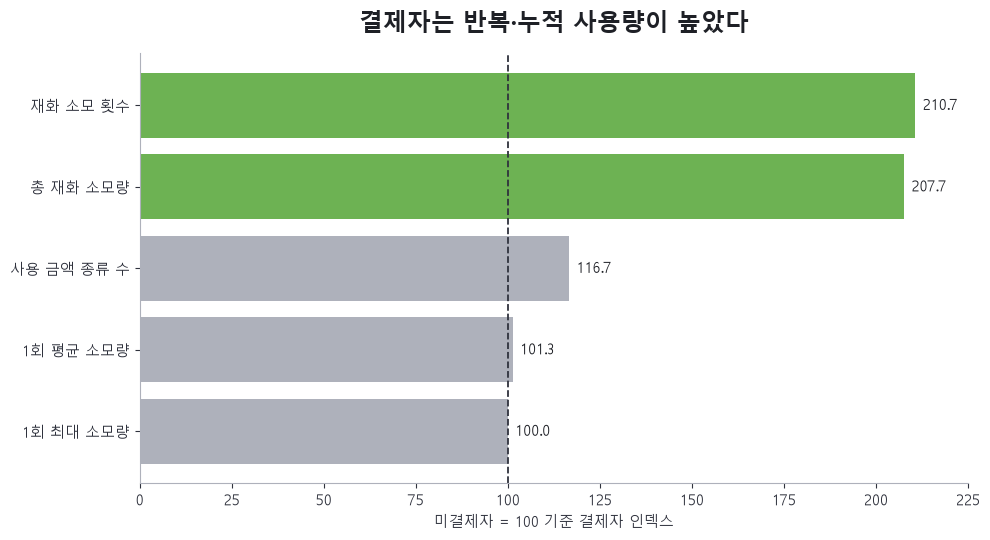

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# -----------------------------
# 한글 폰트
# -----------------------------
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

# -----------------------------
# 컬러 팔레트
# -----------------------------
GREEN_200 = "#99FA75"
GREEN_300 = "#6DB253"

GRAY_300 = "#AEB1BB"
GRAY_800 = "#2F323D"
GRAY_900 = "#1E2026"

# -----------------------------
# 데이터
# -----------------------------
plot_df = pd.DataFrame({
    "feature": [
        "재화 소모 횟수",
        "총 재화 소모량",
        "사용 금액 종류 수",
        "1회 평균 소모량",
        "1회 최대 소모량"
    ],
    "unpaid_median": [14, 3070, 3.0, 248.3, 500],
    "paid_median": [29.5, 6375, 3.5, 251.6, 500]
})

plot_df["paid_index"] = (
    plot_df["paid_median"]
    / plot_df["unpaid_median"]
    * 100
)

plot_df = plot_df.sort_values(
    "paid_index",
    ascending=True
)

# -----------------------------
# 강조 색상
# 반복/누적 사용 관련 변수만 강조
# -----------------------------
colors = [
    GREEN_300 if feature in ["재화 소모 횟수", "총 재화 소모량"]
    else GRAY_300
    for feature in plot_df["feature"]
]

# -----------------------------
# 그래프
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.barh(
    plot_df["feature"],
    plot_df["paid_index"],
    color=colors
)

# 미결제자 기준선
ax.axvline(
    100,
    color=GRAY_800,
    linestyle="--",
    linewidth=1.3
)

# 숫자 표시
for bar, value in zip(bars, plot_df["paid_index"]):
    ax.text(
        value + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        fontsize=11,
        color=GRAY_900
    )

ax.set_title(
    "결제자는 반복·누적 사용량이 높았다",
    fontsize=17,
    fontweight="bold",
    color=GRAY_900,
    pad=16
)

ax.set_xlabel(
    "미결제자 = 100 기준 결제자 인덱스",
    fontsize=11,
    color=GRAY_800
)

ax.tick_params(
    axis="both",
    colors=GRAY_800,
    labelsize=11
)

ax.set_xlim(0, 225)

# 불필요한 테두리 제거
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(GRAY_300)
ax.spines["bottom"].set_color(GRAY_300)

plt.tight_layout()
plt.show()

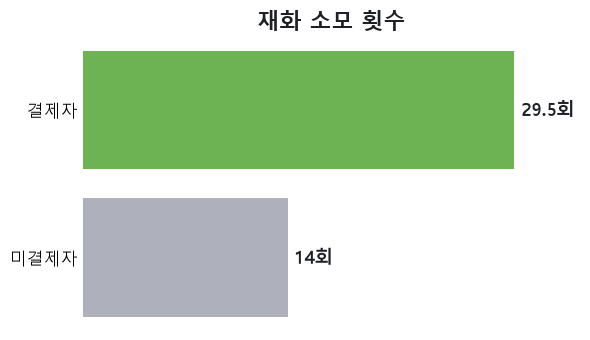

In [65]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# 한글 폰트
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

GREEN_300 = "#6DB253"
GRAY_300 = "#AEB1BB"
GRAY_900 = "#1E2026"

# -------------------------
# 재화 소모 횟수
# -------------------------
labels = ["미결제자", "결제자"]
values = [14, 29.5]
colors = [GRAY_300, GREEN_300]

fig, ax = plt.subplots(figsize=(6, 3.5))

bars = ax.barh(labels, values, color=colors)

for bar, value in zip(bars, values):
    ax.text(
        value + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{value:g}회",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=GRAY_900
    )

ax.set_title(
    "재화 소모 횟수",
    fontsize=16,
    fontweight="bold",
    color=GRAY_900
)

ax.set_xlim(0, 34)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", bottom=False, labelbottom=False)
ax.tick_params(axis="y", labelsize=12, length=0)

plt.tight_layout()
plt.show()

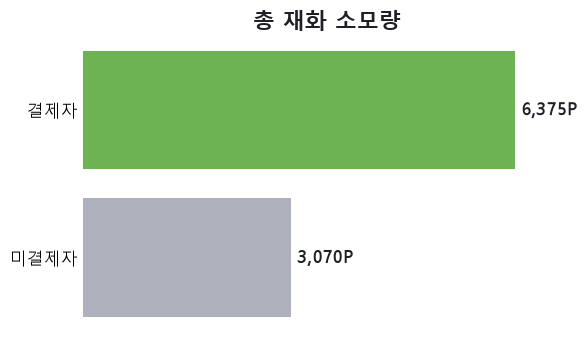

In [66]:
labels = ["미결제자", "결제자"]
values = [3070, 6375]
colors = [GRAY_300, GREEN_300]

fig, ax = plt.subplots(figsize=(6, 3.5))

bars = ax.barh(labels, values, color=colors)

for bar, value in zip(bars, values):
    ax.text(
        value + 100,
        bar.get_y() + bar.get_height()/2,
        f"{value:,.0f}P",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=GRAY_900
    )

ax.set_title(
    "총 재화 소모량",
    fontsize=16,
    fontweight="bold",
    color=GRAY_900
)

ax.set_xlim(0, 7200)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", bottom=False, labelbottom=False)
ax.tick_params(axis="y", labelsize=12, length=0)

plt.tight_layout()
plt.show()

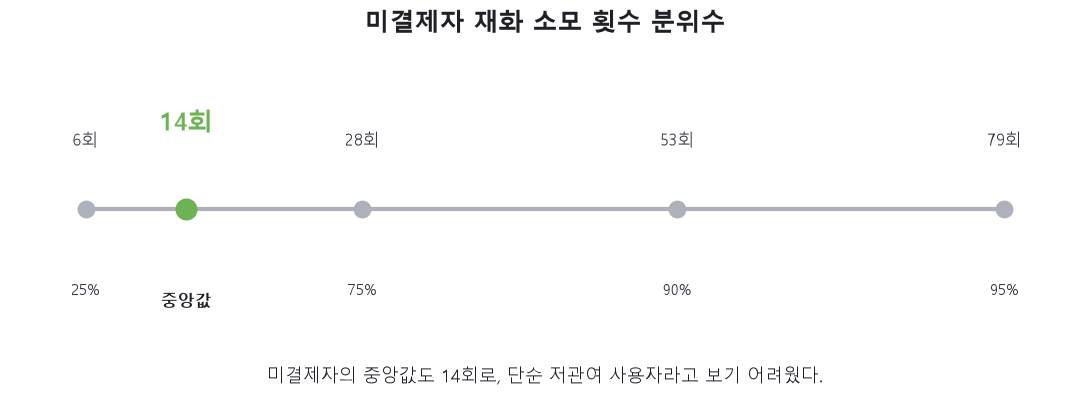

In [67]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# -----------------------------
# 한글 폰트 설정
# -----------------------------
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

# -----------------------------
# 컬러 팔레트
# -----------------------------
GREEN_200 = "#99FA75"
GREEN_300 = "#6DB253"
GRAY_300 = "#AEB1BB"
GRAY_800 = "#2F323D"
GRAY_900 = "#1E2026"

# -----------------------------
# 데이터
# -----------------------------
labels = ["25%", "중앙값", "75%", "90%", "95%"]
values = [6, 14, 28, 53, 79]

# -----------------------------
# 그래프
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 3.8))

# 메인 선
ax.hlines(
    y=0,
    xmin=min(values),
    xmax=max(values),
    color=GRAY_300,
    linewidth=3
)

# 점 표시
for x, label in zip(values, labels):
    if label == "중앙값":
        ax.scatter(x, 0, s=220, color=GREEN_300, zorder=3)
    else:
        ax.scatter(x, 0, s=140, color=GRAY_300, zorder=3)

# 값 표시
for x, label in zip(values, labels):
    if label == "중앙값":
        ax.text(
            x, 0.22, f"{x}회",
            ha="center", va="bottom",
            fontsize=18, fontweight="bold", color=GREEN_300
        )
        ax.text(
            x, -0.25, label,
            ha="center", va="top",
            fontsize=12, fontweight="bold", color=GRAY_900
        )
    else:
        ax.text(
            x, 0.18, f"{x}회",
            ha="center", va="bottom",
            fontsize=12, color=GRAY_800
        )
        ax.text(
            x, -0.22, label,
            ha="center", va="top",
            fontsize=11, color=GRAY_800
        )

# 제목
ax.set_title(
    "미결제자 재화 소모 횟수 분위수",
    fontsize=18,
    fontweight="bold",
    color=GRAY_900,
    pad=20
)

# 축/테두리 제거
ax.set_xlim(0, 85)
ax.set_ylim(-0.45, 0.45)
ax.axis("off")

# 하단 설명 문구
fig.text(
    0.5, -0.02,
    "미결제자의 중앙값도 14회로, 단순 저관여 사용자라고 보기 어려웠다.",
    ha="center",
    fontsize=13,
    color=GRAY_900
)

plt.tight_layout()
plt.show()

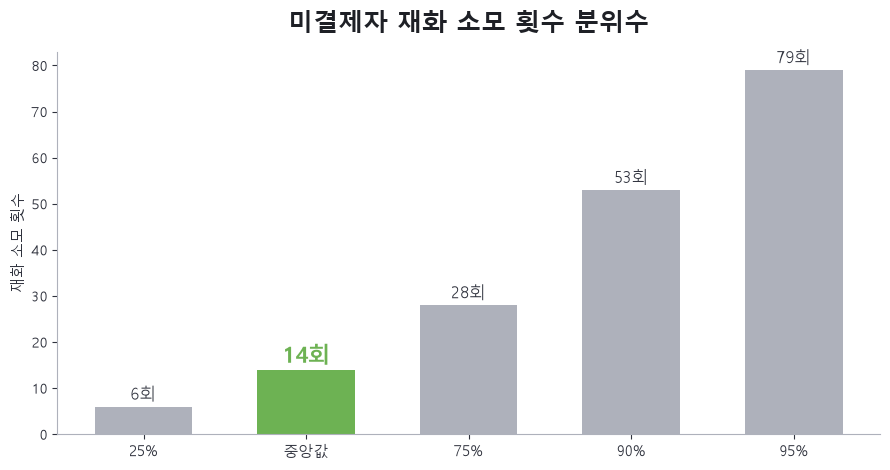

In [68]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# -----------------------------
# 한글 폰트 설정
# -----------------------------
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

# -----------------------------
# 컬러
# -----------------------------
GREEN_300 = "#6DB253"
GRAY_300 = "#AEB1BB"
GRAY_800 = "#2F323D"
GRAY_900 = "#1E2026"

# -----------------------------
# 데이터
# -----------------------------
labels = ["25%", "중앙값", "75%", "90%", "95%"]
values = [6, 14, 28, 53, 79]
colors = [GRAY_300, GREEN_300, GRAY_300, GRAY_300, GRAY_300]

# -----------------------------
# 그래프
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 4.8))

bars = ax.bar(labels, values, color=colors, width=0.6)

for bar, value, label in zip(bars, values, labels):
    if label == "중앙값":
        ax.text(
            bar.get_x() + bar.get_width()/2,
            value + 1.5,
            f"{value}회",
            ha="center",
            fontsize=16,
            fontweight="bold",
            color=GREEN_300
        )
    else:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            value + 1.5,
            f"{value}회",
            ha="center",
            fontsize=12,
            color=GRAY_800
        )

ax.set_title(
    "미결제자 재화 소모 횟수 분위수",
    fontsize=18,
    fontweight="bold",
    color=GRAY_900,
    pad=15
)

ax.set_ylabel("재화 소모 횟수", fontsize=11, color=GRAY_800)
ax.tick_params(axis="x", labelsize=11, colors=GRAY_800)
ax.tick_params(axis="y", labelsize=10, colors=GRAY_800)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRAY_300)
ax.spines["bottom"].set_color(GRAY_300)

plt.tight_layout()
plt.show()

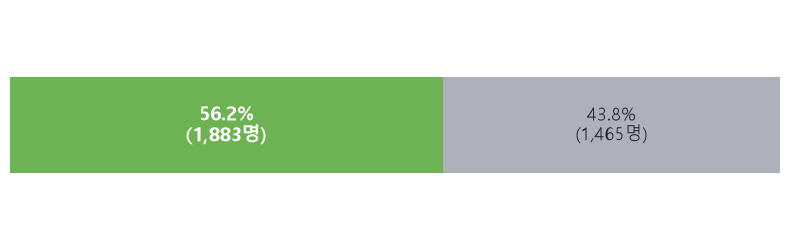

In [69]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# 한글 폰트
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

GREEN_300 = "#6DB253"
GRAY_300 = "#AEB1BB"
GRAY_800 = "#2F323D"
GRAY_900 = "#1E2026"

reward_users = 1883
no_reward_users = 1465
total = 3348

reward_rate = reward_users / total * 100
no_reward_rate = no_reward_users / total * 100

fig, ax = plt.subplots(figsize=(8, 2.6))

ax.barh(
    [0],
    [reward_rate],
    color=GREEN_300,
    height=0.42,
    label="보상 획득"
)

ax.barh(
    [0],
    [no_reward_rate],
    left=[reward_rate],
    color=GRAY_300,
    height=0.42,
    label="보상 미획득"
)

# 비율 라벨
ax.text(
    reward_rate / 2,
    0,
    f"{reward_rate:.1f}%\n({reward_users:,}명)",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color="white"
)

ax.text(
    reward_rate + no_reward_rate / 2,
    0,
    f"{no_reward_rate:.1f}%\n({no_reward_users:,}명)",
    ha="center",
    va="center",
    fontsize=13,
    color=GRAY_900
)

ax.set_xlim(0, 100)
ax.set_ylim(-0.5, 0.5)

ax.axis("off")

plt.tight_layout()
plt.show()

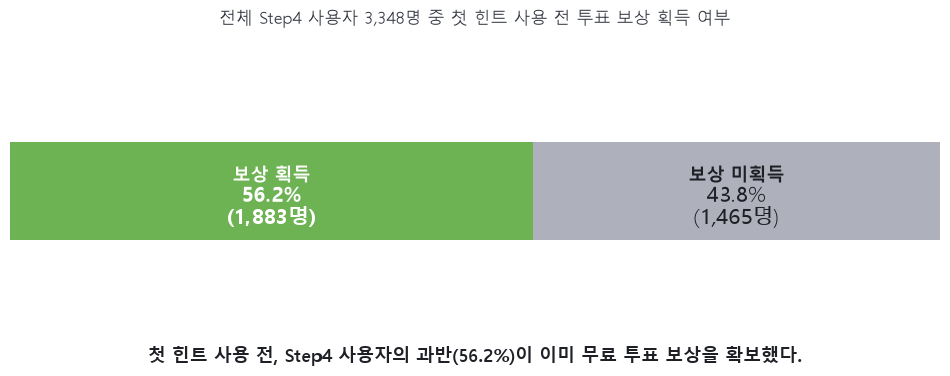

In [70]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# 한글 폰트
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

# 컬러
GREEN_300 = "#6DB253"
GRAY_300 = "#AEB1BB"
GRAY_800 = "#2F323D"
GRAY_900 = "#1E2026"

# 데이터
reward_users = 1883
no_reward_users = 1465
total = 3348

reward_rate = reward_users / total * 100
no_reward_rate = no_reward_users / total * 100

fig, ax = plt.subplots(figsize=(10, 3.8))

# 막대
ax.barh(
    [0],
    [reward_rate],
    color=GREEN_300,
    height=0.5
)

ax.barh(
    [0],
    [no_reward_rate],
    left=[reward_rate],
    color=GRAY_300,
    height=0.5
)

# 왼쪽 라벨
ax.text(
    reward_rate / 2,
    0.08,
    "보상 획득",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color="white"
)
ax.text(
    reward_rate / 2,
    -0.08,
    f"{reward_rate:.1f}%\n({reward_users:,}명)",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold",
    color="white"
)

# 오른쪽 라벨
ax.text(
    reward_rate + no_reward_rate / 2,
    0.08,
    "보상 미획득",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color=GRAY_900
)
ax.text(
    reward_rate + no_reward_rate / 2,
    -0.08,
    f"{no_reward_rate:.1f}%\n({no_reward_users:,}명)",
    ha="center",
    va="center",
    fontsize=15,
    color=GRAY_900
)

# 설명 문구
fig.text(
    0.5, 0.92,
    "전체 Step4 사용자 3,348명 중 첫 힌트 사용 전 투표 보상 획득 여부",
    ha="center",
    fontsize=12,
    color=GRAY_800
)

fig.text(
    0.5, 0.03,
    "첫 힌트 사용 전, Step4 사용자의 과반(56.2%)이 이미 무료 투표 보상을 확보했다.",
    ha="center",
    fontsize=13,
    fontweight="bold",
    color=GRAY_900
)

ax.set_xlim(0, 100)
ax.set_ylim(-0.7, 0.7)
ax.axis("off")

plt.tight_layout(rect=[0.02, 0.08, 0.98, 0.88])
plt.show()

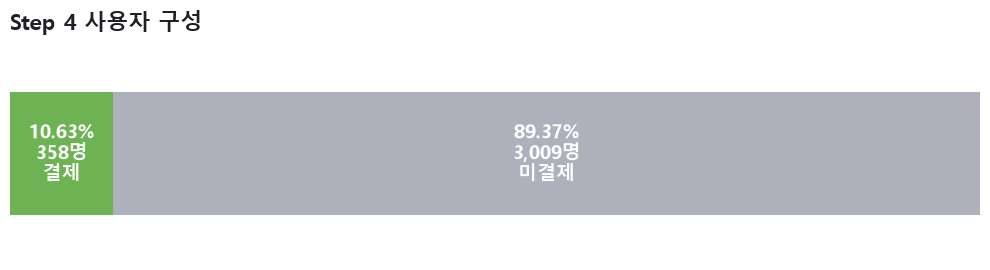

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# -----------------------------
# 한글 폰트
# -----------------------------
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

# -----------------------------
# 색상
# -----------------------------
GREEN_300 = "#6DB253"
GRAY_300 = "#AEB1BB"
GRAY_800 = "#2F323D"
GRAY_900 = "#1E2026"

# -----------------------------
# 데이터
# -----------------------------
paid = 358
unpaid = 3009
total = paid + unpaid

paid_rate = paid / total * 100       # 10.63
unpaid_rate = unpaid / total * 100   # 89.37

# -----------------------------
# 그래프
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 2.8))

# 결제
ax.barh(
    y=[0],
    width=[paid_rate],
    color=GREEN_300,
    height=0.52
)

# 미결제
ax.barh(
    y=[0],
    width=[unpaid_rate],
    left=[paid_rate],
    color=GRAY_300,
    height=0.52
)

# -----------------------------
# 막대 내부 텍스트
# -----------------------------
ax.text(
    paid_rate / 2,
    0,
    f"{paid_rate:.2f}%\n{paid:,}명\n결제",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color="white"
)

ax.text(
    paid_rate + unpaid_rate / 2,
    0,
    f"{unpaid_rate:.2f}%\n{unpaid:,}명\n미결제",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color="white"
)

# -----------------------------
# 제목
# -----------------------------
ax.set_title(
    "Step 4 사용자 구성",
    loc="left",
    fontsize=16,
    fontweight="bold",
    color=GRAY_900,
    pad=12
)

# -----------------------------
# 축 설정
# -----------------------------
ax.set_xlim(0, 100)
ax.set_ylim(-0.45, 0.45)

# x축 표시
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_yticks([])

# 불필요한 테두리 제거
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    axis="x",
    length=0,
    pad=8
)

# 아래쪽 여백
plt.tight_layout()

plt.show()

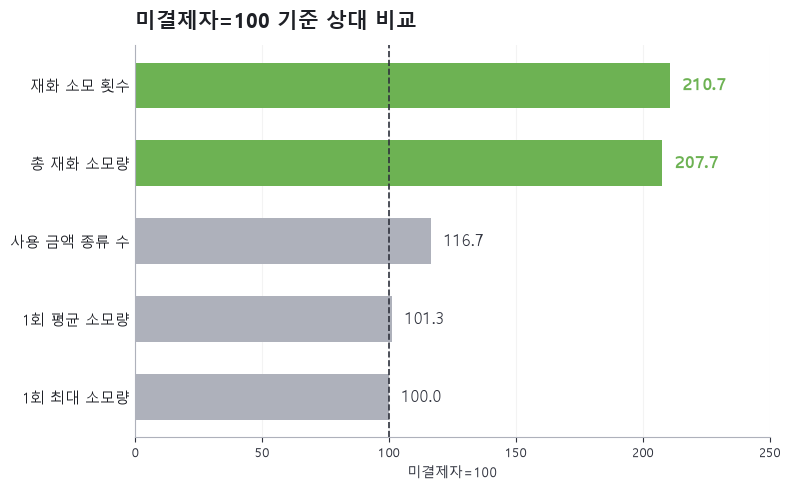

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# -----------------------------
# 한글 폰트
# -----------------------------
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

# -----------------------------
# 색상
# -----------------------------
GREEN_300 = "#6DB253"
GRAY_300 = "#AEB1BB"
GRAY_800 = "#2F323D"
GRAY_900 = "#1E2026"

# -----------------------------
# 데이터
# -----------------------------
plot_df = pd.DataFrame({
    "feature": [
        "재화 소모 횟수",
        "총 재화 소모량",
        "사용 금액 종류 수",
        "1회 평균 소모량",
        "1회 최대 소모량"
    ],
    "index": [
        210.7,
        207.7,
        116.7,
        101.3,
        100.0
    ]
})

# 위에 큰 값이 오도록 역순 정렬
plot_df = plot_df.iloc[::-1]

# -----------------------------
# 색상 지정
# -----------------------------
colors = [
    GREEN_300 if feature in ["재화 소모 횟수", "총 재화 소모량"]
    else GRAY_300
    for feature in plot_df["feature"]
]

# -----------------------------
# 그래프
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    plot_df["feature"],
    plot_df["index"],
    color=colors,
    height=0.58
)

# 미결제자 = 100 기준선
ax.axvline(
    100,
    color=GRAY_800,
    linestyle="--",
    linewidth=1.2
)

# 값 라벨
for bar, value, feature in zip(
    bars,
    plot_df["index"],
    plot_df["feature"]
):
    color = GREEN_300 if feature in ["재화 소모 횟수", "총 재화 소모량"] else GRAY_800

    ax.text(
        value + 5,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}",
        va="center",
        fontsize=12,
        fontweight="bold" if feature in ["재화 소모 횟수", "총 재화 소모량"] else "normal",
        color=color
    )

# -----------------------------
# 제목 / 축
# -----------------------------
ax.set_title(
    "미결제자=100 기준 상대 비교",
    loc="left",
    fontsize=15,
    fontweight="bold",
    color=GRAY_900,
    pad=12
)

ax.set_xlabel(
    "미결제자=100",
    fontsize=10,
    color=GRAY_800
)

ax.set_xlim(0, 250)
ax.set_xticks([0, 50, 100, 150, 200, 250])

ax.tick_params(
    axis="x",
    colors=GRAY_800,
    labelsize=9
)

ax.tick_params(
    axis="y",
    colors=GRAY_900,
    labelsize=11,
    length=0
)

# -----------------------------
# 테두리 / 그리드
# -----------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(GRAY_300)
ax.spines["bottom"].set_color(GRAY_300)

ax.grid(
    axis="x",
    linestyle="-",
    alpha=0.15
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

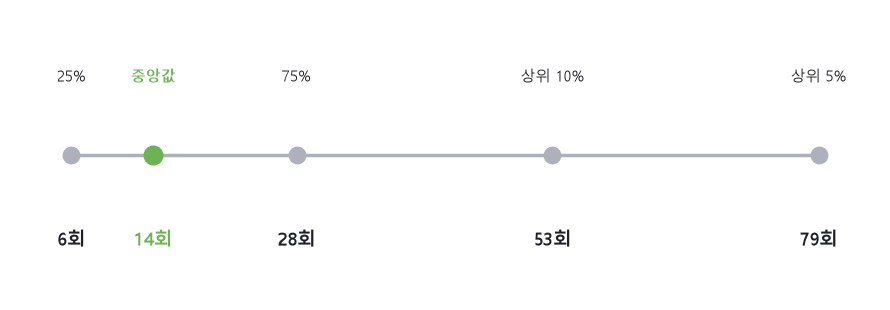

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# -----------------------------
# 한글 폰트
# -----------------------------
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

# -----------------------------
# 색상
# -----------------------------
GREEN_300 = "#6DB253"
GRAY_300 = "#AEB1BB"
GRAY_800 = "#2F323D"
GRAY_900 = "#1E2026"

# -----------------------------
# 데이터
# -----------------------------
labels = ["25%", "중앙값", "75%", "상위 10%", "상위 5%"]
values = [6, 14, 28, 53, 79]

# -----------------------------
# 그래프
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 3.2))

# 연결선
ax.hlines(
    y=0,
    xmin=values[0],
    xmax=values[-1],
    color=GRAY_300,
    linewidth=2.5
)

# 점
for x, label in zip(values, labels):
    if label == "중앙값":
        ax.scatter(
            x, 0,
            s=180,
            color=GREEN_300,
            zorder=3
        )
    else:
        ax.scatter(
            x, 0,
            s=140,
            color=GRAY_300,
            zorder=3
        )

# 위쪽 라벨 + 아래쪽 값
for x, label in zip(values, labels):

    # 위쪽 분위수 라벨
    ax.text(
        x, 0.17,
        label,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold" if label == "중앙값" else "normal",
        color=GREEN_300 if label == "중앙값" else GRAY_900
    )

    # 아래쪽 실제 값
    ax.text(
        x, -0.18,
        f"{x}회",
        ha="center",
        va="top",
        fontsize=13,
        fontweight="bold",
        color=GREEN_300 if label == "중앙값" else GRAY_900
    )

# -----------------------------
# 축 제거
# -----------------------------
ax.set_xlim(0, 85)
ax.set_ylim(-0.35, 0.35)
ax.axis("off")

plt.tight_layout()
plt.show()

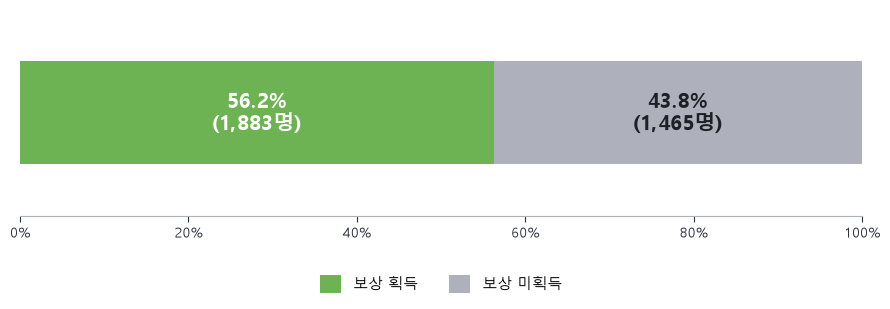

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
from matplotlib.patches import Patch

# -----------------------------
# 한글 폰트
# -----------------------------
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

# -----------------------------
# 색상
# -----------------------------
GREEN_300 = "#6DB253"
GRAY_300 = "#AEB1BB"
GRAY_800 = "#2F323D"
GRAY_900 = "#1E2026"

# -----------------------------
# 데이터
# -----------------------------
reward_users = 1883
no_reward_users = 1465
total = reward_users + no_reward_users

reward_rate = reward_users / total * 100
no_reward_rate = no_reward_users / total * 100

# -----------------------------
# 그래프
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 3.3))

# 보상 획득
ax.barh(
    y=[0],
    width=[reward_rate],
    color=GREEN_300,
    height=0.55
)

# 보상 미획득
ax.barh(
    y=[0],
    width=[no_reward_rate],
    left=[reward_rate],
    color=GRAY_300,
    height=0.55
)

# -----------------------------
# 막대 내부 텍스트
# -----------------------------
ax.text(
    reward_rate / 2,
    0,
    f"{reward_rate:.1f}%\n({reward_users:,}명)",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold",
    color="white"
)

ax.text(
    reward_rate + no_reward_rate / 2,
    0,
    f"{no_reward_rate:.1f}%\n({no_reward_users:,}명)",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold",
    color=GRAY_900
)

# -----------------------------
# 축 설정
# -----------------------------
ax.set_xlim(0, 100)
ax.set_ylim(-0.55, 0.55)

ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_xticklabels(
    ["0%", "20%", "40%", "60%", "80%", "100%"],
    fontsize=10,
    color=GRAY_800
)

ax.set_yticks([])

# 아래쪽 축만 남김
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(GRAY_300)

ax.tick_params(
    axis="x",
    colors=GRAY_800,
    length=4
)

# -----------------------------
# 범례
# -----------------------------
legend_elements = [
    Patch(
        facecolor=GREEN_300,
        edgecolor="none",
        label="보상 획득"
    ),
    Patch(
        facecolor=GRAY_300,
        edgecolor="none",
        label="보상 미획득"
    )
]

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=2,
    frameon=False,
    fontsize=11,
    handlelength=1.4,
    handleheight=1.4
)

plt.tight_layout()
plt.show()

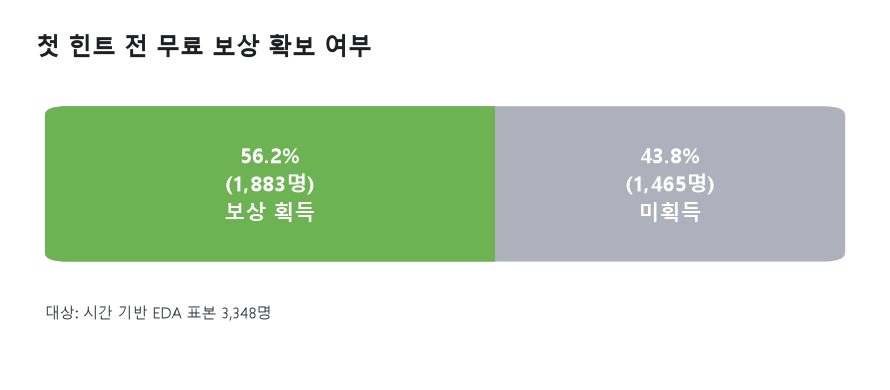

In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
from matplotlib.patches import FancyBboxPatch, Rectangle

# -----------------------------
# 한글 폰트
# -----------------------------
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

# -----------------------------
# 색상
# -----------------------------
GREEN_300 = "#6DB253"
GRAY_300 = "#AEB1BB"
GRAY_800 = "#2F323D"
GRAY_900 = "#1E2026"

# -----------------------------
# 데이터
# -----------------------------
reward_users = 1883
no_reward_users = 1465
total = 3348

reward_rate = reward_users / total       # 0.5624
no_reward_rate = no_reward_users / total # 0.4376

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 4))
ax.axis("off")

# -----------------------------
# 제목
# -----------------------------
ax.text(
    0.03, 0.90,
    "첫 힌트 전 무료 보상 확보 여부",
    transform=ax.transAxes,
    fontsize=17,
    fontweight="bold",
    color=GRAY_900,
    ha="left",
    va="center"
)

# -----------------------------
# 막대 위치
# -----------------------------
x0 = 0.04
y0 = 0.32
bar_width = 0.92
bar_height = 0.42

# 바깥 둥근 형태
outer_bar = FancyBboxPatch(
    (x0, y0),
    bar_width,
    bar_height,
    boxstyle="round,pad=0,rounding_size=0.025",
    transform=ax.transAxes,
    facecolor=GRAY_300,
    linewidth=0
)

ax.add_patch(outer_bar)

# 초록 영역
green_width = bar_width * reward_rate

green_rect = Rectangle(
    (x0, y0),
    green_width,
    bar_height,
    transform=ax.transAxes,
    facecolor=GREEN_300,
    linewidth=0
)

# 바깥 둥근 모양 안에서만 보이도록 자르기
green_rect.set_clip_path(outer_bar)
ax.add_patch(green_rect)

# -----------------------------
# 막대 내부 텍스트
# -----------------------------

# 보상 획득
ax.text(
    x0 + green_width / 2,
    y0 + bar_height / 2,
    f"{reward_rate*100:.1f}%\n({reward_users:,}명)\n보상 획득",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold",
    color="white",
    linespacing=1.35
)

# 보상 미획득
gray_width = bar_width * no_reward_rate

ax.text(
    x0 + green_width + gray_width / 2,
    y0 + bar_height / 2,
    f"{no_reward_rate*100:.1f}%\n({no_reward_users:,}명)\n미획득",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold",
    color="white",
    linespacing=1.35
)

# -----------------------------
# 하단 설명
# -----------------------------
ax.text(
    0.04, 0.18,
    "대상: 시간 기반 EDA 표본 3,348명",
    transform=ax.transAxes,
    fontsize=10.5,
    color=GRAY_800,
    ha="left",
    va="center"
)

plt.tight_layout()
plt.show()

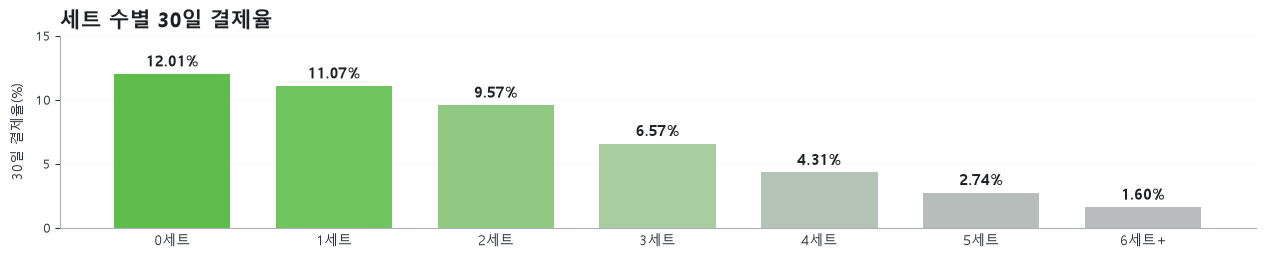

In [11]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# 한글 폰트
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

# 컬러
GREEN_300 = "#6DB253"
GRAY_300 = "#AEB1BB"
GRAY_800 = "#2F323D"
GRAY_900 = "#1E2026"

# 데이터
labels = ["0세트", "1세트", "2세트", "3세트", "4세트", "5세트", "6세트+"]
rates = [12.01, 11.07, 9.57, 6.57, 4.31, 2.74, 1.60]

# 사진처럼 점점 연해지는 느낌
colors = [
    "#5FBE4B",
    "#70C45E",
    "#90C982",
    "#A8CEA0",
    "#B4C3B5",
    "#B7BDBB",
    "#B9BCBD"
]

# 가로 길고 세로 짧게
fig, ax = plt.subplots(figsize=(13, 3.2))

bars = ax.bar(
    labels,
    rates,
    color=colors,
    width=0.72
)

# 막대 위 값
for bar, value in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.35,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=GRAY_900
    )

# 제목
ax.set_title(
    "세트 수별 30일 결제율",
    loc="left",
    fontsize=15,
    fontweight="bold",
    color=GRAY_900,
    pad=6
)

# y축
ax.set_ylabel(
    "30일 결제율(%)",
    fontsize=10,
    color=GRAY_800,
    labelpad=8
)

ax.set_ylim(0, 15)
ax.set_yticks([0, 5, 10, 15])

# x/y 글자
ax.tick_params(
    axis="x",
    labelsize=10,
    colors=GRAY_800,
    length=0,
    pad=4
)

ax.tick_params(
    axis="y",
    labelsize=9,
    colors=GRAY_800
)

# 테두리
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRAY_300)
ax.spines["bottom"].set_color(GRAY_300)

# 그리드 아주 약하게
ax.grid(
    axis="y",
    alpha=0.08
)

ax.set_axisbelow(True)

# 위아래 압축
plt.subplots_adjust(
    left=0.07,
    right=0.99,
    top=0.82,
    bottom=0.22
)

plt.show()